In [1]:
using LinearAlgebra
using SparseArrays
using Statistics
using Plots
using OrdinaryDiffEq
using OrdinaryDiffEqSDIRK
using Random
using BenchmarkTools
using Printf



# Misc Code
- define the random functions


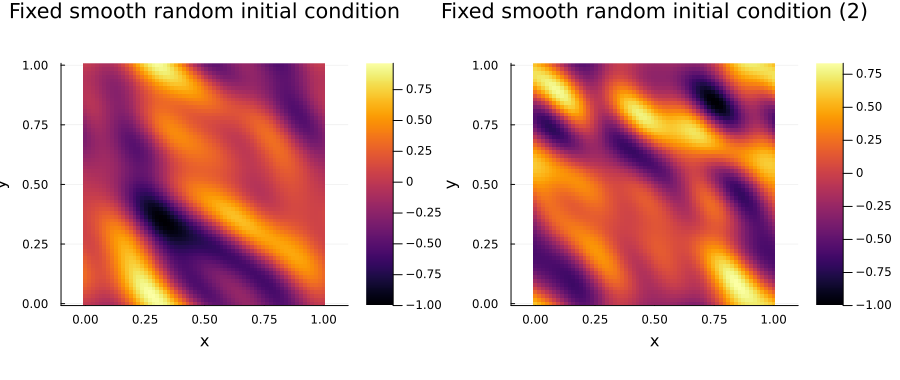

In [2]:
# smooth random functions on [0, 1]^2

rng_smooth = MersenneTwister(2027)
rng_smooth_2 = MersenneTwister(2028)
Nx_smooth_random_init = 64
Ny_smooth_random_init = 64
x_smooth_random_init = LinRange(0, 1, Nx_smooth_random_init)
y_smooth_random_init = LinRange(0, 1, Ny_smooth_random_init)

# Fixed low-frequency random Fourier coefficients.
num_smooth_modes = 4
smooth_scale(kx, ky) = 1 / (kx^2 + ky^2)

smooth_cos_coeffs = [randn(rng_smooth) * smooth_scale(kx, ky) for kx in 1:num_smooth_modes, ky in 1:num_smooth_modes]
smooth_sin_coeffs = [randn(rng_smooth) * smooth_scale(kx, ky) for kx in 1:num_smooth_modes, ky in 1:num_smooth_modes]

smooth_cos_coeffs_2 = [randn(rng_smooth_2) * smooth_scale(kx, ky) for kx in 1:num_smooth_modes, ky in 1:num_smooth_modes]
smooth_sin_coeffs_2 = [randn(rng_smooth_2) * smooth_scale(kx, ky) for kx in 1:num_smooth_modes, ky in 1:num_smooth_modes]

function smooth_random_init_raw(x, y)
    return sum(
        smooth_cos_coeffs[kx, ky] * cos(2π * (kx*x + ky*y)) +
        smooth_sin_coeffs[kx, ky] * sin(2π * (kx*x + ky*y))
        for kx in 1:num_smooth_modes, ky in 1:num_smooth_modes
    )
end

function smooth_random_init_raw_2(x, y)
    return sum(
        smooth_cos_coeffs_2[kx, ky] * cos(2π * (kx*x + ky*y)) +
        smooth_sin_coeffs_2[kx, ky] * sin(2π * (kx*x + ky*y))
        for kx in 1:num_smooth_modes, ky in 1:num_smooth_modes
    )
end

smooth_random_values = [smooth_random_init_raw(x, y) for x in x_smooth_random_init, y in y_smooth_random_init]
smooth_random_values_2 = [smooth_random_init_raw_2(x, y) for x in x_smooth_random_init, y in y_smooth_random_init]

smooth_random_scale = maximum(abs.(smooth_random_values))
smooth_random_scale_2 = maximum(abs.(smooth_random_values_2))

smooth_random_init(x, y) = smooth_random_init_raw(x, y) / smooth_random_scale
smooth_random_init_2(x, y) = smooth_random_init_raw_2(x, y) / smooth_random_scale_2

p1 = heatmap(
    x_smooth_random_init,
    y_smooth_random_init,
    smooth_random_values' ./ smooth_random_scale,
    title="Fixed smooth random initial condition",
    xlabel="x",
    ylabel="y",
    aspect_ratio=:equal,
    colorbar=true,
)

p2 = heatmap(
    x_smooth_random_init,
    y_smooth_random_init,
    smooth_random_values_2' ./ smooth_random_scale_2,
    title="Fixed smooth random initial condition (2)",
    xlabel="x",
    ylabel="y",
    aspect_ratio=:equal,
    colorbar=true,
)

plot(p1, p2; layout=(1, 2), size=(900, 380))


# FOM / ROM Code


In [3]:
# just a FOM rhs
fom_rhs!(du, u, (;A, f), t) = du .= A*u .+ f.(u)

# FOM rhs that logs f values into f_trajectory
function fom_rhs_saving!(du, u, (;A, f), t, f_trajectory)
    fu = f.(u)
    du .= A*u .+ fu
    f_trajectory[t] = fu
end

# Dr. Urban's ROM (hyperreduction included) code
function build_rom(A, f, u, fu, r, m)
    # POD modes from trajectory data (build trial subspace) and nonlinearity evaluations (DEIM) resp.
    U, V = svd(u).U[:, 1:r], svd(fu).U[:, 1:m]

    # build an empty vector of DEIM points; the first one is the max norm point
    # on the first hyperreduction POD mode
    p = vcat(argmax(abs.(V[:, 1])), zeros(Int, m-1))

    # greedy alg for selecting next DEIM point; you're going mode by mode and finding where the approximation
    # over the first k modes of the k+1st mode is worst
    for k = 1:m-1
        p[k+1] = argmax(abs.(V[:, 1:k]*(V[p[1:k], 1:k]\V[p[1:k], k+1]) - V[:, k+1]))
    end

    # a NamedTuple that builds the ingredients for running the ROM
    # note that we're pre-preparing B with Julia's solver, which will be stable
    (U=U, V=V, Ã=U'*(A*U), f=f, p=p, Up=U[p, :], Vp=V[p, :], B = (V[p, :]' \ (V' * U))')
end

function build_linear_rom(A, u, r)
    U = svd(u).U[:, 1:r]
    (Ã=U'*(A*U), U=U)
end

# compact 1-line function definition
# update derivative vector
rom_rhs!(dũ, ũ, (;U, V, Ã, f, p, Up, Vp, B), t) = dũ .= Ã*ũ .+ B*f.(Up*ũ)

# if your RHS is linear you don't need hyperreduction
linear_rom_rhs!(dũ, ũ, (;Ã, U), t) = dũ .= Ã * ũ


linear_rom_rhs! (generic function with 1 method)

# 2D Allen-Cahn Equation with Initial Conditions
$$u_t = \kappa (u_{xx} + u_{yy}) + f(u) = \kappa \Delta u - f(u) = \kappa \Delta u - F'(u)$$
Note that often $$F(u)= \frac{(u^2-1)^2}{4}$$or something of the sort. 


In [4]:
# AC_2D_trajectory
"""
    AC_2D_trajectory(u₀_function, T, κ, Nx, Ny=Nx, use_ROM=false, r=nothing;
                            f=zero_reaction, num_steps=Nsteps,
                            pod_trajectory=nothing, nonlinear_snapshots=nothing,
                            f_snapshots=nothing, m=nothing,
                            pod_modes=nothing, reduced_operator=nothing,
                            rom=nothing, boundary_condition=:dirichlet,
                            return_f_snapshots=false)

Solve the 2D equation

    u_t = κ Δu - f(u)

on an `Nx`-by-`Ny` grid over the fixed domain [0, 1] × [0, 1].
With the default `f=zero_reaction`, this is the diffusion equation. Passing an
Allen-Cahn derivative such as `f = u -> u^3 - u` gives the standard
energy-decreasing Allen-Cahn form when `F(u) = (u^2 - 1)^2 / 4`.

`u₀_function` is called as `u₀_function(x, y)` to construct the initial state.
The returned trajectory is flattened: each column is `vec(u_grid)` using Julia column-major order.
Use `trajectory_frame(traj, t)` to reshape a saved state back to an `Nx`-by-`Ny` grid.

`boundary_condition` can be `:dirichlet` for zero Dirichlet ghost values or
`:periodic` for wraparound periodic boundaries.

If `use_ROM=false`, this solves the full-order model and returns the FOM trajectory.
Set `return_f_snapshots=true` to return `(u=trajectory, f=f_trajectory)`, where
`f_trajectory[:, j] = f.(trajectory[:, j])`. These snapshots store `F′(u)`;
the solver subtracts them in the Allen-Cahn RHS. This is the nonlinear snapshot
matrix you can use for DEIM/hyperreduction training.

If `use_ROM=true`, this solves a ROM. You can provide precomputed ROM data with
`rom=(U=..., Ã=...)` for linear diffusion, `rom=(U=..., Ã=..., f=...)` for a
full projected nonlinear ROM, or a DEIM ROM from `build_deim_rom_from_modes`.
If no `rom` is provided, this function builds one from `pod_modes` or from
`pod_trajectory`. Passing `nonlinear_snapshots` or `f_snapshots` together with
`m` builds a DEIM/hyperreduced ROM; otherwise a full projected nonlinear ROM is
used when `f` is nonzero.
"""

zero_reaction(u) = zero(u)

function second_derivative_matrix_1D(N, Δ; boundary_condition=:dirichlet)
    N >= 2 || error("N must be at least 2")
    bc = Symbol(lowercase(String(boundary_condition)))

    main_diag = fill(-2.0, N)
    lower_diag = fill(1.0, N-1)
    upper_diag = fill(1.0, N-1)

    D = spdiagm(-1 => lower_diag, 0 => main_diag, 1 => upper_diag)

    if bc == :dirichlet
        # Zero Dirichlet: missing boundary neighbors are fixed at zero.
    elseif bc == :periodic
        # Periodic: endpoints wrap around to each other.
        D[1, N] = 1.0
        D[N, 1] = 1.0
    else
        error("boundary_condition must be :dirichlet or :periodic")
    end

    return D / Δ^2
end

function diffusion_2D_operator(κ, Nx, Ny=Nx; boundary_condition=:dirichlet, Lx=1.0, Ly=1.0)
    bc = Symbol(lowercase(String(boundary_condition)))
    Δx = bc == :periodic ? Lx / Nx : Lx / (Nx - 1)
    Δy = bc == :periodic ? Ly / Ny : Ly / (Ny - 1)
    Dxx = second_derivative_matrix_1D(Nx, Δx; boundary_condition=boundary_condition)
    Dyy = second_derivative_matrix_1D(Ny, Δy; boundary_condition=boundary_condition)
    Ix = sparse(I, Nx, Nx)
    Iy = sparse(I, Ny, Ny)
    return κ * (kron(Iy, Dxx) + kron(Dyy, Ix))
end

function trajectory_frame(traj, t; Nx=Nx, Ny=Ny)
    @assert size(traj, 1) == Nx * Ny "trajectory row count must match Nx*Ny"
    return reshape(traj[:, t], Nx, Ny)
end

function nonlinear_snapshot_matrix(traj, f)
    f_traj = similar(traj)
    for j in axes(traj, 2)
        f_traj[:, j] .= f.(view(traj, :, j))
    end
    return f_traj
end

function build_deim_rom_from_modes(A, f, U, nonlinear_snapshots, m; reduced_operator=nothing)
    m >= 1 || error("m must be at least 1")
    size(nonlinear_snapshots, 1) == size(U, 1) || error("nonlinear_snapshots must have one row per spatial grid point")

    nonlinear_svd = svd(nonlinear_snapshots)
    m <= size(nonlinear_svd.U, 2) || error("Requested m=$m DEIM modes, but only $(size(nonlinear_svd.U, 2)) nonlinear modes are available")
    V = nonlinear_svd.U[:, 1:m]

    p = vcat(argmax(abs.(V[:, 1])), zeros(Int, m-1))
    for k in 1:m-1
        p[k+1] = argmax(abs.(V[:, 1:k] * (V[p[1:k], 1:k] \ V[p[1:k], k+1]) - V[:, k+1]))
    end

    Ã = isnothing(reduced_operator) ? U' * (A * U) : reduced_operator
    return (U=U, V=V, Ã=Ã, f=f, p=p, Up=U[p, :], Vp=V[p, :], B=(U' * V) / V[p, :])
end

function build_projected_nonlinear_rom(A, f, U; reduced_operator=nothing)
    Ã = isnothing(reduced_operator) ? U' * (A * U) : reduced_operator
    return (U=U, Ã=Ã, f=f)
end

ac_fom_rhs!(du, u, (;A, f), t) = du .= A * u .- f.(u)

function ac_deim_rom_rhs!(dũ, ũ, (;U, V, Ã, f, p, Up, Vp, B), t)
    dũ .= Ã * ũ .- B * f.(Up * ũ)
    return nothing
end

function projected_nonlinear_rom_rhs!(dũ, ũ, (;U, Ã, f), t)
    u = U * ũ
    dũ .= Ã * ũ .- U' * f.(u)
    return nothing
end

function rom_has_field(rom, field)
    return rom isa NamedTuple && field in keys(rom)
end

function rom_rhs_for(rom)
    if rom_has_field(rom, :V) && rom_has_field(rom, :B) && rom_has_field(rom, :Up)
        return ac_deim_rom_rhs!
    elseif rom_has_field(rom, :f)
        return projected_nonlinear_rom_rhs!
    else
        return linear_rom_rhs!
    end
end

function maybe_return_f_snapshots(traj, f; return_f_snapshots=false)
    return_f_snapshots || return traj
    return (u=traj, f=nonlinear_snapshot_matrix(traj, f))
end

function AC_2D_trajectory(u₀_function,
    T,
    κ,
    Nx,
    Ny=Nx,
    use_ROM=false,
    r=nothing;
    f=zero_reaction,
    num_steps=Nsteps,
    pod_trajectory=nothing,
    nonlinear_snapshots=nothing,
    f_snapshots=nothing,
    m=nothing,
    pod_modes=nothing,
    reduced_operator=nothing,
    rom=nothing,
    boundary_condition=:dirichlet,
    return_f_snapshots=false,
    )

    Lx = 1.0
    Ly = 1.0
    Nx >= 2 || error("Nx must be at least 2")
    Ny >= 2 || error("Ny must be at least 2")

    bc = Symbol(lowercase(String(boundary_condition)))
    bc in (:dirichlet, :periodic) || error("boundary_condition must be :dirichlet or :periodic")
    x_local = bc == :periodic ? range(0, step=Lx/Nx, length=Nx) : LinRange(0, Lx, Nx)
    y_local = bc == :periodic ? range(0, step=Ly/Ny, length=Ny) : LinRange(0, Ly, Ny)
    u₀_grid = [u₀_function(xi, yj) for xi in x_local, yj in y_local]
    u₀ = vec(u₀_grid)
    ts = LinRange(0, T, num_steps)

    A_diffusion = diffusion_2D_operator(κ, Nx, Ny; boundary_condition=boundary_condition, Lx=Lx, Ly=Ly)
    use_reaction = f !== zero_reaction
    nonlinear_snapshots = isnothing(nonlinear_snapshots) ? f_snapshots : nonlinear_snapshots

    if !use_ROM
        fom_inputs = (A=A_diffusion, f=f)
        fom_prob = ODEProblem(ac_fom_rhs!, u₀, (0.0, T), fom_inputs)
        traj = Array(solve(fom_prob, TRBDF2(), saveat=ts))
        return maybe_return_f_snapshots(traj, f; return_f_snapshots=return_f_snapshots)
    end

    nstate = Nx * Ny
    if !isnothing(nonlinear_snapshots)
        size(nonlinear_snapshots, 1) == nstate || error("nonlinear_snapshots/f_snapshots must have one row per spatial grid point, matching Nx*Ny")
        isnothing(m) && error("Please provide m when using nonlinear_snapshots/f_snapshots to build a DEIM ROM")
    end

    if isnothing(rom)
        if !isnothing(pod_modes)
            U = isnothing(r) ? pod_modes : pod_modes[:, 1:r]
            if size(U, 1) != nstate
                error("pod_modes must have one row per spatial grid point, matching Nx*Ny")
            end

            if !isnothing(nonlinear_snapshots)
                rom = build_deim_rom_from_modes(A_diffusion, f, U, nonlinear_snapshots, m; reduced_operator=reduced_operator)
            elseif use_reaction
                rom = build_projected_nonlinear_rom(A_diffusion, f, U; reduced_operator=reduced_operator)
            else
                Ã = isnothing(reduced_operator) ? U' * (A_diffusion * U) : reduced_operator
                rom = (U=U, Ã=Ã)
            end
        else
            if isnothing(r)
                error("Please provide r, pod_modes, or rom when use_ROM=true")
            end
            if isnothing(pod_trajectory)
                error("Please provide pod_trajectory, pod_modes, or rom when use_ROM=true")
            end
            if size(pod_trajectory, 1) != nstate
                error("pod_trajectory must have one row per spatial grid point, matching Nx*Ny")
            end

            if !isnothing(nonlinear_snapshots)
                U = svd(pod_trajectory).U[:, 1:r]
                rom = build_deim_rom_from_modes(A_diffusion, f, U, nonlinear_snapshots, m)
            elseif use_reaction
                U = svd(pod_trajectory).U[:, 1:r]
                rom = build_projected_nonlinear_rom(A_diffusion, f, U)
            else
                rom = build_linear_rom(A_diffusion, pod_trajectory, r)
            end
        end
    else
        rom isa NamedTuple || error("rom must be a NamedTuple with at least fields U and Ã")
        if use_reaction && !rom_has_field(rom, :f) && !(rom_has_field(rom, :V) && rom_has_field(rom, :B) && rom_has_field(rom, :Up))
            rom = merge(rom, (f=f,))
        end
    end

    rom_has_field(rom, :U) || error("rom must contain POD basis field U")
    rom_has_field(rom, :Ã) || error("rom must contain reduced operator field Ã")

    rom_rhs = rom_rhs_for(rom)
    rom_prob = ODEProblem(rom_rhs, rom.U' * u₀, (0.0, T), rom)
    rom_traj_reduced = Array(solve(rom_prob, TRBDF2(), saveat=ts))
    traj = rom.U * rom_traj_reduced
    output_f = rom_has_field(rom, :f) ? rom.f : f

    return maybe_return_f_snapshots(traj, output_f; return_f_snapshots=return_f_snapshots)
end

# Examples:
# u₀_function(x, y) = sin(π*x) * sin(π*y)
# double_well_fprime(u) = u^3 - u
# ac_fom = AC_2D_trajectory(u₀_function, T, κ, Nx, Ny, false; f=double_well_fprime)
# ac_fom_with_f = AC_2D_trajectory(u₀_function, T, κ, Nx, Ny, false; f=double_well_fprime, return_f_snapshots=true)
# ac_rom_full = AC_2D_trajectory(u₀_function, T, κ, Nx, Ny, true, 4; f=double_well_fprime, pod_trajectory=ac_fom)
# ac_rom_deim = AC_2D_trajectory(u₀_function, T, κ, Nx, Ny, true, 4; f=double_well_fprime, pod_trajectory=ac_fom_with_f.u, f_snapshots=ac_fom_with_f.f, m=8)
# u_traj_plot = diffusion_2D_trajectory(u₀_function, T, κ, Nx, Ny, false)
# u_traj_periodic = diffusion_2D_trajectory(u₀_function, T, κ, Nx, Ny, false; boundary_condition=:periodic)
# u_traj_rom_plot = diffusion_2D_trajectory(u₀_function, T, κ, Nx, Ny, true, 2; pod_trajectory=u_traj)
# rom_data = build_linear_rom(A_diffusion, pod_trajectory, r)
# u_traj_rom_fast = diffusion_2D_trajectory(u₀_function, T, κ, Nx, Ny, true; rom=rom_data)
# u_traj_rom_modes = diffusion_2D_trajectory(u₀_function, T, κ, Nx, Ny, true; pod_modes=rom_data.U, reduced_operator=rom_data.Ã)


AC_2D_trajectory (generic function with 4 methods)

In [5]:
# initial conditions

sin_init(x, y) = sin(π*x) * sin(π*y)
step_init(x, y) = x <= 0.5 ? 0.0 : 1.0
fast_sin_init(x, y) = sin(10π*x) * sin(10π*y)
flat_init(x, y) = 0.0

# Reuse the fixed smooth random fields from the Misc Code section.
# These are continuous functions, not grid-indexed lookup tables.

init_functions = (
                    ;
                    # flat=flat_init,
                    sin=sin_init,
                    step=step_init,
                    # fast_sin=fast_sin_init,
                    smooth_random=smooth_random_init,
                    # smooth_random_2=smooth_random_init_2,
                    
                    )


(sin = Main.sin_init, step = Main.step_init, smooth_random = Main.smooth_random_init)

# Build FOMs 


In [6]:
# parameters

# 2D runs are much more expensive than the 1D notebook. Increase these after validating the workflow.
Nx = 64
Ny = 64
κ = 0.1
T = 2.0
Nsteps = 4096
κ_values = (0.001, 0.01, 0.1, 1.0, 10.0)

fprime_polynomial(u) = u^3-u 

x = LinRange(0, 1, Nx)
y = LinRange(0, 1, Ny)
Δx = 1 / (Nx - 1)
Δy = 1 / (Ny - 1)


0.015873015873015872

In [19]:
# get FOM data

# κ_values = (0.001,)

boundaries = (:dirichlet, :periodic)
"""
function AC_2D_trajectory(u₀_function,
    T,
    κ,
    Nx,
    Ny=Nx,
    use_ROM=false,
    r=nothing;
    f=zero_reaction,
    num_steps=Nsteps,
    pod_trajectory=nothing,
    nonlinear_snapshots=nothing,
    f_snapshots=nothing,
    m=nothing,
    pod_modes=nothing,
    reduced_operator=nothing,
    rom=nothing,
    boundary_condition=:dirichlet,
    return_f_snapshots=false,
    )"""

update_foms = false
if update_foms
    data = Dict()
    update_foms = false
    for (init_name, init_function) in pairs(init_functions)
        for κ_value in κ_values
            for boundary in boundaries
                println("Getting 2D FOM data for $init_name, κ=$κ_value, $boundary")
                data[(FOM=true, init_name=init_name, κ=κ_value, boundary=boundary)] = AC_2D_trajectory(
                    init_function,
                    T,
                    κ_value,
                    Nx,
                    Ny,
                    false;
                    num_steps=Nsteps,
                    boundary_condition=boundary,
                    f=fprime_polynomial
                )
            end
        end
    end
end


Getting 2D FOM data for sin, κ=0.001, dirichlet
Getting 2D FOM data for sin, κ=0.001, periodic
Getting 2D FOM data for sin, κ=0.01, dirichlet
Getting 2D FOM data for sin, κ=0.01, periodic
Getting 2D FOM data for sin, κ=0.1, dirichlet
Getting 2D FOM data for sin, κ=0.1, periodic
Getting 2D FOM data for sin, κ=1.0, dirichlet
Getting 2D FOM data for sin, κ=1.0, periodic
Getting 2D FOM data for sin, κ=10.0, dirichlet
Getting 2D FOM data for sin, κ=10.0, periodic
Getting 2D FOM data for step, κ=0.001, dirichlet
Getting 2D FOM data for step, κ=0.001, periodic
Getting 2D FOM data for step, κ=0.01, dirichlet
Getting 2D FOM data for step, κ=0.01, periodic
Getting 2D FOM data for step, κ=0.1, dirichlet
Getting 2D FOM data for step, κ=0.1, periodic
Getting 2D FOM data for step, κ=1.0, dirichlet
Getting 2D FOM data for step, κ=1.0, periodic
Getting 2D FOM data for step, κ=10.0, dirichlet
Getting 2D FOM data for step, κ=10.0, periodic
Getting 2D FOM data for smooth_random, κ=0.001, dirichlet
Gettin

In [8]:
# plotting
T_display = Nsteps
bd_display = :dirichlet
FOM_display = true
init_name_display = :smooth_random
κ_display = 0.001

@time @gif for t in 1:128:T_display
    heatmap(
        x,
        y,
        trajectory_frame(data[(FOM=FOM_display, init_name=init_name_display, κ=κ_display, boundary=bd_display)], t)',
        title="2D AC Equation FOM, t=$(round((t-1) * T / (Nsteps-1); digits=3))",
        xlabel="x",
        ylabel="y",
        aspect_ratio=:equal,
        clims=(-1, 1),
    )
end 


UndefVarError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Build and Test Error Metrics and Other Tools


In [9]:
# Error between trajectories.

function trajectory_sample(traj; stride=1, tail_fraction_to_ignore=0.0)
    @assert stride >= 1 "stride must be at least 1"
    @assert 0.0 <= tail_fraction_to_ignore < 1.0 "tail_fraction_to_ignore must be in [0, 1)"

    last_col = floor(Int, size(traj, 2) * (1 - tail_fraction_to_ignore))
    return traj[:, 1:stride:last_col]
end


function trajectory_L2_error(traj_1, traj_2)
    @assert size(traj_1) == size(traj_2) "trajectories must have the same size"
    return norm(traj_1 - traj_2)
end

function trajectory_L2_error_over_time(traj_1, traj_2)
    @assert size(traj_1) == size(traj_2) "trajectories must have the same size"
    return [norm(traj_1[:, t] - traj_2[:, t]) for t in axes(traj_1, 2)]
end

function trajectory_relative_L2_error(fom, rom; ϵ=1e-12)
    @assert size(fom) == size(rom) "trajectories must have the same size"
    return norm(fom - rom) / (norm(fom) + ϵ)
end

function trajectory_relative_L2_error_over_time(fom, rom; ϵ=1e-12)
    @assert size(fom) == size(rom) "trajectories must have the same size"
    return [norm(fom[:, t] - rom[:, t]) / (norm(fom[:, t]) + ϵ) for t in axes(fom, 2)]
end

function trajectory_max_L2_error(traj_1, traj_2)
    @assert size(traj_1) == size(traj_2) "trajectories must have the same size"
    return maximum(norm(traj_1[:, t] - traj_2[:, t]) for t in axes(traj_1, 2))
end

function trajectory_max_abs_error_over_time(traj_1, traj_2)
    @assert size(traj_1) == size(traj_2) "trajectories must have the same size"
    return [maximum(abs.(traj_1[:, t] - traj_2[:, t])) for t in axes(traj_1, 2)]
end

function trajectory_spatial_gradient(traj; Nx=Nx, Ny=Ny, Δx=nothing, Δy=nothing, boundary_condition=:dirichlet)
    @assert size(traj, 1) == Nx * Ny "trajectory row count must match Nx*Ny"
    @assert Nx >= 2 && Ny >= 2 "trajectory grid must have at least 2 points in each direction"

    bc = Symbol(lowercase(String(boundary_condition)))
    Δx = isnothing(Δx) ? (bc == :periodic ? 1 / Nx : 1 / (Nx - 1)) : Δx
    Δy = isnothing(Δy) ? (bc == :periodic ? 1 / Ny : 1 / (Ny - 1)) : Δy

    grad_x = similar(traj, Float64)
    grad_y = similar(traj, Float64)

    for t in axes(traj, 2)
        u = reshape(traj[:, t], Nx, Ny)
        gx = reshape(view(grad_x, :, t), Nx, Ny)
        gy = reshape(view(grad_y, :, t), Nx, Ny)

        if bc == :periodic
            gx[1, :] .= (u[2, :] .- u[Nx, :]) ./ (2 * Δx)
            if Nx > 2
                gx[2:Nx-1, :] .= (u[3:Nx, :] .- u[1:Nx-2, :]) ./ (2 * Δx)
            end
            gx[Nx, :] .= (u[1, :] .- u[Nx-1, :]) ./ (2 * Δx)

            gy[:, 1] .= (u[:, 2] .- u[:, Ny]) ./ (2 * Δy)
            if Ny > 2
                gy[:, 2:Ny-1] .= (u[:, 3:Ny] .- u[:, 1:Ny-2]) ./ (2 * Δy)
            end
            gy[:, Ny] .= (u[:, 1] .- u[:, Ny-1]) ./ (2 * Δy)
        elseif bc == :dirichlet
            gx[1, :] .= (u[2, :] .- u[1, :]) ./ Δx
            if Nx > 2
                gx[2:Nx-1, :] .= (u[3:Nx, :] .- u[1:Nx-2, :]) ./ (2 * Δx)
            end
            gx[Nx, :] .= (u[Nx, :] .- u[Nx-1, :]) ./ Δx

            gy[:, 1] .= (u[:, 2] .- u[:, 1]) ./ Δy
            if Ny > 2
                gy[:, 2:Ny-1] .= (u[:, 3:Ny] .- u[:, 1:Ny-2]) ./ (2 * Δy)
            end
            gy[:, Ny] .= (u[:, Ny] .- u[:, Ny-1]) ./ Δy
        else
            error("boundary_condition must be :dirichlet or :periodic")
        end
    end

    return grad_x, grad_y
end

function trajectory_H1_seminorm_error(traj_1, traj_2; Nx=Nx, Ny=Ny, Δx=nothing, Δy=nothing, boundary_condition=:dirichlet)
    @assert size(traj_1) == size(traj_2) "trajectories must have the same size"
    grad_x, grad_y = trajectory_spatial_gradient(traj_1 - traj_2; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    return sqrt(sum(abs2, grad_x) + sum(abs2, grad_y))
end

function trajectory_H1_seminorm_error_over_time(traj_1, traj_2; Nx=Nx, Ny=Ny, Δx=nothing, Δy=nothing, boundary_condition=:dirichlet)
    @assert size(traj_1) == size(traj_2) "trajectories must have the same size"
    grad_x, grad_y = trajectory_spatial_gradient(traj_1 - traj_2; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    return [sqrt(sum(abs2, grad_x[:, t]) + sum(abs2, grad_y[:, t])) for t in axes(grad_x, 2)]
end

function trajectory_relative_H1_seminorm_error(fom, rom; Nx=Nx, Ny=Ny, Δx=nothing, Δy=nothing, boundary_condition=:dirichlet, ϵ=1e-12)
    @assert size(fom) == size(rom) "trajectories must have the same size"
    fom_grad_x, fom_grad_y = trajectory_spatial_gradient(fom; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    err_grad_x, err_grad_y = trajectory_spatial_gradient(fom - rom; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    fom_gradient_norm = sqrt(sum(abs2, fom_grad_x) + sum(abs2, fom_grad_y))
    error_gradient_norm = sqrt(sum(abs2, err_grad_x) + sum(abs2, err_grad_y))
    return error_gradient_norm / (fom_gradient_norm + ϵ)
end

function trajectory_relative_H1_seminorm_error_over_time(fom, rom; Nx=Nx, Ny=Ny, Δx=nothing, Δy=nothing, boundary_condition=:dirichlet, ϵ=1e-12)
    @assert size(fom) == size(rom) "trajectories must have the same size"
    fom_grad_x, fom_grad_y = trajectory_spatial_gradient(fom; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    err_grad_x, err_grad_y = trajectory_spatial_gradient(fom - rom; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    return [
        sqrt(sum(abs2, err_grad_x[:, t]) + sum(abs2, err_grad_y[:, t])) /
        (sqrt(sum(abs2, fom_grad_x[:, t]) + sum(abs2, fom_grad_y[:, t])) + ϵ)
        for t in axes(fom, 2)
    ]
end

double_well_potential(u) = (u^2 - 1)^2 / 4
zero_potential(u) = zero(u)

function trajectory_gradient_energy_over_time(traj, κ; Nx=Nx, Ny=Ny, Δx=nothing, Δy=nothing, boundary_condition=:dirichlet)
    grad_x, grad_y = trajectory_spatial_gradient(traj; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    bc = Symbol(lowercase(String(boundary_condition)))
    Δx = isnothing(Δx) ? (bc == :periodic ? 1 / Nx : 1 / (Nx - 1)) : Δx
    Δy = isnothing(Δy) ? (bc == :periodic ? 1 / Ny : 1 / (Ny - 1)) : Δy
    cell_area = Δx * Δy
    return [0.5 * κ * cell_area * (sum(abs2, grad_x[:, t]) + sum(abs2, grad_y[:, t])) for t in axes(traj, 2)]
end

function trajectory_allen_cahn_energy_over_time(
    traj,
    κ,
    F=double_well_potential;
    Nx=Nx,
    Ny=Ny,
    Δx=nothing,
    Δy=nothing,
    boundary_condition=:dirichlet,
)
    grad_x, grad_y = trajectory_spatial_gradient(traj; Nx=Nx, Ny=Ny, Δx=Δx, Δy=Δy, boundary_condition=boundary_condition)
    bc = Symbol(lowercase(String(boundary_condition)))
    Δx = isnothing(Δx) ? (bc == :periodic ? 1 / Nx : 1 / (Nx - 1)) : Δx
    Δy = isnothing(Δy) ? (bc == :periodic ? 1 / Ny : 1 / (Ny - 1)) : Δy
    cell_area = Δx * Δy

    return [
        cell_area * (
            0.5 * κ * (sum(abs2, grad_x[:, t]) + sum(abs2, grad_y[:, t])) +
            sum(F.(view(traj, :, t)))
        )
        for t in axes(traj, 2)
    ]
end

trajectory_allen_cahn_energy_over_time (generic function with 2 methods)

# Experiment 1: Error Analysis on a ROM
- Train and test a random fourier combination initial condition on $\kappa = 0.01$ 
- test (1,2,5,10,20,30,) modes 
- here: num DEIM modes (m) = num POD modes (r)

#### Questions: 
- how many modes for accuracy
- does too many modes make you worse

## Function to Run Experiment 1


In [10]:
# Function to run Allen-Cahn experiment 1

if !@isdefined(data)
    data = Dict()
end

"""
    run_ac_experiment_1_with_training_kappa(κ_train, experiment_id, experiment_label;
        f, F, r_array=nothing, m_array=nothing, permute=nothing,
        init_names=nothing, κ_tests=nothing,
        boundary_condition=:dirichlet, reaction_label=:allen_cahn)

Build the 2D Allen-Cahn Experiment 1 ROM comparison for one training diffusion coefficient `κ_train`.

The PDE is

    u_t = κ Δu - f(u)

where `f = F′`. The energy diagnostic uses the potential `F`, not `f`:

    E[u] = ∫ (κ/2 * |∇u|^2 + F(u)) dx.

For the standard Allen-Cahn sign convention in this notebook, use for example
`f = u -> u^3 - u` and `F = u -> (u^2 - 1)^2 / 4`.

The ROM path uses DEIM hyperreduction whenever it builds ROM trajectories here. If
`m_array` is omitted, it defaults to `r_array`. Identical `r_array` and `m_array`
run only the diagonal `m = r` cases. Otherwise, `permute=true` runs every `(r, m)`
pair, while `permute=false` runs same-index pairs and requires equal-length arrays.
The function stores AC-specific keys in `data` so these trajectories do not collide
with older diffusion runs.
"""
function run_ac_experiment_1_with_training_kappa(
    κ_train,
    experiment_id,
    experiment_label;
    f,
    F,
    r_array=nothing,
    m_array=nothing,
    permute=nothing,
    init_names=nothing,
    κ_tests=nothing,
    boundary_condition=:dirichlet,
    reaction_label=:allen_cahn,
)
    println("Running $experiment_label")

    function as_tuple(v)
        v isa Tuple && return v
        v isa AbstractArray && return Tuple(v)
        v isa AbstractRange && return Tuple(v)
        return (v,)
    end

    function resolve_init_functions(init_names)
        if isnothing(init_names)
            return (sin=sin_init, step=step_init)
        elseif init_names isa NamedTuple
            return init_names
        else
            names = Tuple(Symbol(name) for name in as_tuple(init_names))
            @isdefined(init_functions) || error("init_functions is not defined; pass init_names as a NamedTuple of functions")
            return NamedTuple{names}(Tuple(begin
                name in keys(init_functions) || error("No initial-condition function found for init_name=$name")
                getfield(init_functions, name)
            end for name in names))
        end
    end

    boundary = Symbol(lowercase(String(boundary_condition)))
    boundary in (:dirichlet, :periodic) || error("boundary_condition must be :dirichlet or :periodic")

    κ_tests = as_tuple(isnothing(κ_tests) ? (κ_train,) : κ_tests)
    rs = collect(isnothing(r_array) ? (1:3) : r_array)
    ms = collect(isnothing(m_array) ? rs : m_array)
    isempty(rs) && error("r_array must contain at least one reduced dimension")
    isempty(ms) && error("m_array must contain at least one DEIM dimension")
    minimum(rs) >= 1 || error("r values must be positive")
    minimum(ms) >= 1 || error("m values must be positive")
    (isnothing(permute) || permute isa Bool) || error("permute must be true, false, or omitted")

    same_arrays = rs == ms
    effective_permute = if isnothing(m_array)
        false
    elseif length(rs) == length(ms)
        isnothing(permute) ? false : permute
    else
        permute === false && error("r_array and m_array have different lengths; pass permute=true or omit permute")
        true
    end

    mode_pairs = effective_permute ? [(r=r, m=m) for r in rs for m in ms] : [(r=r, m=m) for (r, m) in zip(rs, ms)]
    train_inits = resolve_init_functions(init_names)

    time_grid = LinRange(0, T, Nsteps)
    plot_stride = max(1, Nsteps ÷ 32)
    plot_times = 1:plot_stride:Nsteps
    pod_stride = max(1, Nsteps ÷ 64)

    ac_key_base(name, κ_value) = (equation=:allen_cahn, reaction=reaction_label, init_name=name, κ=κ_value, boundary=boundary)
    fom_key(name, κ_value) = merge(ac_key_base(name, κ_value), (FOM=true,))
    f_snapshot_key(name, κ_value) = merge(ac_key_base(name, κ_value), (snapshots=:nonlinear_f,))
    rom_key(name, κ_value, r, m) = merge(ac_key_base(name, κ_value), (FOM=false, experiment=experiment_id, r=r, m=m, hyperreduction=:deim))
    metric_key(name, κ_value, r, m) = (init_name=name, κ=κ_value, r=r, m=m)



    function ensure_fom!(name, κ_value)
        key = fom_key(name, κ_value)
        if !haskey(data, key)
            println("Solving AC FOM for u0=$name, κ=$κ_value, boundary=$boundary")
            data[key] = AC_2D_trajectory(
                getfield(train_inits, name),
                T,
                κ_value,
                Nx,
                Ny,
                false;
                f=f,
                num_steps=Nsteps,
                boundary_condition=boundary,
            )
        end
        return data[key]
    end

    function ensure_f_snapshots!(name, κ_value)
        key = f_snapshot_key(name, κ_value)
        if !haskey(data, key)
            traj = ensure_fom!(name, κ_value)
            data[key] = nonlinear_snapshot_matrix(traj, f)
        end
        return data[key]
    end

    println("Getting FOM trajectories")

    for name in keys(train_inits), κ_value in unique(vcat([κ_train], collect(κ_tests)))
        ensure_fom!(name, κ_value)
    end

    println("Getting f snapshots from FOM trajectories")

    pod_trajectories = Dict(name => trajectory_sample(ensure_fom!(name, κ_train); stride=pod_stride) for name in keys(train_inits))
    nonlinear_training_snapshots = Dict(name => trajectory_sample(ensure_f_snapshots!(name, κ_train); stride=pod_stride) for name in keys(train_inits))

    println("Calculating SVDs for POD modes")

    pod_svd = Dict(name => svd(pod_trajectories[name]) for name in keys(train_inits))
    singular_values = Dict(name => pod_svd[name].S for name in keys(train_inits))
    nonlinear_singular_values = Dict(name => svdvals(nonlinear_training_snapshots[name]) for name in keys(train_inits))


    function check_available_modes(name, r, m=r)
        available_modes = size(pod_svd[name].U, 2)
        r <= available_modes || error("Requested r=$r POD modes for $name, but only $available_modes are available from the training SVD")
        nonlinear_modes = min(size(nonlinear_training_snapshots[name], 1), size(nonlinear_training_snapshots[name], 2))
        m <= nonlinear_modes || error("Requested m=$m DEIM modes for $name, but only $nonlinear_modes nonlinear snapshot modes are available")
    end

    for name in keys(train_inits), pair in mode_pairs
        check_available_modes(name, pair.r, pair.m)
    end

    modes = Dict(name => pod_svd[name].U[:, 1:maximum(rs)] for name in keys(train_inits))

    errors = Dict()
    relative_errors = Dict()
    max_errors = Dict()
    h1_seminorm_errors = Dict()
    relative_h1_seminorm_errors = Dict()
    energy_errors = Dict()
    relative_energy_errors = Dict()
    error_over_time = Dict()
    relative_error_over_time = Dict()
    max_abs_error_over_time = Dict()
    h1_seminorm_error_over_time = Dict()
    relative_h1_seminorm_error_over_time = Dict()
    energy_error_over_time = Dict()
    relative_energy_error_over_time = Dict()
    ac_energy_over_time = Dict()
    transfer_deim_modes = Dict()
    transfer_deim_indices = Dict()
    transfer_reduced_operators = Dict()
    matched_deim_modes = Dict()
    matched_deim_indices = Dict()
    matched_reduced_operators = Dict()
    singular_value_capture_ratios = Dict()
    hyperreduction_singular_value_capture_ratios = Dict()

    function singular_value_capture_ratio(S, r)
        total = sum(S)
        total == 0 && return NaN
        return sum(S[1:min(r, length(S))]) / total
    end

    function store_capture_ratio!(name, r)
        check_available_modes(name, r)
        singular_value_capture_ratios[(init_name=name, r=r)] = singular_value_capture_ratio(singular_values[name], r)
        return singular_value_capture_ratios[(init_name=name, r=r)]
    end

    function store_hyperreduction_capture_ratio!(name, m)
        hyperreduction_singular_value_capture_ratios[(init_name=name, m=m)] = singular_value_capture_ratio(nonlinear_singular_values[name], m)
        return hyperreduction_singular_value_capture_ratios[(init_name=name, m=m)]
    end

    function ensure_modes!(name, r)
        check_available_modes(name, r)
        if size(modes[name], 2) < r
            modes[name] = pod_svd[name].U[:, 1:r]
        end
        store_capture_ratio!(name, r)
        return modes[name]
    end

    function ensure_rom!(name, κ_value, r, m)
        key = rom_key(name, κ_value, r, m)
        if !haskey(data, key)
            ensure_modes!(name, r)
            check_available_modes(name, r, m)
            println("Solving AC DEIM ROM for u0=$name, κ=$κ_value, r=$r, m=$m, boundary=$boundary")
            data[key] = AC_2D_trajectory(
                getfield(train_inits, name),
                T,
                κ_value,
                Nx,
                Ny,
                true,
                r;
                f=f,
                num_steps=Nsteps,
                boundary_condition=boundary,
                pod_modes=modes[name][:, 1:r],
                f_snapshots=nonlinear_training_snapshots[name],
                m=m,
            )
        end
        return data[key]
    end

    function ensure_ac_energy!(key)
        if !haskey(ac_energy_over_time, key)
            ac_energy_over_time[key] = trajectory_allen_cahn_energy_over_time(data[key], key.κ, F; boundary_condition=key.boundary)
        end
        return ac_energy_over_time[key]
    end

    function ensure_error_metrics!(name, κ_value, r, m)
        f_key = fom_key(name, κ_value)
        r_key = rom_key(name, κ_value, r, m)
        m_key = metric_key(name, κ_value, r, m)
        ensure_fom!(name, κ_value)
        ensure_rom!(name, κ_value, r, m)

        if !haskey(error_over_time, m_key)
            fom = data[f_key]
            rom = data[r_key]
            fom_energy = ensure_ac_energy!(f_key)
            rom_energy = ensure_ac_energy!(r_key)
            energy_diff = fom_energy - rom_energy

            error_over_time[m_key] = trajectory_L2_error_over_time(fom, rom)
            relative_error_over_time[m_key] = trajectory_relative_L2_error_over_time(fom, rom)
            max_abs_error_over_time[m_key] = trajectory_max_abs_error_over_time(fom, rom)
            h1_seminorm_error_over_time[m_key] = trajectory_H1_seminorm_error_over_time(fom, rom; boundary_condition=boundary)
            relative_h1_seminorm_error_over_time[m_key] = trajectory_relative_H1_seminorm_error_over_time(fom, rom; boundary_condition=boundary)
            energy_error_over_time[m_key] = abs.(energy_diff)
            relative_energy_error_over_time[m_key] = abs.(energy_diff) ./ (abs.(fom_energy) .+ eps(Float64))

            errors[m_key] = trajectory_L2_error(fom, rom)
            relative_errors[m_key] = trajectory_relative_L2_error(fom, rom)
            max_errors[m_key] = maximum(error_over_time[m_key])
            h1_seminorm_errors[m_key] = trajectory_H1_seminorm_error(fom, rom; boundary_condition=boundary)
            relative_h1_seminorm_errors[m_key] = trajectory_relative_H1_seminorm_error(fom, rom; boundary_condition=boundary)
            energy_errors[m_key] = norm(energy_diff)
            relative_energy_errors[m_key] = norm(energy_diff) / (norm(fom_energy) + eps(Float64))
        end

        return m_key
    end

    for name in keys(train_inits), r in unique(rs)
        store_capture_ratio!(name, r)
    end
    for name in keys(train_inits), m in unique(ms)
        store_hyperreduction_capture_ratio!(name, m)
    end

    println("Calculated singular value capture ratios")

    for name in keys(train_inits), κ_value in κ_tests
        ensure_ac_energy!(fom_key(name, κ_value))
    end

    println("Calculated/retrieved Allen-Cahn energies for FOM trajectories")
    println("Now calculating AC DEIM ROM trajectories")

    for (name, _) in pairs(train_inits), pair in mode_pairs, κ_value in κ_tests
        ensure_error_metrics!(name, κ_value, pair.r, pair.m)
    end

    function selected_mode_pairs(; r_values=rs, m_values=nothing, mode_pairs=mode_pairs)
        selected = [(r=pair.r, m=pair.m) for pair in mode_pairs]
        r_filter = isnothing(r_values) ? nothing : collect(as_tuple(r_values))
        m_filter = isnothing(m_values) ? nothing : collect(as_tuple(m_values))
        selected = [pair for pair in selected if (isnothing(r_filter) || pair.r in r_filter) && (isnothing(m_filter) || pair.m in m_filter)]
        isempty(selected) && error("No experiment mode pairs match the requested r/m filters")
        return selected
    end

    function plot_style_helpers(pair_values, k_values)
        pair_list = collect(pair_values)
        κ_list = unique(collect(as_tuple(k_values)))

        pair_colors = (:blue, :red, :green, :purple, :orange, :cyan, :magenta, :brown, :navy, :gold)
        κ_line_styles = (:solid, :dash, :dot, :dashdot, :dashdotdot)
        κ_markers = (:circle, :square, :diamond, :utriangle, :dtriangle, :xcross, :cross, :star5, :hexagon, :pentagon)

        pair_index(pair) = something(findfirst(q -> q.r == pair.r && q.m == pair.m, pair_list), 1)
        κ_index(κ_value) = something(findfirst(==(κ_value), κ_list), 1)
        color_for_pair(pair) = pair_colors[mod1(pair_index(pair), length(pair_colors))]
        line_for_k(κ_value) = κ_line_styles[mod1(κ_index(κ_value), length(κ_line_styles))]
        marker_for_k(κ_value) = κ_markers[mod1(κ_index(κ_value), length(κ_markers))]
        label_for_pair(pair) = "r=$(pair.r), m=$(pair.m)"

        return (pair_list=pair_list, κ_list=κ_list, color_for_pair=color_for_pair, line_for_k=line_for_k, marker_for_k=marker_for_k, label_for_pair=label_for_pair)
    end

    sparse_marker_indices(idxs, marker_stride) = idxs[1:max(1, marker_stride):end]

    function scalar_error_data(error_kind)
        if error_kind == :L2
            return errors, "L2 error"
        elseif error_kind in (:relative, :relative_L2)
            return relative_errors, "relative L2 error"
        elseif error_kind in (:max, :max_L2)
            return max_errors, "max L2 error"
        elseif error_kind in (:H1, :h1, :H1_seminorm, :h1_seminorm)
            return h1_seminorm_errors, "H1 seminorm error"
        elseif error_kind in (:relative_H1, :relative_h1, :relative_H1_seminorm, :relative_h1_seminorm)
            return relative_h1_seminorm_errors, "relative H1 seminorm error"
        elseif error_kind in (:energy, :AC_energy, :allen_cahn_energy)
            return energy_errors, "Allen-Cahn energy error"
        elseif error_kind in (:relative_energy, :relative_AC_energy, :relative_allen_cahn_energy)
            return relative_energy_errors, "relative Allen-Cahn energy error"
        else
            error("error_kind must be :L2, :relative_L2, :max_L2, :H1_seminorm, :relative_H1_seminorm, :energy, or :relative_energy")
        end
    end

    plot_errors = function (; init_names=keys(train_inits), r_values=rs, m_values=nothing, mode_pairs=mode_pairs, k_values=κ_tests, error_kind=:L2, marker_size=5, display_plot=true)
        error_data, ylabel = scalar_error_data(error_kind)
        plots = Any[]
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        styles = plot_style_helpers(pairs_to_plot, k_values)

        for name in as_tuple(init_names)
            p = plot(title="$experiment_label $name $ylabel ($boundary)", xlabel="κ", ylabel=ylabel, xscale=:log10, legend=:outerright)

            for pair in styles.pair_list
                ys = [begin
                    key = ensure_error_metrics!(name, κ_value, pair.r, pair.m)
                    error_data[key]
                end for κ_value in styles.κ_list]

                plot!(p, styles.κ_list, ys; color=styles.color_for_pair(pair), ls=:solid, lw=2, label=styles.label_for_pair(pair))

                for (κ_value, y) in zip(styles.κ_list, ys)
                    scatter!(p, [κ_value], [y]; color=styles.color_for_pair(pair), marker=styles.marker_for_k(κ_value), markersize=marker_size, label=false)
                end
            end

            display_plot && display(p)
            push!(plots, p)
        end
        return plots
    end

    function error_over_time_data(error_kind)
        if error_kind == :L2
            return error_over_time, "L2 error"
        elseif error_kind in (:relative, :relative_L2)
            return relative_error_over_time, "relative L2 error"
        elseif error_kind in (:max, :max_abs, :Linf, :linf)
            return max_abs_error_over_time, "max absolute error"
        elseif error_kind in (:H1, :h1, :H1_seminorm, :h1_seminorm)
            return h1_seminorm_error_over_time, "H1 seminorm error"
        elseif error_kind in (:relative_H1, :relative_h1, :relative_H1_seminorm, :relative_h1_seminorm)
            return relative_h1_seminorm_error_over_time, "relative H1 seminorm error"
        elseif error_kind in (:energy, :AC_energy, :allen_cahn_energy)
            return energy_error_over_time, "Allen-Cahn energy error"
        elseif error_kind in (:relative_energy, :relative_AC_energy, :relative_allen_cahn_energy)
            return relative_energy_error_over_time, "relative Allen-Cahn energy error"
        else
            error("error_kind must be :L2, :relative_L2, :max_abs, :H1_seminorm, :relative_H1_seminorm, :energy, or :relative_energy")
        end
    end

    plot_error_over_time = function (; init_names=keys(train_inits), r_values=rs, m_values=nothing, mode_pairs=mode_pairs, k_values=κ_tests, error_kind=:L2, time_indices=plot_times, marker_stride=8, display_plot=true)
        error_data, ylabel = error_over_time_data(error_kind)
        idxs = collect(as_tuple(time_indices))
        marker_idxs = sparse_marker_indices(idxs, marker_stride)
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        styles = plot_style_helpers(pairs_to_plot, k_values)
        plots = Any[]

        for name in as_tuple(init_names)
            p = plot(title="$experiment_label $name $ylabel over time ($boundary)", xlabel="t", ylabel=ylabel, legend=:outerright)

            for pair in styles.pair_list, κ_value in styles.κ_list
                key = ensure_error_metrics!(name, κ_value, pair.r, pair.m)
                series = error_data[key]
                plot!(p, time_grid[idxs], series[idxs]; color=styles.color_for_pair(pair), ls=styles.line_for_k(κ_value), lw=2, label="$(styles.label_for_pair(pair)) κ=$κ_value")
                scatter!(p, time_grid[marker_idxs], series[marker_idxs]; color=styles.color_for_pair(pair), marker=styles.marker_for_k(κ_value), markersize=3, label=false)
            end

            display_plot && display(p)
            push!(plots, p)
        end
        return plots
    end

    plot_trajs = function (; init_names=keys(train_inits), r_values=rs, m_values=nothing, mode_pairs=mode_pairs, k_fom=κ_tests, k_rom=κ_tests, time_indices=plot_times, fps=10, clims=nothing, display_plot=true)
        outputs = Any[]
        κ_all = unique(vcat(collect(as_tuple(k_fom)), collect(as_tuple(k_rom))))
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        styles = plot_style_helpers(pairs_to_plot, κ_all)

        for name in as_tuple(init_names)
            fom_keys = [fom_key(name, κ_value) for κ_value in as_tuple(k_fom)]
            rom_keys = [rom_key(name, κ_value, pair.r, pair.m) for pair in styles.pair_list for κ_value in as_tuple(k_rom)]

            for κ_value in as_tuple(k_fom)
                ensure_fom!(name, κ_value)
            end
            for pair in styles.pair_list, κ_value in as_tuple(k_rom)
                ensure_rom!(name, κ_value, pair.r, pair.m)
            end

            keys_to_plot = vcat(fom_keys, rom_keys)
            labels = vcat(
                ["κ=$(key.κ) FOM" for key in fom_keys],
                ["κ=$(key.κ) ROM r=$(key.r) m=$(key.m)" for key in rom_keys],
            )
            trajs = [data[key] for key in keys_to_plot]
            c = isnothing(clims) ? (minimum(minimum(traj) for traj in trajs), maximum(maximum(traj) for traj in trajs)) : clims
            nplots = length(keys_to_plot)

            anim = @animate for t in as_tuple(time_indices)
                panels = Any[]
                for (key, label) in zip(keys_to_plot, labels)
                    push!(panels, heatmap(
                        x,
                        y,
                        trajectory_frame(data[key], t)',
                        title="$label, t=$(round(time_grid[t]; digits=3))",
                        xlabel="x",
                        ylabel="y",
                        aspect_ratio=:equal,
                        clims=c,
                    ))
                end
                plot(panels...; layout=(1, nplots), size=(280*nplots, 300))
            end
            output = gif(anim, fps=fps)
            display_plot && display(output)
            push!(outputs, output)
        end
        return outputs
    end

    plot_allen_cahn_energy = function (; init_names=keys(train_inits), r_values=rs, m_values=nothing, mode_pairs=mode_pairs, k_fom=κ_tests, k_rom=κ_tests, time_indices=plot_times, marker_stride=8, display_plot=true)
        plots = Any[]
        idxs = collect(as_tuple(time_indices))
        marker_idxs = sparse_marker_indices(idxs, marker_stride)
        κ_all = unique(vcat(collect(as_tuple(k_fom)), collect(as_tuple(k_rom))))
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        styles = plot_style_helpers(pairs_to_plot, κ_all)

        for name in as_tuple(init_names)
            p = plot(title="$experiment_label $name Allen-Cahn energy ($boundary)", xlabel="t", ylabel="E_AC(u)", legend=:outerright)

            for κ_value in as_tuple(k_fom)
                key = fom_key(name, κ_value)
                ensure_fom!(name, κ_value)
                energy = ensure_ac_energy!(key)
                plot!(p, time_grid[idxs], energy[idxs]; color=:black, ls=styles.line_for_k(κ_value), lw=3, label="κ=$κ_value FOM")
                scatter!(p, time_grid[marker_idxs], energy[marker_idxs]; color=:black, marker=styles.marker_for_k(κ_value), markersize=3, label=false)
            end

            for pair in styles.pair_list, κ_value in as_tuple(k_rom)
                ensure_rom!(name, κ_value, pair.r, pair.m)
                key = rom_key(name, κ_value, pair.r, pair.m)
                energy = ensure_ac_energy!(key)
                plot!(p, time_grid[idxs], energy[idxs]; color=styles.color_for_pair(pair), ls=styles.line_for_k(κ_value), lw=2, label="$(styles.label_for_pair(pair)) κ=$κ_value ROM")
                scatter!(p, time_grid[marker_idxs], energy[marker_idxs]; color=styles.color_for_pair(pair), marker=styles.marker_for_k(κ_value), markersize=3, label=false)
            end

            display_plot && display(p)
            push!(plots, p)
        end
        return plots
    end

    plot_dirichlet_energy = plot_allen_cahn_energy

    plot_modes = function (; init_names=keys(train_inits), num_modes=6, ncols=3, size=nothing, colorbar=false, display_plot=true)
        num_modes >= 1 || error("num_modes must be at least 1")
        ncols >= 1 || error("ncols must be at least 1")
        plots = Any[]

        for name in as_tuple(init_names)
            ensure_modes!(name, num_modes)
            mode_data = modes[name][:, 1:num_modes]
            plot_cols = min(ncols, num_modes)
            plot_rows = cld(num_modes, plot_cols)
            plot_size = isnothing(size) ? (300 * plot_cols, 300 * plot_rows) : size
            p_modes = plot(layout=(plot_rows, plot_cols), size=plot_size)

            for i in 1:num_modes
                heatmap!(
                    p_modes[i],
                    x,
                    y,
                    reshape(mode_data[:, i], Nx, Ny)',
                    title="$name $boundary AC POD mode $i",
                    xlabel="x",
                    ylabel="y",
                    aspect_ratio=:equal,
                    colorbar=colorbar,
                )
            end

            display_plot && display(p_modes)
            push!(plots, p_modes)
        end

        return plots
    end

    print_capture_ratio = function (; init_names=keys(train_inits), r_values=rs)
        r_list = collect(as_tuple(r_values))
        for name in as_tuple(init_names)
            println("init_name = $name, boundary = $boundary")
            println(rpad("r", 8), "capture ratio")
            println(rpad("-", 8), "-------------")
            for r in r_list
                ratio = store_capture_ratio!(name, r)
                println(rpad(string(r), 8), ratio)
            end
            println()
        end
        return nothing
    end

    plot_keff = function (; kwargs...)
        error("κ_eff plotting is diffusion-specific and is not used for Allen-Cahn Experiment 1. Use plot_allen_cahn_energy instead.")
    end

    println("\nCompleted $experiment_label\n")

    return (
        κ_train=κ_train,
        experiment_id=experiment_id,
        experiment_label=experiment_label,
        equation=:allen_cahn,
        reaction_label=reaction_label,
        f=f,
        F=F,
        κ_tests=κ_tests,
        rs=rs,
        ms=ms,
        mode_pairs=mode_pairs,
        permute=effective_permute,
        init_names=Tuple(keys(train_inits)),
        train_inits=train_inits,
        boundary_condition=boundary,
        modes=modes,
        singular_values=singular_values,
        nonlinear_singular_values=nonlinear_singular_values,
        singular_value_capture_ratios=singular_value_capture_ratios,
        hyperreduction_singular_value_capture_ratios=hyperreduction_singular_value_capture_ratios,
        errors=errors,
        relative_errors=relative_errors,
        max_errors=max_errors,
        h1_seminorm_errors=h1_seminorm_errors,
        relative_h1_seminorm_errors=relative_h1_seminorm_errors,
        energy_errors=energy_errors,
        relative_energy_errors=relative_energy_errors,
        error_over_time=error_over_time,
        relative_error_over_time=relative_error_over_time,
        max_abs_error_over_time=max_abs_error_over_time,
        h1_seminorm_error_over_time=h1_seminorm_error_over_time,
        relative_h1_seminorm_error_over_time=relative_h1_seminorm_error_over_time,
        energy_error_over_time=energy_error_over_time,
        relative_energy_error_over_time=relative_energy_error_over_time,
        allen_cahn_energy_over_time=ac_energy_over_time,
        nonlinear_training_snapshots=nonlinear_training_snapshots,
        plot_errors=plot_errors,
        plot_error_over_time=plot_error_over_time,
        plot_trajs=plot_trajs,
        plot_allen_cahn_energy=plot_allen_cahn_energy,
        plot_dirichlet_energy=plot_dirichlet_energy,
        plot_keff=plot_keff,
        plot_modes=plot_modes,
        print_capture_ratio=print_capture_ratio,
    )
    
end


run_ac_experiment_1_with_training_kappa

In [11]:
# Table of full-trajectory AC ROM errors and singular-value capture by number of modes.

function ac_experiment_1_summary_rows(experiment; init_name=:sin, κ=experiment.κ_train, r_values=nothing, m_values=nothing, mode_pairs=nothing)
    as_tuple(v) = v isa Tuple ? v : v isa AbstractArray ? Tuple(v) : v isa AbstractRange ? Tuple(v) : (v,)
    pairs = if !isnothing(mode_pairs)
        [(r=pair.r, m=pair.m) for pair in mode_pairs]
    elseif :mode_pairs in propertynames(experiment)
        collect(experiment.mode_pairs)
    else
        [(r=r, m=r) for r in experiment.rs]
    end

    if !isnothing(r_values)
        r_filter = collect(as_tuple(r_values))
        pairs = [pair for pair in pairs if pair.r in r_filter]
    end
    if !isnothing(m_values)
        m_filter = collect(as_tuple(m_values))
        pairs = [pair for pair in pairs if pair.m in m_filter]
    end

    rows = NamedTuple[]
    for pair in pairs
        metric_key = (init_name=init_name, κ=κ, r=pair.r, m=pair.m)
        capture_key = (init_name=init_name, r=pair.r)
        hyperreduction_capture_key = (init_name=init_name, m=pair.m)
        push!(rows, (
            modes=pair.r,
            deim_modes=pair.m,
            L2_error=experiment.errors[metric_key],
            relative_L2_error=experiment.relative_errors[metric_key],
            max_L2_error=experiment.max_errors[metric_key],
            H1_seminorm_error=experiment.h1_seminorm_errors[metric_key],
            relative_H1_seminorm_error=experiment.relative_h1_seminorm_errors[metric_key],
            AC_energy_error=experiment.energy_errors[metric_key],
            relative_AC_energy_error=experiment.relative_energy_errors[metric_key],
            singular_value_capture=experiment.singular_value_capture_ratios[capture_key],
            hyperreduction_singular_value_capture=experiment.hyperreduction_singular_value_capture_ratios[hyperreduction_capture_key],
        ))
    end
    return rows
end

function display_ac_experiment_1_summary_table(experiment; init_name=:sin, κ=experiment.κ_train, r_values=nothing, m_values=nothing, mode_pairs=nothing, m_first=false, digits=6)
    rows = ac_experiment_1_summary_rows(experiment; init_name=init_name, κ=κ, r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
    first_header, second_header = m_first ? ("m", "r") : ("r", "m")
    headers = (
        first_header,
        second_header,
        "L2 error",
        "relative L2 error",
        "max L2 error",
        "H1 seminorm error",
        "relative H1 seminorm error",
        "AC energy error",
        "relative AC energy error",
        "POD capture",
        "DEIM capture",
    )
    lines = ["| " * join(headers, " | ") * " |", "|" * join(fill("---", length(headers)), "|") * "|"]

    fmt(x) = x isa Integer ? string(x) : x isa Symbol ? string(x) : string(round(x; sigdigits=digits))
    for row in rows
        first_value, second_value = m_first ? (row.deim_modes, row.modes) : (row.modes, row.deim_modes)
        push!(lines, "| " * join((
            fmt(first_value),
            fmt(second_value),
            fmt(row.L2_error),
            fmt(row.relative_L2_error),
            fmt(row.max_L2_error),
            fmt(row.H1_seminorm_error),
            fmt(row.relative_H1_seminorm_error),
            fmt(row.AC_energy_error),
            fmt(row.relative_AC_energy_error),
            fmt(row.singular_value_capture),
            fmt(row.hyperreduction_singular_value_capture),
        ), " | ") * " |")
    end

    display("text/markdown", join(lines, "\n"))
    return rows
end

# Backward-compatible names for copied Experiment 1 workflows.
experiment_1_summary_rows(experiment; kwargs...) = ac_experiment_1_summary_rows(experiment; kwargs...)
display_experiment_1_summary_table(experiment; kwargs...) = display_ac_experiment_1_summary_table(experiment; kwargs...)


display_experiment_1_summary_table (generic function with 1 method)

## Run Experiment 1


In [21]:
# Sample usage for Allen-Cahn Experiment 1.
# Uncomment to run.

double_well_f(u) = u^3 - u
double_well_F(u) = (u^2 - 1)^2 / 4
#
experiment_1 = run_ac_experiment_1_with_training_kappa(
    0.01,
    :ac_exp_1,
    "2D Allen-Cahn Experiment 1, κ_train = 0.01";
    f=double_well_f,
    F=double_well_F,
    r_array=(1, 2,3, 5, 10,),
    m_array=(1, 2,3, 5, 10,),
    permute=true,


    
    init_names=(:smooth_random,),
    κ_tests=(0.01,),
    boundary_condition=:periodic,
    reaction_label=:standard_ac,
)
#
# display_ac_experiment_1_summary_table(experiment_1; init_name=:smooth_random, κ=0.01)
# experiment_1.plot_errors(error_kind=:relative_L2)
# experiment_1.plot_errors(error_kind=:relative_energy)
# experiment_1.plot_error_over_time(error_kind=:energy, r_values=(1, 2, 5))
# experiment_1.plot_allen_cahn_energy(r_values=(1, 2, 5))
# experiment_1.plot_trajs(r_values=(1, 2), k_fom=(0.01,), k_rom=(0.01,))
# experiment_1.plot_modes(num_modes=6)
# experiment_1.print_capture_ratio(r_values=1:10)


Running 2D Allen-Cahn Experiment 1, κ_train = 0.01
Getting FOM trajectories
Solving AC FOM for u0=smooth_random, κ=0.01, boundary=periodic
Getting f snapshots from FOM trajectories
Calculating SVDs for POD modes
Calculated singular value capture ratios
Calculated/retrieved Allen-Cahn energies for FOM trajectories
Now calculating AC DEIM ROM trajectories
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=1, m=1, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=1, m=2, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=1, m=3, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=1, m=5, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=1, m=10, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=2, m=1, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=2, m=2, boundary=periodic
Solving AC DEIM ROM for u0=smooth_random, κ=0.01, r=2, m=3, boundary=periodic
Solving AC DEIM ROM

(κ_train = 0.01, experiment_id = :ac_exp_1, experiment_label = "2D Allen-Cahn Experiment 1, κ_train = 0.01", equation = :allen_cahn, reaction_label = :standard_ac, f = Main.double_well_f, F = Main.double_well_F, κ_tests = (0.01,), rs = [1, 2, 3, 5, 10], ms = [1, 2, 3, 5, 10], mode_pairs = [(r = 1, m = 1), (r = 1, m = 2), (r = 1, m = 3), (r = 1, m = 5), (r = 1, m = 10), (r = 2, m = 1), (r = 2, m = 2), (r = 2, m = 3), (r = 2, m = 5), (r = 2, m = 10)  …  (r = 5, m = 1), (r = 5, m = 2), (r = 5, m = 3), (r = 5, m = 5), (r = 5, m = 10), (r = 10, m = 1), (r = 10, m = 2), (r = 10, m = 3), (r = 10, m = 5), (r = 10, m = 10)], permute = true, init_names = (:smooth_random,), train_inits = (smooth_random = Main.smooth_random_init,), boundary_condition = :periodic, modes = Dict(:smooth_random => [8.287359262386563e-5 -0.001708078229514843 … -0.0028426729797851173 -0.015911077826152094; -0.001493943703619345 -0.005732670184630793 … -0.006070635728627226 -0.01512944492237491; … ; 0.0056870255350519525

In [22]:
# print mode pairs
experiment_1.mode_pairs

25-element Vector{@NamedTuple{r::Int64, m::Int64}}:
 (r = 1, m = 1)
 (r = 1, m = 2)
 (r = 1, m = 3)
 (r = 1, m = 5)
 (r = 1, m = 10)
 (r = 2, m = 1)
 (r = 2, m = 2)
 (r = 2, m = 3)
 (r = 2, m = 5)
 (r = 2, m = 10)
 ⋮
 (r = 5, m = 2)
 (r = 5, m = 3)
 (r = 5, m = 5)
 (r = 5, m = 10)
 (r = 10, m = 1)
 (r = 10, m = 2)
 (r = 10, m = 3)
 (r = 10, m = 5)
 (r = 10, m = 10)

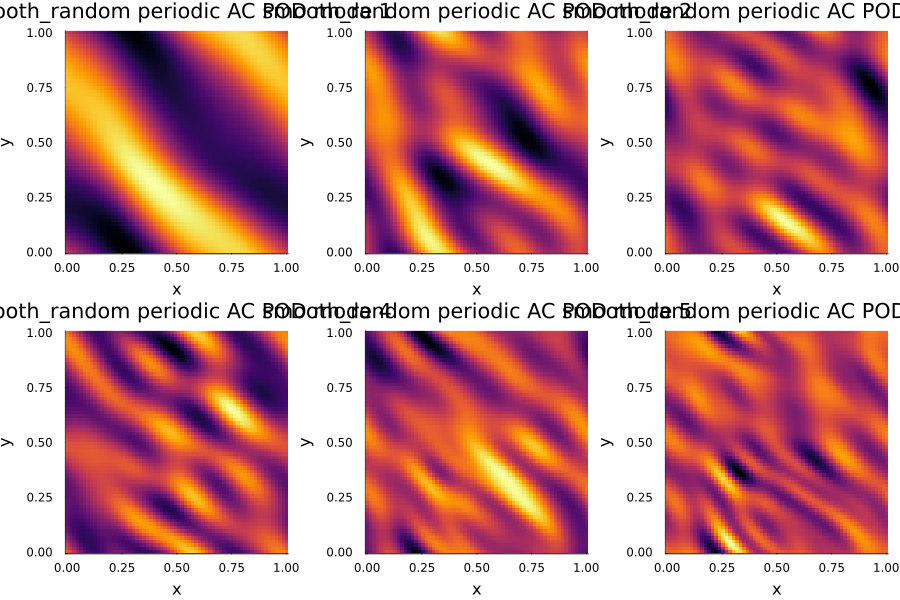

1-element Vector{Any}:
 Plot{Plots.GRBackend() n=6}

In [23]:
# plot POD modes 
experiment_1.plot_modes(num_modes = 6)

In [24]:
# print table with errors vs num modes
display_experiment_1_summary_table(experiment_1,
                                init_name = :smooth_random,
                                κ = .01,
                                r_values = (1,2,3,5,10),
                                m_values = (1,2,3,5,10),
                                m_first = false,
                                
                                )

| r | m | L2 error | relative L2 error | max L2 error | H1 seminorm error | relative H1 seminorm error | AC energy error | relative AC energy error | POD capture | DEIM capture |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 1 | 245.045 | 0.19063 | 12.1583 | 4151.58 | 0.335098 | 0.969866 | 0.0603689 | 0.7994 | 0.822812 |
| 1 | 2 | 245.753 | 0.191181 | 12.1583 | 4159.73 | 0.335757 | 0.969864 | 0.0603688 | 0.7994 | 0.949527 |
| 1 | 3 | 245.208 | 0.190757 | 12.1583 | 4152.48 | 0.335171 | 0.969853 | 0.0603681 | 0.7994 | 0.985935 |
| 1 | 5 | 248.639 | 0.193426 | 12.1583 | 4189.39 | 0.33815 | 0.969916 | 0.060372 | 0.7994 | 0.998418 |
| 1 | 10 | 248.005 | 0.192933 | 12.1583 | 4182.04 | 0.337557 | 0.969879 | 0.0603697 | 0.7994 | 0.999955 |
| 2 | 1 | 74.5453 | 0.0579917 | 3.32815 | 1191.64 | 0.0961839 | 0.187727 | 0.011685 | 0.952547 | 0.822812 |
| 2 | 2 | 59.3031 | 0.0461342 | 3.32815 | 1164.17 | 0.0939673 | 0.159096 | 0.00990285 | 0.952547 | 0.949527 |
| 2 | 3 | 59.2421 | 0.0460868 | 3.32815 | 1164.4 | 0.0939859 | 0.158929 | 0.00989248 | 0.952547 | 0.985935 |
| 2 | 5 | 59.3495 | 0.0461703 | 3.32815 | 1164.66 | 0.0940063 | 0.159441 | 0.00992433 | 0.952547 | 0.998418 |
| 2 | 10 | 58.3848 | 0.0454198 | 3.32815 | 1163.29 | 0.0938962 | 0.160216 | 0.00997259 | 0.952547 | 0.999955 |
| 3 | 1 | 50.1823 | 0.0390388 | 1.09322 | 630.877 | 0.0509218 | 0.0906729 | 0.0056439 | 0.98842 | 0.822812 |
| 3 | 2 | 16.6843 | 0.0129794 | 0.719972 | 293.658 | 0.0237028 | 0.0134744 | 0.000838707 | 0.98842 | 0.949527 |
| 3 | 3 | 15.1549 | 0.0117896 | 0.719972 | 292.648 | 0.0236213 | 0.0133728 | 0.000832385 | 0.98842 | 0.985935 |
| 3 | 5 | 14.2878 | 0.011115 | 0.719972 | 292.899 | 0.0236416 | 0.0128169 | 0.000797784 | 0.98842 | 0.998418 |
| 3 | 10 | 14.2214 | 0.0110634 | 0.719972 | 292.935 | 0.0236445 | 0.0127977 | 0.00079659 | 0.98842 | 0.999955 |
| 5 | 1 | 48.3445 | 0.0376091 | 1.09355 | 590.219 | 0.04764 | 0.0843061 | 0.0052476 | 0.999104 | 0.822812 |
| 5 | 2 | 9.99792 | 0.00777777 | 0.208297 | 158.488 | 0.0127925 | 0.00846291 | 0.00052677 | 0.999104 | 0.949527 |
| 5 | 3 | 6.21634 | 0.00483593 | 0.131375 | 103.16 | 0.00832662 | 0.01082 | 0.000673485 | 0.999104 | 0.985935 |
| 5 | 5 | 3.9368 | 0.00306259 | 0.1211 | 88.652 | 0.00715563 | 0.0100292 | 0.000624265 | 0.999104 | 0.998418 |
| 5 | 10 | 3.91532 | 0.00304588 | 0.124667 | 91.7451 | 0.00740529 | 0.0105526 | 0.000656839 | 0.999104 | 0.999955 |
| 10 | 1 | 48.8743 | 0.0380212 | 1.10466 | 597.368 | 0.0482171 | 0.0831954 | 0.00517846 | 0.999995 | 0.822812 |
| 10 | 2 | 10.2041 | 0.00793818 | 0.212156 | 166.596 | 0.0134469 | 0.00990508 | 0.000616537 | 0.999995 | 0.949527 |
| 10 | 3 | 6.35507 | 0.00494386 | 0.134907 | 108.837 | 0.00878489 | 0.0124967 | 0.000777851 | 0.999995 | 0.985935 |
| 10 | 5 | 4.18956 | 0.00325922 | 0.134074 | 95.7375 | 0.00772753 | 0.012069 | 0.000751229 | 0.999995 | 0.998418 |
| 10 | 10 | 4.18429 | 0.00325512 | 0.137072 | 98.986 | 0.00798974 | 0.012596 | 0.000784032 | 0.999995 | 0.999955 |

25-element Vector{NamedTuple}:
 (modes = 1, deim_modes = 1, L2_error = 245.04474923959017, relative_L2_error = 0.19062995888136136, max_L2_error = 12.15832553746978, H1_seminorm_error = 4151.57667962019, relative_H1_seminorm_error = 0.3350981551387972, AC_energy_error = 0.9698657932267847, relative_AC_energy_error = 0.06036887422169427, singular_value_capture = 0.7993996623851074, hyperreduction_singular_value_capture = 0.8228119439319554)
 (modes = 1, deim_modes = 2, L2_error = 245.75255899585412, relative_L2_error = 0.191180591960222, max_L2_error = 12.15832553746978, H1_seminorm_error = 4159.734952696207, relative_H1_seminorm_error = 0.3357566573098668, AC_energy_error = 0.9698642769728677, relative_AC_energy_error = 0.06036877984312907, singular_value_capture = 0.7993996623851074, hyperreduction_singular_value_capture = 0.9495266624553109)
 (modes = 1, deim_modes = 3, L2_error = 245.20759089218976, relative_L2_error = 0.190756639814683, max_L2_error = 12.15832553746978, H1_seminorm

# Experiment 2: Time Complexity
- build and ***time*** a sample FOM with random fourier combination initial conditoin, $\kappa = 0.01, F = $ double well polynomial. 
- the goal is to extract time complexity in terms of number of grid cells, number of POD modes, and number of DEIM modes/points. 

## Function to Run Experiment 2


In [26]:
## function for experiment 2 (Timing)

function time_ac_rom_fom_speedups_2D(
    r_values;
    m_values=nothing,
    permute=nothing,
    boundary_condition=:periodic,
    κ=0.01,
    f=(u -> u^3 - u),
    init_condition=:smooth_random,
    N_values=(8, 16, 32, 64),
    num_steps=Nsteps,
    T_final=T,
    samples=3,
    warmups=1,
)
    as_vector(v) = v isa Union{Tuple, AbstractArray, AbstractRange} ? collect(v) : [v]
    r_list = as_vector(r_values)
    m_list = isnothing(m_values) ? r_list : as_vector(m_values)
    N_list = as_vector(N_values)

    effective_permute = if isnothing(m_values)
        false
    elseif length(r_list) == length(m_list)
        isnothing(permute) ? false : permute
    else
        permute === false && error("r_values and m_values have different lengths")
        true
    end
    mode_pairs = effective_permute ? [(r=r, m=m) for r in r_list for m in m_list] : [(r=r, m=m) for (r, m) in zip(r_list, m_list)]

    init_function, init_label = if init_condition isa Symbol
        getfield(init_functions, init_condition), init_condition
    elseif init_condition isa Pair
        init_condition.second, init_condition.first
    else
        init_condition, :custom
    end

    function benchmark_seconds(g)
        result = Ref{Any}()
        for _ in 1:warmups
            result[] = g()
        end
        times = Float64[]
        for _ in 1:samples
            GC.gc()
            push!(times, @elapsed result[] = g())
        end
        result[] = nothing
        return median(times)
    end

    function initial_vector(init_function, N)
        bc = Symbol(lowercase(String(boundary_condition)))
        x_local = bc == :periodic ? range(0, step=1/N, length=N) : LinRange(0, 1, N)
        y_local = bc == :periodic ? range(0, step=1/N, length=N) : LinRange(0, 1, N)
        return vec([init_function(xi, yj) for xi in x_local, yj in y_local])
    end

    without_projection = Dict()
    with_projection = Dict()
    ts = LinRange(0, T_final, num_steps)

    for N in N_list
        println("Building AC timing case for init=$init_label, κ=$κ, boundary=$boundary_condition, N=$N")

        u0 = initial_vector(init_function, N)
        A = diffusion_2D_operator(κ, N, N; boundary_condition=boundary_condition)
        fom_prob = ODEProblem(ac_fom_rhs!, u0, (0.0, T_final), (A=A, f=f))

        training_traj = Array(solve(fom_prob, TRBDF2(), saveat=ts))
        pod_stride = max(1, num_steps ÷ 64)
        pod_sample = training_traj[:, 1:pod_stride:end]
        f_sample = nonlinear_snapshot_matrix(pod_sample, f)
        U_svd = svd(pod_sample).U
        max_r = maximum(r_list)
        max_m = maximum(m_list)
        U_all = U_svd[:, 1:max_r]

        fom_time = benchmark_seconds(() -> Array(solve(fom_prob, TRBDF2(), saveat=ts)))

        for pair in mode_pairs
            println("Timing AC DEIM ROM for N=$N, r=$(pair.r), m=$(pair.m)")
            U = U_all[:, 1:pair.r]
            Ared = U' * (A * U)
            rom = build_deim_rom_from_modes(A, f, U, f_sample, pair.m; reduced_operator=Ared)
            rom_prob = ODEProblem(ac_deim_rom_rhs!, U' * u0, (0.0, T_final), rom)

            rom_reduced_time = benchmark_seconds(() -> Array(solve(rom_prob, TRBDF2(), saveat=ts)))
            rom_projected_time = benchmark_seconds(() -> U * Array(solve(rom_prob, TRBDF2(), saveat=ts)))

            key = (Nx=N, r=pair.r, m=pair.m)
            without_projection[key] = (fom_time=fom_time, rom_time=rom_reduced_time, speedup=fom_time / rom_reduced_time)
            with_projection[key] = (fom_time=fom_time, rom_time=rom_projected_time, speedup=fom_time / rom_projected_time)
        end
    end

    return (without_projection=without_projection, with_projection=with_projection, mode_pairs=mode_pairs)
end


time_ac_rom_fom_speedups_2D (generic function with 1 method)

In [27]:
# functions to print and plot experiment 2

function print_ac_rom_fom_timing_table(timings)
    function print_one_table(title, table)
        println()
        println(title)
        println("-" ^ length(title))
        @printf("%8s  %8s  %8s  %14s  %14s  %12s\n", "N", "r", "m", "FOM time (s)", "ROM time (s)", "speedup")
        @printf("%8s  %8s  %8s  %14s  %14s  %12s\n", "-"^8, "-"^8, "-"^8, "-"^14, "-"^14, "-"^12)

        for key in sort(collect(keys(table)); by=k -> (k.Nx, k.r, k.m))
            value = table[key]
            @printf("%8d  %8d  %8d  %14.6g  %14.6g  %12.4g\n", key.Nx, key.r, key.m, value.fom_time, value.rom_time, value.speedup)
        end
    end

    println("2D Allen-Cahn DEIM ROM/FOM Timing Summary")
    print_one_table("ROM solve only", timings.without_projection)
    print_one_table("ROM solve + projection", timings.with_projection)
    return nothing
end

function plot_ac_speedup_from_time_data(
    time_data;
    N_values=nothing,
    r_values=nothing,
    m_values=nothing,
    mode_pairs=nothing,
    show_fit_labels=true,
    show_fit_lines=false,
)
    function fit_powerlaw_1D(xs, ys)
        xs = Float64.(xs)
        ys = Float64.(ys)
        length(xs) >= 2 || return nothing
        all(xs .> 0) || return nothing
        all(ys .> 0) || return nothing
        X = hcat(ones(length(xs)), log.(xs))
        coeffs = X \ log.(ys)
        C = exp(coeffs[1])
        α = coeffs[2]
        predicted = exp.(X * coeffs)
        relative_errors = abs.(predicted .- ys) ./ ys
        return (
            C=C,
            α=α,
            predict=N -> C * N^α,
            mean_relative_error=mean(relative_errors),
            max_relative_error=maximum(relative_errors),
            n_points=length(xs),
        )
    end

    function available_pairs(table)
        pairs = sort(unique((r=k.r, m=k.m) for k in keys(table)); by=p -> (p.r, p.m))
        if !isnothing(mode_pairs)
            requested = [(r=pair.r, m=pair.m) for pair in mode_pairs]
            pairs = [pair for pair in pairs if pair in requested]
        end
        if !isnothing(r_values)
            rs = collect(r_values)
            pairs = [pair for pair in pairs if pair.r in rs]
        end
        if !isnothing(m_values)
            ms = collect(m_values)
            pairs = [pair for pair in pairs if pair.m in ms]
        end
        return pairs
    end

    function fit_speedup_by_pair(table, pairs, Ns)
        fits = Dict{Any, Any}()
        for pair in pairs
            xs = Float64[]
            ys = Float64[]
            for N in Ns
                key = (Nx=N, r=pair.r, m=pair.m)
                if haskey(table, key)
                    push!(xs, Float64(N))
                    push!(ys, Float64(table[key].speedup))
                end
            end
            fit = fit_powerlaw_1D(xs, ys)
            !isnothing(fit) && (fits[pair] = fit)
        end
        return fits
    end

    function summarize_fits(fits)
        isempty(fits) && return nothing
        Cs = [fit.C for fit in values(fits)]
        αs = [fit.α for fit in values(fits)]
        return (
            mean_C=mean(Cs),
            median_C=median(Cs),
            mean_α=mean(αs),
            median_α=median(αs),
            n=length(αs),
        )
    end

    function summary_text(summary)
        isnothing(summary) && return "no pairwise fits"
        return @sprintf("speedup fits across %d pairs: median C=%.3g, mean C=%.3g, median α=%.3g, mean α=%.3g",
                        summary.n, summary.median_C, summary.mean_C, summary.median_α, summary.mean_α)
    end

    function plot_one(table, title_suffix)
        table_keys = collect(keys(table))
        xs_all = isnothing(N_values) ? sort(unique(k.Nx for k in table_keys)) : collect(N_values)
        pairs = available_pairs(table)
        speedup_fits = fit_speedup_by_pair(table, pairs, xs_all)
        fit_summary = summarize_fits(speedup_fits)

        p = plot(
            xlabel="N = Nx = Ny",
            ylabel="Speedup = FOM time / ROM time",
            title="2D Allen-Cahn DEIM Speedup\n$title_suffix\n$(summary_text(fit_summary))",
            legend=:outerright,
            marker=:circle,
            linewidth=2,
        )

        for pair in pairs
            xs = Float64[]
            ys = Float64[]
            for N in xs_all
                key = (Nx=N, r=pair.r, m=pair.m)
                if haskey(table, key)
                    push!(xs, Float64(N))
                    push!(ys, Float64(table[key].speedup))
                end
            end
            isempty(xs) && continue

            fit_label = if show_fit_labels && haskey(speedup_fits, pair)
                fit = speedup_fits[pair]
                @sprintf("r=%d, m=%d; S≈%.2gN^%.2g", pair.r, pair.m, fit.C, fit.α)
            else
                "r=$(pair.r), m=$(pair.m)"
            end
            plot!(p, xs, ys; label=fit_label)

            if show_fit_lines && haskey(speedup_fits, pair)
                fit = speedup_fits[pair]
                xfit = range(minimum(xs), stop=maximum(xs), length=100)
                yfit = [fit.predict(x) for x in xfit]
                plot!(p, xfit, yfit; label=false, linestyle=:dash, linewidth=1)
            end
        end

        return (plot=p, speedup_fits=speedup_fits, speedup_summary=fit_summary)
    end

    without_result = plot_one(time_data.without_projection, "ROM solve only")
    with_result = plot_one(time_data.with_projection, "ROM solve + projection")

    display(without_result.plot)
    display(with_result.plot)

    return (
        without_projection=without_result.plot,
        with_projection=with_result.plot,
        speedup_fits_without_projection=without_result.speedup_fits,
        speedup_fits_with_projection=with_result.speedup_fits,
        speedup_summary_without_projection=without_result.speedup_summary,
        speedup_summary_with_projection=with_result.speedup_summary,
    )
end


plot_ac_speedup_from_time_data (generic function with 1 method)

In [28]:
# calculate pairwise power laws across N for FOM, fixed (r, m), and speedup

function print_ac_powerlaw_fits(time_data; N_values=nothing, r_values=nothing, m_values=nothing, mode_pairs=nothing)
    function fit_powerlaw_1D(xs, ys)
        xs = Float64.(xs)
        ys = Float64.(ys)
        length(xs) >= 2 || error("Need at least 2 points to fit y = C * N^α")
        all(xs .> 0) || error("All N values must be positive")
        all(ys .> 0) || error("All fitted values must be positive")

        X = hcat(ones(length(xs)), log.(xs))
        coeffs = X \ log.(ys)
        C = exp(coeffs[1])
        α = coeffs[2]
        predicted = exp.(X * coeffs)
        relative_errors = abs.(predicted .- ys) ./ ys

        return (
            C=C,
            α=α,
            predict=N -> C * N^α,
            mean_relative_error=mean(relative_errors),
            max_relative_error=maximum(relative_errors),
            n_points=length(xs),
        )
    end

    function requested_Ns(table)
        table_keys = collect(keys(table))
        return isnothing(N_values) ? sort(unique(k.Nx for k in table_keys)) : collect(N_values)
    end

    function requested_pairs(table)
        pairs = sort(unique((r=k.r, m=k.m) for k in keys(table)); by=p -> (p.r, p.m))
        if !isnothing(mode_pairs)
            requested = [(r=pair.r, m=pair.m) for pair in mode_pairs]
            pairs = [pair for pair in pairs if pair in requested]
        end
        if !isnothing(r_values)
            rs = collect(r_values)
            pairs = [pair for pair in pairs if pair.r in rs]
        end
        if !isnothing(m_values)
            ms = collect(m_values)
            pairs = [pair for pair in pairs if pair.m in ms]
        end
        return pairs
    end

    function fit_fom_curve(table, Ns, pairs)
        xs = Float64[]
        ys = Float64[]
        for N in Ns
            vals = Float64[]
            for pair in pairs
                key = (Nx=N, r=pair.r, m=pair.m)
                haskey(table, key) && push!(vals, Float64(table[key].fom_time))
            end
            if !isempty(vals)
                push!(xs, Float64(N))
                push!(ys, mean(vals))
            end
        end
        return fit_powerlaw_1D(xs, ys)
    end

    function fit_pair_curves(table, Ns, pairs, value_field)
        fits = Dict{Any, Any}()
        for pair in pairs
            xs = Float64[]
            ys = Float64[]
            for N in Ns
                key = (Nx=N, r=pair.r, m=pair.m)
                if haskey(table, key)
                    push!(xs, Float64(N))
                    push!(ys, Float64(getfield(table[key], value_field)))
                end
            end
            if length(xs) >= 2
                fits[pair] = fit_powerlaw_1D(xs, ys)
            end
        end
        return fits
    end

    function implied_speedup_fits(fom_fit, rom_fits)
        fits = Dict{Any, Any}()
        for (pair, rom_fit) in rom_fits
            C_speedup = fom_fit.C / rom_fit.C
            α_speedup = fom_fit.α - rom_fit.α
            fits[pair] = (
                C=C_speedup,
                α=α_speedup,
                predict=N -> C_speedup * N^α_speedup,
                mean_relative_error=NaN,
                max_relative_error=NaN,
                n_points=min(fom_fit.n_points, rom_fit.n_points),
            )
        end
        return fits
    end

    function summarize_fits(fits)
        isempty(fits) && return nothing
        Cs = [fit.C for fit in values(fits)]
        αs = [fit.α for fit in values(fits)]
        return (
            n=length(αs),
            mean_C=mean(Cs),
            median_C=median(Cs),
            min_C=minimum(Cs),
            max_C=maximum(Cs),
            mean_α=mean(αs),
            median_α=median(αs),
            min_α=minimum(αs),
            max_α=maximum(αs),
        )
    end

    function summarize_by_field(fits, field)
        groups = sort(unique(getfield(pair, field) for pair in keys(fits)))
        return Dict(group => summarize_fits(Dict(pair => fits[pair] for pair in keys(fits) if getfield(pair, field) == group)) for group in groups)
    end

    function print_curve_fit(label, fit)
        @printf("%-24s %.6g * N^%.6g", label, fit.C, fit.α)
        @printf("    mean err = %6.2f%%, max err = %6.2f%%, points = %d\n",
                100 * fit.mean_relative_error,
                100 * fit.max_relative_error,
                fit.n_points)
    end

    function print_speedup_fit(label, fit)
        @printf("%-24s %.6g * N^%.6g\n", label, fit.C, fit.α)
    end

    function print_summary_table(title, summaries)
        println()
        println(title)
        println("-" ^ length(title))
        @printf("%8s  %8s  %12s  %12s  %12s  %12s\n", "value", "pairs", "median C", "mean C", "median α", "mean α")
        @printf("%8s  %8s  %12s  %12s  %12s  %12s\n", "-"^8, "-"^8, "-"^12, "-"^12, "-"^12, "-"^12)
        for group in sort(collect(keys(summaries)))
            summary = summaries[group]
            @printf("%8s  %8d  %12.6g  %12.6g  %12.6g  %12.6g\n",
                    string(group), summary.n, summary.median_C, summary.mean_C, summary.median_α, summary.mean_α)
        end
    end

    function fit_and_print(case_label, table)
        Ns = requested_Ns(table)
        pairs = requested_pairs(table)
        isempty(pairs) && error("No (r, m) pairs match the requested filters")

        println()
        println(case_label)
        println("-" ^ length(case_label))

        fom_fit = fit_fom_curve(table, Ns, pairs)
        rom_fits = fit_pair_curves(table, Ns, pairs, :rom_time)
        direct_speedup_fits = fit_pair_curves(table, Ns, pairs, :speedup)
        implied_speedups = implied_speedup_fits(fom_fit, rom_fits)

        println("Timing power laws: time(N) = C * N^α")
        print_curve_fit("FOM", fom_fit)
        for pair in sort(collect(keys(rom_fits)); by=p -> (p.r, p.m))
            print_curve_fit("ROM r=$(pair.r), m=$(pair.m)", rom_fits[pair])
        end

        println()
        println("Implied speedup power laws from FOM/ROM fits: speedup(N) = C * N^α")
        for pair in sort(collect(keys(implied_speedups)); by=p -> (p.r, p.m))
            print_speedup_fit("r=$(pair.r), m=$(pair.m)", implied_speedups[pair])
        end

        println()
        println("Direct speedup power laws fitted to stored speedup values: speedup(N) = C * N^α")
        for pair in sort(collect(keys(direct_speedup_fits)); by=p -> (p.r, p.m))
            print_curve_fit("speedup r=$(pair.r), m=$(pair.m)", direct_speedup_fits[pair])
        end

        rom_by_r = summarize_by_field(rom_fits, :r)
        rom_by_m = summarize_by_field(rom_fits, :m)
        speedup_by_r = summarize_by_field(implied_speedups, :r)
        speedup_by_m = summarize_by_field(implied_speedups, :m)

        print_summary_table("ROM fit summaries by fixed r, across m", rom_by_r)
        print_summary_table("ROM fit summaries by fixed m, across r", rom_by_m)
        print_summary_table("Implied speedup summaries by fixed r, across m", speedup_by_r)
        print_summary_table("Implied speedup summaries by fixed m, across r", speedup_by_m)

        return (
            fom=fom_fit,
            rom_by_pair=rom_fits,
            implied_speedup_by_pair=implied_speedups,
            direct_speedup_by_pair=direct_speedup_fits,
            rom_summary_by_r=rom_by_r,
            rom_summary_by_m=rom_by_m,
            implied_speedup_summary_by_r=speedup_by_r,
            implied_speedup_summary_by_m=speedup_by_m,
        )
    end

    println("2D Allen-Cahn DEIM ROM/FOM Pairwise Power-Law Fits")
    println("Primary model: fit each fixed (r, m) pair across N")
    println("Timing model: time(N) = C * N^α")
    println("Speedup model: speedup(N) = FOM_time(N) / ROM_time_(r,m)(N)")

    without_fit = fit_and_print("Without projection", time_data.without_projection)
    with_fit = fit_and_print("With projection", time_data.with_projection)

    return (without_projection=without_fit, with_projection=with_fit)
end


print_ac_powerlaw_fits (generic function with 1 method)

## Run Experiment 2


In [29]:
# run expriment 2

experiment_2_timings = time_ac_rom_fom_speedups_2D(
    (1, 2, 3, 5, 10);
    m_values=(1, 2, 3, 5, 10),
    permute=true,
    N_values=(8, 16, 24, 32),
    κ=0.01,
    boundary_condition=:periodic,
    init_condition=:smooth_random,
    samples=3,
    warmups=1,
)


Building AC timing case for init=smooth_random, κ=0.01, boundary=periodic, N=8
Timing AC DEIM ROM for N=8, r=1, m=1
Timing AC DEIM ROM for N=8, r=1, m=2
Timing AC DEIM ROM for N=8, r=1, m=3
Timing AC DEIM ROM for N=8, r=1, m=5
Timing AC DEIM ROM for N=8, r=1, m=10
Timing AC DEIM ROM for N=8, r=2, m=1
Timing AC DEIM ROM for N=8, r=2, m=2
Timing AC DEIM ROM for N=8, r=2, m=3
Timing AC DEIM ROM for N=8, r=2, m=5
Timing AC DEIM ROM for N=8, r=2, m=10
Timing AC DEIM ROM for N=8, r=3, m=1
Timing AC DEIM ROM for N=8, r=3, m=2
Timing AC DEIM ROM for N=8, r=3, m=3
Timing AC DEIM ROM for N=8, r=3, m=5
Timing AC DEIM ROM for N=8, r=3, m=10
Timing AC DEIM ROM for N=8, r=5, m=1
Timing AC DEIM ROM for N=8, r=5, m=2
Timing AC DEIM ROM for N=8, r=5, m=3
Timing AC DEIM ROM for N=8, r=5, m=5
Timing AC DEIM ROM for N=8, r=5, m=10
Timing AC DEIM ROM for N=8, r=10, m=1
Timing AC DEIM ROM for N=8, r=10, m=2
Timing AC DEIM ROM for N=8, r=10, m=3
Timing AC DEIM ROM for N=8, r=10, m=5
Timing AC DEIM ROM for N=

(without_projection = Dict{Any, Any}((Nx = 32, r = 10, m = 2) => (fom_time = 0.115270833, rom_time = 0.000511667, speedup = 225.28486886979226), (Nx = 16, r = 5, m = 1) => (fom_time = 0.007609709, rom_time = 0.000436459, speedup = 17.43510616117436), (Nx = 32, r = 1, m = 10) => (fom_time = 0.115270833, rom_time = 0.000428458, speedup = 269.03648198889977), (Nx = 32, r = 10, m = 10) => (fom_time = 0.115270833, rom_time = 0.000539833, speedup = 213.53054185275818), (Nx = 24, r = 5, m = 5) => (fom_time = 0.030108042, rom_time = 0.000466209, speedup = 64.58056794270381), (Nx = 32, r = 2, m = 2) => (fom_time = 0.115270833, rom_time = 0.000416083, speedup = 277.03807413424727), (Nx = 8, r = 5, m = 5) => (fom_time = 0.00128875, rom_time = 0.000490084, speedup = 2.6296512434603048), (Nx = 32, r = 2, m = 5) => (fom_time = 0.115270833, rom_time = 0.000411583, speedup = 280.0670411557329), (Nx = 32, r = 3, m = 1) => (fom_time = 0.115270833, rom_time = 0.000416667, speedup = 276.6497778801777), (N

In [30]:
# plot experiment 2 results
# print_ac_rom_fom_timing_table(experiment_2_timings)

# experiment_2_plots = plot_ac_speedup_from_time_data(
#     experiment_2_timings;
#     group_field=:r,
# )

experiment_2_fits = print_ac_powerlaw_fits(
    experiment_2_timings;
    N_values=(8, 16, 32),
    r_values=(1, 2, 3, 5, 10),
    m_values=(1, 2, 3, 5, 10),
)

2D Allen-Cahn DEIM ROM/FOM Pairwise Power-Law Fits
Primary model: fit each fixed (r, m) pair across N
Timing model: time(N) = C * N^α
Speedup model: speedup(N) = FOM_time(N) / ROM_time_(r,m)(N)

Without projection
------------------
Timing power laws: time(N) = C * N^α
FOM                      1.30212e-06 * N^3.24146    mean err =  21.99%, max err =  36.89%, points = 3
ROM r=1, m=1             0.000370174 * N^0.0188693    mean err =   1.67%, max err =   2.53%, points = 3
ROM r=1, m=2             0.000385027 * N^0.0164078    mean err =   2.44%, max err =   3.71%, points = 3
ROM r=1, m=3             0.000406608 * N^-0.00590729    mean err =   2.32%, max err =   3.53%, points = 3
ROM r=1, m=5             0.000469731 * N^-0.0541406    mean err =   1.03%, max err =   1.55%, points = 3
ROM r=1, m=10            0.000339282 * N^0.0681488    mean err =   0.38%, max err =   0.56%, points = 3
ROM r=2, m=1             0.000354273 * N^0.0600041    mean err =   0.71%, max err =   1.07%, points = 3
R

(without_projection = (fom = (C = 1.3021186117527741e-6, α = 3.2414556379781936, predict = var"#378#379"{Float64, Float64}(3.2414556379781936, 1.3021186117527741e-6), mean_relative_error = 0.21985372199131537, max_relative_error = 0.36893870784774735, n_points = 3), rom_by_pair = Dict{Any, Any}((r = 5, m = 1) => (C = 0.0004994500479803244, α = -0.042485928194114383, predict = var"#378#379"{Float64, Float64}(-0.042485928194114383, 0.0004994500479803244), mean_relative_error = 0.011369236357947907, max_relative_error = 0.017162758168288956, n_points = 3), (r = 2, m = 10) => (C = 0.00045913066933163794, α = -0.013934987765397464, predict = var"#378#379"{Float64, Float64}(-0.013934987765397464, 0.00045913066933163794), mean_relative_error = 0.011661712956131819, max_relative_error = 0.017377660520302235, n_points = 3), (r = 10, m = 10) => (C = 0.0005114048455006546, α = 0.018896629238762144, predict = var"#378#379"{Float64, Float64}(0.018896629238762144, 0.0005114048455006546), mean_relati

# Experiment 3: Transferability Across Operators
- Use the POD/DEIM data from Experiment 1 as the transfer ROM.
- Test that ROM on new κ values while keeping the Allen-Cahn double-well free energy fixed.
- Build matched ROMs trained at each test κ and compare transfer vs matched errors for every `(r, m)` pair used by Experiment 1.


## Functions for Experiments 3, 3.5, and 4


In [ ]:

# Shared tooling for Allen-Cahn transfer experiments 3, 3.5, and 4.

function run_ac_transfer_comparison(
    base_experiment,
    experiment_label,
    cases;
    experiment_id,
    transfer_kind,
    boundary_condition=nothing,
)
    println("Running $experiment_label")

    local_as_tuple(v) = v isa Tuple ? v : v isa AbstractArray ? Tuple(v) : v isa AbstractRange ? Tuple(v) : (v,)
    has_nt_field(nt, field) = nt isa NamedTuple && field in propertynames(nt)

    boundary = if isnothing(boundary_condition) && has_nt_field(base_experiment, :boundary_condition)
        Symbol(lowercase(String(base_experiment.boundary_condition)))
    elseif isnothing(boundary_condition)
        :dirichlet
    else
        Symbol(lowercase(String(boundary_condition)))
    end
    boundary in (:dirichlet, :periodic) || error("boundary_condition must be :dirichlet or :periodic")

    base_reaction_label = has_nt_field(base_experiment, :reaction_label) ? base_experiment.reaction_label : :standard_ac
    base_κ_train = base_experiment.κ_train
    base_mode_pairs = if has_nt_field(base_experiment, :mode_pairs)
        [(r=pair.r, m=pair.m) for pair in base_experiment.mode_pairs]
    elseif has_nt_field(base_experiment, :rs)
        [(r=r, m=r) for r in base_experiment.rs]
    else
        error("base_experiment must expose mode_pairs or rs")
    end
    isempty(base_mode_pairs) && error("base_experiment has no mode pairs")
    rs = sort(unique(pair.r for pair in base_mode_pairs))
    ms = sort(unique(pair.m for pair in base_mode_pairs))
    max_r = maximum(rs)
    max_m = maximum(ms)

    case_list = collect(cases)
    isempty(case_list) && error("cases must contain at least one transfer case")

    time_grid = LinRange(0, T, Nsteps)
    plot_stride = max(1, Nsteps ÷ 32)
    plot_times = 1:plot_stride:Nsteps
    pod_stride = max(1, Nsteps ÷ 64)

    function require_base_training_data!(name)
        has_nt_field(base_experiment, :modes) || error("base_experiment has no modes field")
        haskey(base_experiment.modes, name) || error("base_experiment has no POD modes for init_name=$name")
        size(base_experiment.modes[name], 2) >= max_r || error("base_experiment has only $(size(base_experiment.modes[name], 2)) POD modes for $name, but r=$max_r was requested")

        has_nt_field(base_experiment, :nonlinear_training_snapshots) || error("base_experiment has no nonlinear_training_snapshots field; rerun Allen-Cahn Experiment 1")
        haskey(base_experiment.nonlinear_training_snapshots, name) || error("base_experiment has no nonlinear snapshots for init_name=$name")
        nonlinear_modes = min(size(base_experiment.nonlinear_training_snapshots[name], 1), size(base_experiment.nonlinear_training_snapshots[name], 2))
        max_m <= nonlinear_modes || error("base_experiment has only $nonlinear_modes nonlinear snapshot modes for $name, but m=$max_m was requested")
        return nothing
    end

    for case in case_list
        require_base_training_data!(case.transfer_init_name)
    end

    function fom_key(case)
        return (equation=:allen_cahn, reaction=case.reaction_label, init_name=case.init_name, κ=case.κ, boundary=boundary, FOM=true)
    end

    function transfer_rom_key(case, r, m)
        return (
            equation=:allen_cahn,
            reaction=case.reaction_label,
            reaction_train=base_reaction_label,
            init_name=case.init_name,
            init_train=case.transfer_init_name,
            κ=case.κ,
            κ_train=base_κ_train,
            boundary=boundary,
            FOM=false,
            experiment=experiment_id,
            transfer_kind=transfer_kind,
            rom_case=:transfer,
            r=r,
            m=m,
            hyperreduction=:deim,
        )
    end

    function matched_rom_key(case, r, m)
        return (
            equation=:allen_cahn,
            reaction=case.reaction_label,
            reaction_train=case.reaction_label,
            init_name=case.init_name,
            init_train=case.init_name,
            κ=case.κ,
            κ_train=case.κ,
            boundary=boundary,
            FOM=false,
            experiment=experiment_id,
            transfer_kind=transfer_kind,
            rom_case=:matched,
            r=r,
            m=m,
            hyperreduction=:deim,
        )
    end

    function discard_stored_rom_trajectories!()
        keys_to_delete = [
            key for key in keys(data)
            if haskey(key, :FOM) && key.FOM == false &&
               haskey(key, :experiment) && key.experiment == experiment_id &&
               haskey(key, :transfer_kind) && key.transfer_kind == transfer_kind
        ]
        for key in keys_to_delete
            delete!(data, key)
        end
        if !isempty(keys_to_delete)
            println("Removed $(length(keys_to_delete)) stored ROM trajectories for $experiment_id; ROM trajectories will be computed locally and discarded")
            GC.gc()
        end
        return keys_to_delete
    end

    discard_stored_rom_trajectories!()

    matched_train_key(case) = (init_name=case.init_name, κ=case.κ, reaction=case.reaction_label, case_id=case.case_id)

    function metric_key(case, rom_case, r, m)
        return (
            case_id=case.case_id,
            case_label=case.case_label,
            rom_case=rom_case,
            init_train=rom_case == :transfer ? case.transfer_init_name : case.init_name,
            init_name=case.init_name,
            κ_train=rom_case == :transfer ? base_κ_train : case.κ,
            κ=case.κ,
            reaction_train=rom_case == :transfer ? base_reaction_label : case.reaction_label,
            reaction=case.reaction_label,
            r=r,
            m=m,
        )
    end

    function ensure_fom!(case)
        key = fom_key(case)
        if !haskey(data, key)
            println("Solving AC FOM for $(case.case_label), init=$(case.init_name), κ=$(case.κ), reaction=$(case.reaction_label), boundary=$boundary")
            data[key] = AC_2D_trajectory(
                case.init_function,
                T,
                case.κ,
                Nx,
                Ny,
                false;
                f=case.f,
                num_steps=Nsteps,
                boundary_condition=boundary,
            )
        end
        return data[key]
    end

    println("Getting required FOM trajectories")
    for case in case_list
        ensure_fom!(case)
    end

    matched_pod_snapshots = Dict()
    matched_pod_svd = Dict()
    matched_modes = Dict()
    matched_singular_values = Dict()
    matched_nonlinear_snapshots = Dict()
    matched_nonlinear_singular_values = Dict()

    function build_matched_training!(case)
        train_key = matched_train_key(case)
        if !haskey(matched_pod_svd, train_key)
            sampled_fom = trajectory_sample(ensure_fom!(case); stride=pod_stride)
            f_snapshots = trajectory_sample(nonlinear_snapshot_matrix(ensure_fom!(case), case.f); stride=pod_stride)
            matched_pod_snapshots[train_key] = sampled_fom
            matched_pod_svd[train_key] = svd(sampled_fom)
            matched_modes[train_key] = matched_pod_svd[train_key].U[:, 1:max_r]
            matched_singular_values[train_key] = matched_pod_svd[train_key].S
            matched_nonlinear_snapshots[train_key] = f_snapshots
            matched_nonlinear_singular_values[train_key] = svdvals(f_snapshots)

            nonlinear_modes = min(size(f_snapshots, 1), size(f_snapshots, 2))
            max_m <= nonlinear_modes || error("Matched nonlinear snapshots for $(case.case_label) provide only $nonlinear_modes modes, but m=$max_m was requested")
        end
        return train_key
    end

    singular_value_capture_ratios = Dict()
    hyperreduction_singular_value_capture_ratios = Dict()

    function singular_value_capture_ratio(S, n)
        total = sum(S)
        total == 0 && return NaN
        return sum(S[1:min(n, length(S))]) / total
    end

    function base_pod_capture_ratio(name, r)
        ratio_key = (init_name=name, r=r)
        if has_nt_field(base_experiment, :singular_value_capture_ratios) && haskey(base_experiment.singular_value_capture_ratios, ratio_key)
            return base_experiment.singular_value_capture_ratios[ratio_key]
        elseif has_nt_field(base_experiment, :singular_values) && haskey(base_experiment.singular_values, name)
            return singular_value_capture_ratio(base_experiment.singular_values[name], r)
        end
        return NaN
    end

    function base_hyperreduction_capture_ratio(name, m)
        ratio_key = (init_name=name, m=m)
        if has_nt_field(base_experiment, :hyperreduction_singular_value_capture_ratios) && haskey(base_experiment.hyperreduction_singular_value_capture_ratios, ratio_key)
            return base_experiment.hyperreduction_singular_value_capture_ratios[ratio_key]
        elseif has_nt_field(base_experiment, :nonlinear_singular_values) && haskey(base_experiment.nonlinear_singular_values, name)
            return singular_value_capture_ratio(base_experiment.nonlinear_singular_values[name], m)
        end
        return NaN
    end

    function solve_deim_rom_trajectory(case, key, U, f_snapshots, r, m; deim_modes, deim_indices, reduced_operators)
        A = diffusion_2D_operator(case.κ, Nx, Ny; boundary_condition=boundary)
        reduced_operator = U' * (A * U)
        rom = build_deim_rom_from_modes(A, case.f, U, f_snapshots, m; reduced_operator=reduced_operator)
        deim_modes[key] = rom.V
        deim_indices[key] = rom.p
        reduced_operators[key] = rom.Ã
        return AC_2D_trajectory(
            case.init_function,
            T,
            case.κ,
            Nx,
            Ny,
            true,
            r;
            f=case.f,
            num_steps=Nsteps,
            boundary_condition=boundary,
            rom=rom,
        )
    end

    function ensure_transfer_rom!(case, r, m)
        key = transfer_rom_key(case, r, m)
        println("Solving transfer AC DEIM ROM for $(case.case_label), init_train=$(case.transfer_init_name), init_test=$(case.init_name), κ=$(case.κ), r=$r, m=$m")
        rom_traj = solve_deim_rom_trajectory(
            case,
            key,
            base_experiment.modes[case.transfer_init_name][:, 1:r],
            base_experiment.nonlinear_training_snapshots[case.transfer_init_name],
            r,
            m;
            deim_modes=transfer_deim_modes,
            deim_indices=transfer_deim_indices,
            reduced_operators=transfer_reduced_operators,
        )
        singular_value_capture_ratios[(rom_case=:transfer, case_id=case.case_id, init_train=case.transfer_init_name, init_name=case.init_name, r=r, m=m)] = base_pod_capture_ratio(case.transfer_init_name, r)
        hyperreduction_singular_value_capture_ratios[(rom_case=:transfer, case_id=case.case_id, init_train=case.transfer_init_name, init_name=case.init_name, r=r, m=m)] = base_hyperreduction_capture_ratio(case.transfer_init_name, m)
        return rom_traj
    end

    function ensure_matched_rom!(case, r, m)
        key = matched_rom_key(case, r, m)
        train_key = build_matched_training!(case)
        println("Solving matched AC DEIM ROM for $(case.case_label), init=$(case.init_name), κ=$(case.κ), reaction=$(case.reaction_label), r=$r, m=$m")
        rom_traj = solve_deim_rom_trajectory(
            case,
            key,
            matched_modes[train_key][:, 1:r],
            matched_nonlinear_snapshots[train_key],
            r,
            m;
            deim_modes=matched_deim_modes,
            deim_indices=matched_deim_indices,
            reduced_operators=matched_reduced_operators,
        )
        singular_value_capture_ratios[(rom_case=:matched, case_id=case.case_id, init_train=case.init_name, init_name=case.init_name, r=r, m=m)] = singular_value_capture_ratio(matched_singular_values[train_key], r)
        hyperreduction_singular_value_capture_ratios[(rom_case=:matched, case_id=case.case_id, init_train=case.init_name, init_name=case.init_name, r=r, m=m)] = singular_value_capture_ratio(matched_nonlinear_singular_values[train_key], m)
        return rom_traj
    end

    transfer_errors = Dict()
    transfer_relative_errors = Dict()
    transfer_max_errors = Dict()
    transfer_h1_seminorm_errors = Dict()
    transfer_relative_h1_seminorm_errors = Dict()
    transfer_energy_errors = Dict()
    transfer_relative_energy_errors = Dict()
    transfer_error_over_time = Dict()
    transfer_relative_error_over_time = Dict()
    transfer_max_abs_error_over_time = Dict()
    transfer_h1_seminorm_error_over_time = Dict()
    transfer_relative_h1_seminorm_error_over_time = Dict()
    transfer_energy_error_over_time = Dict()
    transfer_relative_energy_error_over_time = Dict()

    matched_errors = Dict()
    matched_relative_errors = Dict()
    matched_max_errors = Dict()
    matched_h1_seminorm_errors = Dict()
    matched_relative_h1_seminorm_errors = Dict()
    matched_energy_errors = Dict()
    matched_relative_energy_errors = Dict()
    matched_error_over_time = Dict()
    matched_relative_error_over_time = Dict()
    matched_max_abs_error_over_time = Dict()
    matched_h1_seminorm_error_over_time = Dict()
    matched_relative_h1_seminorm_error_over_time = Dict()
    matched_energy_error_over_time = Dict()
    matched_relative_energy_error_over_time = Dict()

    ac_energy_over_time = Dict()

    metric_dicts = (
        transfer=(
            L2=transfer_errors,
            relative_L2=transfer_relative_errors,
            max_L2=transfer_max_errors,
            H1_seminorm=transfer_h1_seminorm_errors,
            relative_H1_seminorm=transfer_relative_h1_seminorm_errors,
            energy=transfer_energy_errors,
            relative_energy=transfer_relative_energy_errors,
            L2_over_time=transfer_error_over_time,
            relative_L2_over_time=transfer_relative_error_over_time,
            max_abs_over_time=transfer_max_abs_error_over_time,
            H1_seminorm_over_time=transfer_h1_seminorm_error_over_time,
            relative_H1_seminorm_over_time=transfer_relative_h1_seminorm_error_over_time,
            energy_over_time=transfer_energy_error_over_time,
            relative_energy_over_time=transfer_relative_energy_error_over_time,
        ),
        matched=(
            L2=matched_errors,
            relative_L2=matched_relative_errors,
            max_L2=matched_max_errors,
            H1_seminorm=matched_h1_seminorm_errors,
            relative_H1_seminorm=matched_relative_h1_seminorm_errors,
            energy=matched_energy_errors,
            relative_energy=matched_relative_energy_errors,
            L2_over_time=matched_error_over_time,
            relative_L2_over_time=matched_relative_error_over_time,
            max_abs_over_time=matched_max_abs_error_over_time,
            H1_seminorm_over_time=matched_h1_seminorm_error_over_time,
            relative_H1_seminorm_over_time=matched_relative_h1_seminorm_error_over_time,
            energy_over_time=matched_energy_error_over_time,
            relative_energy_over_time=matched_relative_energy_error_over_time,
        ),
    )

    function energy_for(case, key)
        if !haskey(ac_energy_over_time, key)
            haskey(data, key) || error("Energy data for key $key was not stored. ROM trajectories are intentionally discarded; rerun the experiment to regenerate compact diagnostics.")
            ac_energy_over_time[key] = trajectory_allen_cahn_energy_over_time(data[key], key.κ, case.F; boundary_condition=key.boundary)
        end
        return ac_energy_over_time[key]
    end

    function energy_for_trajectory!(case, key, traj)
        if !haskey(ac_energy_over_time, key)
            ac_energy_over_time[key] = trajectory_allen_cahn_energy_over_time(traj, key.κ, case.F; boundary_condition=key.boundary)
        end
        return ac_energy_over_time[key]
    end

    function fill_metric_dicts!(dicts, key, case, fom, rom, fom_data_key, rom_data_key)
        fom_energy = energy_for_trajectory!(case, fom_data_key, fom)
        rom_energy = energy_for_trajectory!(case, rom_data_key, rom)
        energy_diff = fom_energy - rom_energy

        dicts.L2_over_time[key] = trajectory_L2_error_over_time(fom, rom)
        dicts.relative_L2_over_time[key] = trajectory_relative_L2_error_over_time(fom, rom)
        dicts.max_abs_over_time[key] = trajectory_max_abs_error_over_time(fom, rom)
        dicts.H1_seminorm_over_time[key] = trajectory_H1_seminorm_error_over_time(fom, rom; boundary_condition=boundary)
        dicts.relative_H1_seminorm_over_time[key] = trajectory_relative_H1_seminorm_error_over_time(fom, rom; boundary_condition=boundary)
        dicts.energy_over_time[key] = abs.(energy_diff)
        dicts.relative_energy_over_time[key] = abs.(energy_diff) ./ (abs.(fom_energy) .+ eps(Float64))

        dicts.L2[key] = trajectory_L2_error(fom, rom)
        dicts.relative_L2[key] = trajectory_relative_L2_error(fom, rom)
        dicts.max_L2[key] = maximum(dicts.L2_over_time[key])
        dicts.H1_seminorm[key] = trajectory_H1_seminorm_error(fom, rom; boundary_condition=boundary)
        dicts.relative_H1_seminorm[key] = trajectory_relative_H1_seminorm_error(fom, rom; boundary_condition=boundary)
        dicts.energy[key] = norm(energy_diff)
        dicts.relative_energy[key] = norm(energy_diff) / (norm(fom_energy) + eps(Float64))
        return key
    end

    println("Solving transfer and matched ROMs, then calculating errors")
    for case in case_list, pair in base_mode_pairs
        f_key = fom_key(case)
        fom = ensure_fom!(case)

        transfer_data_key = transfer_rom_key(case, pair.r, pair.m)
        transfer_rom = ensure_transfer_rom!(case, pair.r, pair.m)
        fill_metric_dicts!(metric_dicts.transfer, metric_key(case, :transfer, pair.r, pair.m), case, fom, transfer_rom, f_key, transfer_data_key)

        matched_data_key = matched_rom_key(case, pair.r, pair.m)
        matched_rom = ensure_matched_rom!(case, pair.r, pair.m)
        fill_metric_dicts!(metric_dicts.matched, metric_key(case, :matched, pair.r, pair.m), case, fom, matched_rom, f_key, matched_data_key)
    end
    GC.gc()

    function selected_mode_pairs(; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs)
        selected = [(r=pair.r, m=pair.m) for pair in mode_pairs]
        r_filter = isnothing(r_values) ? nothing : collect(local_as_tuple(r_values))
        m_filter = isnothing(m_values) ? nothing : collect(local_as_tuple(m_values))
        selected = [pair for pair in selected if (isnothing(r_filter) || pair.r in r_filter) && (isnothing(m_filter) || pair.m in m_filter)]
        isempty(selected) && error("No mode pairs match the requested r/m filters")
        return selected
    end

    function rom_case_list(rom_case)
        rom_case == :both && return (:transfer, :matched)
        rom_case in (:transfer, :matched) || error("rom_case must be :transfer, :matched, or :both")
        return (rom_case,)
    end

    function case_label(rom_case, case)
        rom_case == :transfer && return "transfer train=$(case.transfer_init_name), κ=$(base_κ_train), reaction=$(base_reaction_label)"
        rom_case == :matched && return "matched train=$(case.init_name), κ=$(case.κ), reaction=$(case.reaction_label)"
        return string(rom_case)
    end

    function scalar_metric_dict(rom_case, metric)
        dicts = rom_case == :transfer ? metric_dicts.transfer : metric_dicts.matched
        if metric == :L2
            return dicts.L2, "L2 error"
        elseif metric in (:relative, :relative_L2)
            return dicts.relative_L2, "relative L2 error"
        elseif metric in (:max, :max_L2)
            return dicts.max_L2, "max L2 error"
        elseif metric in (:H1, :h1, :H1_seminorm, :h1_seminorm)
            return dicts.H1_seminorm, "H1 seminorm error"
        elseif metric in (:relative_H1, :relative_h1, :relative_H1_seminorm, :relative_h1_seminorm)
            return dicts.relative_H1_seminorm, "relative H1 seminorm error"
        elseif metric in (:energy, :AC_energy, :allen_cahn_energy)
            return dicts.energy, "Allen-Cahn energy error"
        elseif metric in (:relative_energy, :relative_AC_energy, :relative_allen_cahn_energy)
            return dicts.relative_energy, "relative Allen-Cahn energy error"
        else
            error("Unknown metric=$metric")
        end
    end

    function time_metric_dict(rom_case, metric)
        dicts = rom_case == :transfer ? metric_dicts.transfer : metric_dicts.matched
        if metric == :L2
            return dicts.L2_over_time, "L2 error"
        elseif metric in (:relative, :relative_L2)
            return dicts.relative_L2_over_time, "relative L2 error"
        elseif metric in (:max, :max_abs, :Linf, :linf)
            return dicts.max_abs_over_time, "max absolute error"
        elseif metric in (:H1, :h1, :H1_seminorm, :h1_seminorm)
            return dicts.H1_seminorm_over_time, "H1 seminorm error"
        elseif metric in (:relative_H1, :relative_h1, :relative_H1_seminorm, :relative_h1_seminorm)
            return dicts.relative_H1_seminorm_over_time, "relative H1 seminorm error"
        elseif metric in (:energy, :AC_energy, :allen_cahn_energy)
            return dicts.energy_over_time, "Allen-Cahn energy error"
        elseif metric in (:relative_energy, :relative_AC_energy, :relative_allen_cahn_energy)
            return dicts.relative_energy_over_time, "relative Allen-Cahn energy error"
        else
            error("Unknown metric=$metric")
        end
    end

    canonical_metric(metric) = metric in (:relative, :relative_L2) ? :relative_L2 :
        metric in (:max, :max_L2) ? :max_L2 :
        metric in (:H1, :h1, :H1_seminorm, :h1_seminorm) ? :H1_seminorm :
        metric in (:relative_H1, :relative_h1, :relative_H1_seminorm, :relative_h1_seminorm) ? :relative_H1_seminorm :
        metric in (:energy, :AC_energy, :allen_cahn_energy) ? :energy :
        metric in (:relative_energy, :relative_AC_energy, :relative_allen_cahn_energy) ? :relative_energy : metric

    function cases_for_filter(case_values)
        isnothing(case_values) && return case_list
        vals = collect(local_as_tuple(case_values))
        return [case for case in case_list if case.case_id in vals || case.x_value in vals || case.init_name in vals]
    end

    sparse_marker_indices(idxs, marker_stride) = idxs[1:max(1, marker_stride):end]

    function pair_label(pair)
        return "r=$(pair.r), m=$(pair.m)"
    end

    function plot_style_helpers(pair_values, cases)
        pair_list = collect(pair_values)
        case_plot_list = collect(cases)
        pair_colors = (:blue, :red, :green, :purple, :orange, :cyan, :magenta, :brown, :navy, :gold)
        case_line_styles = (:solid, :dash, :dot, :dashdot, :dashdotdot)
        case_markers = (:circle, :square, :diamond, :utriangle, :dtriangle, :xcross, :cross, :star5, :hexagon, :pentagon)
        pair_index(pair) = something(findfirst(q -> q.r == pair.r && q.m == pair.m, pair_list), 1)
        case_index(case) = something(findfirst(c -> c.case_id == case.case_id, case_plot_list), 1)
        color_for_pair(pair) = pair_colors[mod1(pair_index(pair), length(pair_colors))]
        line_for_case(case) = case_line_styles[mod1(case_index(case), length(case_line_styles))]
        marker_for_case(case) = case_markers[mod1(case_index(case), length(case_markers))]
        return (pair_list=pair_list, case_list=case_plot_list, color_for_pair=color_for_pair, line_for_case=line_for_case, marker_for_case=marker_for_case)
    end

    plot_errors = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, error_kind=:relative_L2, rom_case=:both, marker_size=5, display_plot=true)
        cases_to_plot = cases_for_filter(case_values)
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        cases = rom_case_list(rom_case)
        styles = plot_style_helpers(pairs_to_plot, cases_to_plot)
        _, ylabel = scalar_metric_dict(first(cases), error_kind)
        plots = Any[]

        for case_kind in cases
            raw_xs = [case.x_value for case in cases_to_plot]
            categorical_x = any(!(x isa Number) for x in raw_xs)
            xs_plot = categorical_x ? collect(1:length(raw_xs)) : raw_xs
            p = plot(title="$experiment_label $ylabel ($(case_kind), $boundary)", xlabel=case_list[1].x_label, ylabel=ylabel, legend=:outerright)
            categorical_x && plot!(p; xticks=(xs_plot, string.(raw_xs)))
            for pair in styles.pair_list
                ys = [begin
                    data_dict, _ = scalar_metric_dict(case_kind, error_kind)
                    data_dict[metric_key(case, case_kind, pair.r, pair.m)]
                end for case in cases_to_plot]
                plot!(p, xs_plot, ys; color=styles.color_for_pair(pair), lw=2, label=pair_label(pair))
                for (case, xval, yval) in zip(cases_to_plot, xs_plot, ys)
                    scatter!(p, [xval], [yval]; color=styles.color_for_pair(pair), marker=styles.marker_for_case(case), markersize=marker_size, label=false)
                end
            end
            (!categorical_x && case_list[1].x_logscale) && plot!(p; xscale=:log10)
            display_plot && display(p)
            push!(plots, p)
        end
        return plots
    end

    plot_error_over_time = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, error_kind=:relative_L2, rom_case=:both, time_indices=plot_times, marker_stride=8, display_plot=true)
        cases_to_plot = cases_for_filter(case_values)
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        case_kinds = rom_case_list(rom_case)
        idxs = collect(local_as_tuple(time_indices))
        marker_idxs = sparse_marker_indices(idxs, marker_stride)
        plots = Any[]

        for case in cases_to_plot
            styles = plot_style_helpers(pairs_to_plot, (case,))
            _, ylabel = time_metric_dict(first(case_kinds), error_kind)
            p = plot(title="$experiment_label $(case.case_label) $ylabel over time ($boundary)", xlabel="t", ylabel=ylabel, legend=:outerright)
            for case_kind in case_kinds, pair in styles.pair_list
                data_dict, _ = time_metric_dict(case_kind, error_kind)
                series = data_dict[metric_key(case, case_kind, pair.r, pair.m)]
                ls = case_kind == :transfer ? :dash : :solid
                plot!(p, time_grid[idxs], series[idxs]; color=styles.color_for_pair(pair), ls=ls, lw=2, label="$(pair_label(pair)) $(case_kind)")
                scatter!(p, time_grid[marker_idxs], series[marker_idxs]; color=styles.color_for_pair(pair), marker=styles.marker_for_case(case), markersize=3, label=false)
            end
            display_plot && display(p)
            push!(plots, p)
        end
        return plots
    end

    function data_key_for(case, rom_case, r, m)
        rom_case == :fom && return fom_key(case)
        rom_case == :transfer && return transfer_rom_key(case, r, m)
        rom_case == :matched && return matched_rom_key(case, r, m)
        error("rom_case must be :fom, :transfer, or :matched")
    end

    plot_trajs = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, rom_case=:fom, time_indices=plot_times, fps=10, clims=nothing, display_plot=true)
        rom_case == :fom || @warn "ROM trajectories are not stored for transfer experiments; plotting FOM trajectories only. Use plot_error_over_time or plot_allen_cahn_energy for ROM diagnostics."
        cases_to_plot = cases_for_filter(case_values)
        outputs = Any[]

        for case in cases_to_plot
            key = fom_key(case)
            haskey(data, key) || error("Missing FOM trajectory for key $key")
            traj = data[key]
            c = isnothing(clims) ? (minimum(traj), maximum(traj)) : clims
            anim = @animate for t in local_as_tuple(time_indices)
                heatmap(
                    x,
                    y,
                    trajectory_frame(traj, t)',
                    title="$(case.case_label) FOM, t=$(round(time_grid[t]; digits=3))",
                    xlabel="x",
                    ylabel="y",
                    aspect_ratio=:equal,
                    clims=c,
                )
            end
            output = gif(anim, fps=fps)
            display_plot && display(output)
            push!(outputs, output)
        end
        return outputs
    end

    plot_allen_cahn_energy = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, rom_case=:both, time_indices=plot_times, marker_stride=8, display_plot=true)
        cases_to_plot = cases_for_filter(case_values)
        pairs_to_plot = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        case_kinds = rom_case_list(rom_case)
        idxs = collect(local_as_tuple(time_indices))
        marker_idxs = sparse_marker_indices(idxs, marker_stride)
        plots = Any[]

        for case in cases_to_plot
            styles = plot_style_helpers(pairs_to_plot, (case,))
            p = plot(title="$experiment_label $(case.case_label) Allen-Cahn energy ($boundary)", xlabel="t", ylabel="E_AC(u)", legend=:outerright)
            f_key = fom_key(case)
            energy = energy_for(case, f_key)
            plot!(p, time_grid[idxs], energy[idxs]; color=:black, lw=3, label="FOM")
            scatter!(p, time_grid[marker_idxs], energy[marker_idxs]; color=:black, marker=styles.marker_for_case(case), markersize=3, label=false)
            for case_kind in case_kinds, pair in styles.pair_list
                key = data_key_for(case, case_kind, pair.r, pair.m)
                energy = energy_for(case, key)
                ls = case_kind == :transfer ? :dash : :solid
                plot!(p, time_grid[idxs], energy[idxs]; color=styles.color_for_pair(pair), ls=ls, lw=2, label="$(pair_label(pair)) $(case_kind)")
                scatter!(p, time_grid[marker_idxs], energy[marker_idxs]; color=styles.color_for_pair(pair), marker=styles.marker_for_case(case), markersize=3, label=false)
            end
            display_plot && display(p)
            push!(plots, p)
        end
        return plots
    end

    plot_dirichlet_energy = plot_allen_cahn_energy

    plot_modes = function (; case_values=nothing, num_modes=6, rom_case=:matched, ncols=3, size=nothing, colorbar=false, display_plot=true)
        cases_to_plot = cases_for_filter(case_values)
        case_kinds = rom_case == :both ? (:transfer, :matched) : rom_case_list(rom_case)
        plots = Any[]
        for case in cases_to_plot, case_kind in case_kinds
            mode_data = if case_kind == :transfer
                base_experiment.modes[case.transfer_init_name][:, 1:num_modes]
            else
                train_key = build_matched_training!(case)
                matched_modes[train_key][:, 1:num_modes]
            end
            plot_cols = min(ncols, num_modes)
            plot_rows = cld(num_modes, plot_cols)
            plot_size = isnothing(size) ? (300 * plot_cols, 300 * plot_rows) : size
            p_modes = plot(layout=(plot_rows, plot_cols), size=plot_size)
            for i in 1:num_modes
                heatmap!(p_modes[i], x, y, reshape(mode_data[:, i], Nx, Ny)', title="$(case.case_label) $(case_kind) POD mode $i", xlabel="x", ylabel="y", aspect_ratio=:equal, colorbar=colorbar)
            end
            display_plot && display(p_modes)
            push!(plots, p_modes)
        end
        return plots
    end

    comparison_rows = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, metrics=(:L2, :relative_L2, :max_L2, :H1_seminorm, :relative_H1_seminorm, :energy, :relative_energy))
        rows = NamedTuple[]
        cases_to_use = cases_for_filter(case_values)
        pairs_to_use = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        for case in cases_to_use, pair in pairs_to_use, metric in local_as_tuple(metrics)
            metric_name = canonical_metric(metric)
            transfer_dict, _ = scalar_metric_dict(:transfer, metric_name)
            matched_dict, _ = scalar_metric_dict(:matched, metric_name)
            transfer_key = metric_key(case, :transfer, pair.r, pair.m)
            matched_key = metric_key(case, :matched, pair.r, pair.m)
            transfer_value = transfer_dict[transfer_key]
            matched_value = matched_dict[matched_key]
            difference = transfer_value - matched_value
            relative_difference = difference / (abs(matched_value) + eps(Float64))
            push!(rows, (
                case_label=case.case_label,
                case_value=case.x_value,
                init_train_transfer=case.transfer_init_name,
                init_name=case.init_name,
                boundary_condition=boundary,
                κ_test=case.κ,
                reaction_test=case.reaction_label,
                r=pair.r,
                m=pair.m,
                metric=metric_name,
                transfer_error=transfer_value,
                matched_error=matched_value,
                difference=difference,
                relative_difference=relative_difference,
            ))
        end
        return rows
    end

    display_comparison_table = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, metrics=(:L2, :relative_L2, :max_L2, :H1_seminorm, :relative_H1_seminorm, :energy, :relative_energy), m_first=false, digits=6)
        rows = comparison_rows(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs, case_values=case_values, metrics=metrics)
        fmt(x) = x isa Integer ? string(x) : x isa Symbol ? string(x) : x isa AbstractFloat ? string(round(x; sigdigits=digits)) : string(x)
        better_label(transfer_value, matched_value) = matched_value < transfer_value ? "matched" : transfer_value < matched_value ? "transfer" : "tie"
        cases_to_use = cases_for_filter(case_values)
        isempty(cases_to_use) && error("No cases match case_values=$(case_values)")
        pairs_to_use = sort(selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs); by=pair -> m_first ? (pair.m, pair.r) : (pair.r, pair.m))
        metric_list = unique([canonical_metric(metric) for metric in local_as_tuple(metrics)])
        first_header, second_header = m_first ? ("m", "r") : ("r", "m")
        headers = String[first_header, second_header]
        for metric in metric_list
            label = string(metric)
            push!(headers, "$(label) transfer")
            push!(headers, "$(label) matched")
            push!(headers, "$(label) better")
        end
        case_title(case) = count(c -> c.case_label == case.case_label, cases_to_use) > 1 ? "$(case.case_label), init=$(case.init_name)" : string(case.case_label)
        blocks = String[]
        for case in cases_to_use
            case_rows = [row for row in rows if row.case_label == case.case_label && row.init_name == case.init_name && row.κ_test == case.κ && row.reaction_test == case.reaction_label]
            isempty(case_rows) && continue
            row_lookup = Dict((row.metric, row.r, row.m) => row for row in case_rows)
            lines = ["### $(case_title(case))", "", "| " * join(headers, " | ") * " |", "|" * join(fill("---", length(headers)), "|") * "|"]
            for pair in pairs_to_use
                first_value, second_value = m_first ? (pair.m, pair.r) : (pair.r, pair.m)
                values = String[fmt(first_value), fmt(second_value)]
                for metric in metric_list
                    key = (metric, pair.r, pair.m)
                    haskey(row_lookup, key) || error("Missing comparison row for case=$(case.case_label), metric=$metric, r=$(pair.r), m=$(pair.m)")
                    row = row_lookup[key]
                    push!(values, fmt(row.transfer_error))
                    push!(values, fmt(row.matched_error))
                    push!(values, better_label(row.transfer_error, row.matched_error))
                end
                push!(lines, "| " * join(values, " | ") * " |")
            end
            push!(blocks, join(lines, "\n"))
        end
        display("text/markdown", join(blocks, "\n\n"))
        return rows
    end

    capture_ratio_rows = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, rom_case=:both)
        rows = NamedTuple[]
        cases_to_use = cases_for_filter(case_values)
        pairs_to_use = selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs)
        case_kinds = rom_case_list(rom_case)
        for case in cases_to_use, case_kind in case_kinds, pair in pairs_to_use
            key = (rom_case=case_kind, case_id=case.case_id, init_train=case_kind == :transfer ? case.transfer_init_name : case.init_name, init_name=case.init_name, r=pair.r, m=pair.m)
            if !haskey(singular_value_capture_ratios, key) || !haskey(hyperreduction_singular_value_capture_ratios, key)
                case_kind == :transfer ? ensure_transfer_rom!(case, pair.r, pair.m) : ensure_matched_rom!(case, pair.r, pair.m)
            end
            push!(rows, (
                case_label=case.case_label,
                rom=case_kind,
                init_train=case_kind == :transfer ? case.transfer_init_name : case.init_name,
                init_test=case.init_name,
                κ=case.κ,
                reaction=case.reaction_label,
                r=pair.r,
                m=pair.m,
                pod_capture_ratio=singular_value_capture_ratios[key],
                hyperreduction_capture_ratio=hyperreduction_singular_value_capture_ratios[key],
            ))
        end
        return rows
    end

    display_capture_ratio_table = function (; r_values=rs, m_values=nothing, mode_pairs=base_mode_pairs, case_values=nothing, rom_case=:both, m_first=false, digits=6)
        rows = capture_ratio_rows(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs, case_values=case_values, rom_case=rom_case)
        fmt(x) = x isa Integer ? string(x) : x isa Symbol ? string(x) : x isa AbstractFloat ? string(round(x; sigdigits=digits)) : string(x)
        higher_label(transfer_value, matched_value) = transfer_value > matched_value ? "transfer" : matched_value > transfer_value ? "matched" : "tie"
        cases_to_use = cases_for_filter(case_values)
        isempty(cases_to_use) && error("No cases match case_values=$(case_values)")
        pairs_to_use = sort(selected_mode_pairs(; r_values=r_values, m_values=m_values, mode_pairs=mode_pairs); by=pair -> m_first ? (pair.m, pair.r) : (pair.r, pair.m))
        case_kinds = rom_case_list(rom_case)
        first_header, second_header = m_first ? ("m", "r") : ("r", "m")
        headers = String[first_header, second_header]
        for case_kind in case_kinds
            label = string(case_kind)
            push!(headers, "$(label) POD capture")
            push!(headers, "$(label) DEIM capture")
        end
        if length(case_kinds) == 2
            push!(headers, "higher POD capture")
            push!(headers, "higher DEIM capture")
        end
        case_title(case) = count(c -> c.case_label == case.case_label, cases_to_use) > 1 ? "$(case.case_label), init=$(case.init_name)" : string(case.case_label)
        blocks = String[]
        for case in cases_to_use
            case_rows = [row for row in rows if row.case_label == case.case_label && row.init_test == case.init_name && row.κ == case.κ && row.reaction == case.reaction_label]
            isempty(case_rows) && continue
            row_lookup = Dict((row.rom, row.r, row.m) => row for row in case_rows)
            lines = ["### $(case_title(case))", "", "| " * join(headers, " | ") * " |", "|" * join(fill("---", length(headers)), "|") * "|"]
            for pair in pairs_to_use
                first_value, second_value = m_first ? (pair.m, pair.r) : (pair.r, pair.m)
                values = String[fmt(first_value), fmt(second_value)]
                selected_rows = Dict{Symbol, Any}()
                for case_kind in case_kinds
                    key = (case_kind, pair.r, pair.m)
                    haskey(row_lookup, key) || error("Missing capture row for case=$(case.case_label), rom_case=$case_kind, r=$(pair.r), m=$(pair.m)")
                    row = row_lookup[key]
                    selected_rows[case_kind] = row
                    push!(values, fmt(row.pod_capture_ratio))
                    push!(values, fmt(row.hyperreduction_capture_ratio))
                end
                if haskey(selected_rows, :transfer) && haskey(selected_rows, :matched)
                    transfer_row = selected_rows[:transfer]
                    matched_row = selected_rows[:matched]
                    push!(values, higher_label(transfer_row.pod_capture_ratio, matched_row.pod_capture_ratio))
                    push!(values, higher_label(transfer_row.hyperreduction_capture_ratio, matched_row.hyperreduction_capture_ratio))
                end
                push!(lines, "| " * join(values, " | ") * " |")
            end
            push!(blocks, join(lines, "\n"))
        end
        display("text/markdown", join(blocks, "\n\n"))
        return rows
    end

    print_capture_ratio = function (; kwargs...)
        rows = capture_ratio_rows(; kwargs...)
        for row in rows
            println("$(row.case_label), $(row.rom), init_train=$(row.init_train), init_test=$(row.init_test), r=$(row.r), m=$(row.m): POD=$(row.pod_capture_ratio), DEIM=$(row.hyperreduction_capture_ratio)")
        end
        return nothing
    end

    plot_keff = function (; kwargs...)
        error("κ_eff plotting is diffusion-specific. Use plot_allen_cahn_energy for Allen-Cahn transfer experiments.")
    end

    println("Completed $experiment_label")

    return (
        base_experiment=base_experiment,
        experiment_id=experiment_id,
        experiment_label=experiment_label,
        transfer_kind=transfer_kind,
        boundary_condition=boundary,
        cases=Tuple(case_list),
        rs=rs,
        ms=ms,
        mode_pairs=base_mode_pairs,
        stores_rom_trajectories=false,
        matched_pod_snapshots=matched_pod_snapshots,
        matched_modes=matched_modes,
        matched_singular_values=matched_singular_values,
        matched_nonlinear_snapshots=matched_nonlinear_snapshots,
        matched_nonlinear_singular_values=matched_nonlinear_singular_values,
        transfer_deim_modes=transfer_deim_modes,
        transfer_deim_indices=transfer_deim_indices,
        transfer_reduced_operators=transfer_reduced_operators,
        matched_deim_modes=matched_deim_modes,
        matched_deim_indices=matched_deim_indices,
        matched_reduced_operators=matched_reduced_operators,
        singular_value_capture_ratios=singular_value_capture_ratios,
        hyperreduction_singular_value_capture_ratios=hyperreduction_singular_value_capture_ratios,
        transfer_errors=transfer_errors,
        transfer_relative_errors=transfer_relative_errors,
        transfer_max_errors=transfer_max_errors,
        transfer_h1_seminorm_errors=transfer_h1_seminorm_errors,
        transfer_relative_h1_seminorm_errors=transfer_relative_h1_seminorm_errors,
        transfer_energy_errors=transfer_energy_errors,
        transfer_relative_energy_errors=transfer_relative_energy_errors,
        transfer_error_over_time=transfer_error_over_time,
        transfer_relative_error_over_time=transfer_relative_error_over_time,
        transfer_max_abs_error_over_time=transfer_max_abs_error_over_time,
        transfer_h1_seminorm_error_over_time=transfer_h1_seminorm_error_over_time,
        transfer_relative_h1_seminorm_error_over_time=transfer_relative_h1_seminorm_error_over_time,
        transfer_energy_error_over_time=transfer_energy_error_over_time,
        transfer_relative_energy_error_over_time=transfer_relative_energy_error_over_time,
        matched_errors=matched_errors,
        matched_relative_errors=matched_relative_errors,
        matched_max_errors=matched_max_errors,
        matched_h1_seminorm_errors=matched_h1_seminorm_errors,
        matched_relative_h1_seminorm_errors=matched_relative_h1_seminorm_errors,
        matched_energy_errors=matched_energy_errors,
        matched_relative_energy_errors=matched_relative_energy_errors,
        matched_error_over_time=matched_error_over_time,
        matched_relative_error_over_time=matched_relative_error_over_time,
        matched_max_abs_error_over_time=matched_max_abs_error_over_time,
        matched_h1_seminorm_error_over_time=matched_h1_seminorm_error_over_time,
        matched_relative_h1_seminorm_error_over_time=matched_relative_h1_seminorm_error_over_time,
        matched_energy_error_over_time=matched_energy_error_over_time,
        matched_relative_energy_error_over_time=matched_relative_energy_error_over_time,
        allen_cahn_energy_over_time=ac_energy_over_time,
        plot_errors=plot_errors,
        plot_error_over_time=plot_error_over_time,
        plot_trajs=plot_trajs,
        plot_allen_cahn_energy=plot_allen_cahn_energy,
        plot_dirichlet_energy=plot_dirichlet_energy,
        plot_modes=plot_modes,
        plot_keff=plot_keff,
        print_capture_ratio=print_capture_ratio,
        capture_ratio_rows=capture_ratio_rows,
        display_capture_ratio_table=display_capture_ratio_table,
        comparison_rows=comparison_rows,
        display_comparison_table=display_comparison_table,
    )
end

function ac_init_function_from_name(base_experiment, name)
    if base_experiment isa NamedTuple && :train_inits in propertynames(base_experiment) && name in keys(base_experiment.train_inits)
        return getfield(base_experiment.train_inits, name)
    end
    if @isdefined(init_functions) && name in keys(init_functions)
        return getfield(init_functions, name)
    end
    error("No initial-condition function found for init_name=$name")
end

function ac_base_init_names(base_experiment, init_names=nothing)
    local_as_tuple(v) = v isa Tuple ? v : v isa AbstractArray ? Tuple(v) : v isa AbstractRange ? Tuple(v) : (v,)
    if !isnothing(init_names)
        return Tuple(Symbol(name) for name in local_as_tuple(init_names))
    elseif base_experiment isa NamedTuple && :init_names in propertynames(base_experiment)
        return Tuple(base_experiment.init_names)
    elseif base_experiment isa NamedTuple && :train_inits in propertynames(base_experiment)
        return Tuple(keys(base_experiment.train_inits))
    else
        error("Could not infer init_names from base_experiment; pass init_names explicitly")
    end
end

function ac_lambda_reaction_label(λ)
    return Symbol("tilted_double_well_lambda_", replace(string(λ), "." => "p", "-" => "neg"))
end

function display_ac_transfer_comparison_table(experiment; kwargs...)
    return experiment.display_comparison_table(; kwargs...)
end

function display_ac_transfer_capture_ratio_table(experiment; kwargs...)
    return experiment.display_capture_ratio_table(; kwargs...)
end


function run_ac_experiment_3_transfer_kappa(
    base_experiment,
    experiment_label,
    κ_tests;
    experiment_id=:ac_exp_3,
    init_names=nothing,
    boundary_condition=nothing,
)
    names = ac_base_init_names(base_experiment, init_names)
    base_f = base_experiment.f
    base_F = base_experiment.F
    reaction_label = base_experiment.reaction_label

    cases = NamedTuple[]
    for name in names, κ_test in κ_tests
        push!(cases, (
            case_id=Symbol("kappa_", replace(string(κ_test), "." => "p", "-" => "neg")),
            case_label="κ=$(κ_test)",
            x_value=κ_test,
            x_label="κ",
            x_logscale=true,
            init_name=name,
            transfer_init_name=name,
            init_function=ac_init_function_from_name(base_experiment, name),
            κ=κ_test,
            f=base_f,
            F=base_F,
            reaction_label=reaction_label,
        ))
    end

    return run_ac_transfer_comparison(
        base_experiment,
        experiment_label,
        cases;
        experiment_id=experiment_id,
        transfer_kind=:kappa,
        boundary_condition=boundary_condition,
    )
end

function tilted_double_well_f(λ)
    return u -> u^3 - u - λ
end

function tilted_double_well_F(λ)
    return u -> (u^2 - 1)^2 / 4 - λ * u
end

function run_ac_experiment_3_5_transfer_tilted_double_well(
    base_experiment,
    experiment_label;
    λ_values=(-0.1, 0.1),
    experiment_id=:ac_exp_3_5,
    init_names=nothing,
    κ_test=nothing,
    boundary_condition=nothing,
)
    names = ac_base_init_names(base_experiment, init_names)
    κ_value = isnothing(κ_test) ? base_experiment.κ_train : κ_test

    cases = NamedTuple[]
    for name in names, λ in λ_values
        push!(cases, (
            case_id=Symbol("lambda_", replace(string(λ), "." => "p", "-" => "neg")),
            case_label="λ=$(λ)",
            x_value=λ,
            x_label="λ",
            x_logscale=false,
            init_name=name,
            transfer_init_name=name,
            init_function=ac_init_function_from_name(base_experiment, name),
            κ=κ_value,
            f=tilted_double_well_f(λ),
            F=tilted_double_well_F(λ),
            reaction_label=ac_lambda_reaction_label(λ),
        ))
    end

    return run_ac_transfer_comparison(
        base_experiment,
        experiment_label,
        cases;
        experiment_id=experiment_id,
        transfer_kind=:tilted_double_well,
        boundary_condition=boundary_condition,
    )
end

function run_ac_experiment_4_transfer_initial_condition(
    base_experiment,
    experiment_label,
    init_tests;
    experiment_id=:ac_exp_4,
    base_init_name=nothing,
    κ_tests=nothing,
    boundary_condition=nothing,
)
    train_names = ac_base_init_names(base_experiment, nothing)
    transfer_init = isnothing(base_init_name) ? first(train_names) : Symbol(base_init_name)
    transfer_init in train_names || error("base_init_name=$transfer_init is not in base_experiment.init_names=$(train_names)")

    local_as_tuple(v) = v isa Tuple ? v : v isa AbstractArray ? Tuple(v) : v isa AbstractRange ? Tuple(v) : (v,)
    κ_list = isnothing(κ_tests) ? Tuple(base_experiment.κ_tests) : local_as_tuple(κ_tests)
    base_f = base_experiment.f
    base_F = base_experiment.F
    reaction_label = base_experiment.reaction_label

    cases = NamedTuple[]
    for init_test in local_as_tuple(init_tests), κ_value in κ_list
        name = Symbol(init_test)
        push!(cases, (
            case_id=Symbol("init_", name, "_kappa_", replace(string(κ_value), "." => "p", "-" => "neg")),
            case_label="init=$(name), κ=$(κ_value)",
            x_value=string(name),
            x_label="initial condition",
            x_logscale=false,
            init_name=name,
            transfer_init_name=transfer_init,
            init_function=ac_init_function_from_name(base_experiment, name),
            κ=κ_value,
            f=base_f,
            F=base_F,
            reaction_label=reaction_label,
        ))
    end

    return run_ac_transfer_comparison(
        base_experiment,
        experiment_label,
        cases;
        experiment_id=experiment_id,
        transfer_kind=:initial_condition,
        boundary_condition=boundary_condition,
    )
end

function display_ac_experiment_3_comparison_table(experiment; kwargs...)
    return experiment.display_comparison_table(; kwargs...)
end

function display_ac_experiment_3_5_comparison_table(experiment; kwargs...)
    return experiment.display_comparison_table(; kwargs...)
end

function display_ac_experiment_4_comparison_table(experiment; kwargs...)
    return experiment.display_comparison_table(; kwargs...)
end


display_ac_experiment_4_comparison_table (generic function with 1 method)

## Run Experiment 3


In [ ]:
# Transfer across κ with fixed double-well potential.
# Uses the same init_names and all (r, m) pairs from experiment_1.

experiment_3 = run_ac_experiment_3_transfer_kappa(
    experiment_1,
    "2D Allen-Cahn Experiment 3, transfer across κ (from κ = 0.01)",
    (0.001, 0.1);
    experiment_id=:ac_exp_3,
)




Running 2D Allen-Cahn Experiment 3, transfer across κ (from κ = 0.01)
Getting required FOM trajectories
Solving AC FOM for κ=0.001, init=smooth_random, κ=0.001, reaction=standard_ac, boundary=periodic
Solving AC FOM for κ=0.1, init=smooth_random, κ=0.1, reaction=standard_ac, boundary=periodic
Solving transfer and matched ROMs, then calculating errors
Solving transfer AC DEIM ROM for κ=0.001, init_train=smooth_random, init_test=smooth_random, κ=0.001, r=1, m=1
Solving matched AC DEIM ROM for κ=0.001, init=smooth_random, κ=0.001, reaction=standard_ac, r=1, m=1
Solving transfer AC DEIM ROM for κ=0.001, init_train=smooth_random, init_test=smooth_random, κ=0.001, r=1, m=2
Solving matched AC DEIM ROM for κ=0.001, init=smooth_random, κ=0.001, reaction=standard_ac, r=1, m=2
Solving transfer AC DEIM ROM for κ=0.001, init_train=smooth_random, init_test=smooth_random, κ=0.001, r=1, m=3
Solving matched AC DEIM ROM for κ=0.001, init=smooth_random, κ=0.001, reaction=standard_ac, r=1, m=3
Solving tra

| case | metric | r | m | transfer error | matched error | matched better | difference | relative difference |
|---|---|---|---|---|---|---|---|---|
| κ=0.001 | L2 | 1 | 1 | 796.917 | 299.227 | yes | 497.69 | 1.66326 |
| κ=0.001 | relative_L2 | 1 | 1 | 0.336357 | 0.126295 | yes | 0.210062 | 1.66326 |
| κ=0.001 | max_L2 | 1 | 1 | 14.8164 | 7.51193 | yes | 7.30446 | 0.972382 |
| κ=0.001 | H1_seminorm | 1 | 1 | 15334.2 | 5205.48 | yes | 10128.7 | 1.94578 |
| κ=0.001 | relative_H1_seminorm | 1 | 1 | 0.55394 | 0.188046 | yes | 0.365894 | 1.94578 |
| κ=0.001 | energy | 1 | 1 | 0.954915 | 0.617822 | yes | 0.337093 | 0.545614 |
| κ=0.001 | relative_energy | 1 | 1 | 0.0961892 | 0.0622336 | yes | 0.0339556 | 0.545614 |
| κ=0.001 | L2 | 1 | 2 | 786.198 | 302.996 | yes | 483.201 | 1.59474 |
| κ=0.001 | relative_L2 | 1 | 2 | 0.331833 | 0.127887 | yes | 0.203946 | 1.59474 |
| κ=0.001 | max_L2 | 1 | 2 | 14.1762 | 7.597 | yes | 6.57917 | 0.866022 |
| κ=0.001 | H1_seminorm | 1 | 2 | 15227.9 | 5200.93 | yes | 10026.9 | 1.92791 |
| κ=0.001 | relative_H1_seminorm | 1 | 2 | 0.5501 | 0.187881 | yes | 0.362218 | 1.92791 |
| κ=0.001 | energy | 1 | 2 | 0.817333 | 0.647856 | yes | 0.169478 | 0.261598 |
| κ=0.001 | relative_energy | 1 | 2 | 0.0823305 | 0.0652589 | yes | 0.0170716 | 0.261598 |
| κ=0.001 | L2 | 1 | 3 | 784.008 | 291.569 | yes | 492.439 | 1.68893 |
| κ=0.001 | relative_L2 | 1 | 3 | 0.330908 | 0.123063 | yes | 0.207845 | 1.68893 |
| κ=0.001 | max_L2 | 1 | 3 | 14.0274 | 7.4599 | yes | 6.56752 | 0.880377 |
| κ=0.001 | H1_seminorm | 1 | 3 | 15206.1 | 5187.77 | yes | 10018.3 | 1.93114 |
| κ=0.001 | relative_H1_seminorm | 1 | 3 | 0.549314 | 0.187406 | yes | 0.361908 | 1.93114 |
| κ=0.001 | energy | 1 | 3 | 0.786555 | 0.566556 | yes | 0.219999 | 0.388309 |
| κ=0.001 | relative_energy | 1 | 3 | 0.0792302 | 0.0570696 | yes | 0.0221606 | 0.388309 |
| κ=0.001 | L2 | 1 | 5 | 769.866 | 298.466 | yes | 471.4 | 1.57941 |
| κ=0.001 | relative_L2 | 1 | 5 | 0.324939 | 0.125974 | yes | 0.198965 | 1.57941 |
| κ=0.001 | max_L2 | 1 | 5 | 12.6173 | 7.46006 | yes | 5.15727 | 0.691318 |
| κ=0.001 | H1_seminorm | 1 | 5 | 14955.0 | 5182.45 | yes | 9772.58 | 1.88571 |
| κ=0.001 | relative_H1_seminorm | 1 | 5 | 0.540244 | 0.187214 | yes | 0.35303 | 1.88571 |
| κ=0.001 | energy | 1 | 5 | 0.541875 | 0.647876 | no | -0.106002 | -0.163614 |
| κ=0.001 | relative_energy | 1 | 5 | 0.0545834 | 0.065261 | no | -0.0106776 | -0.163614 |
| κ=0.001 | L2 | 1 | 10 | 780.467 | 290.864 | yes | 489.603 | 1.68327 |
| κ=0.001 | relative_L2 | 1 | 10 | 0.329414 | 0.122766 | yes | 0.206648 | 1.68327 |
| κ=0.001 | max_L2 | 1 | 10 | 12.4688 | 7.46063 | yes | 5.00814 | 0.671276 |
| κ=0.001 | H1_seminorm | 1 | 10 | 14846.9 | 5164.36 | yes | 9682.57 | 1.87488 |
| κ=0.001 | relative_H1_seminorm | 1 | 10 | 0.536339 | 0.18656 | yes | 0.349778 | 1.87488 |
| κ=0.001 | energy | 1 | 10 | 0.577489 | 0.581458 | no | -0.0039692 | -0.00682629 |
| κ=0.001 | relative_energy | 1 | 10 | 0.0581708 | 0.0585707 | no | -0.00039982 | -0.00682629 |
| κ=0.001 | L2 | 2 | 1 | 557.078 | 99.4752 | yes | 457.603 | 4.60017 |
| κ=0.001 | relative_L2 | 2 | 1 | 0.235127 | 0.0419858 | yes | 0.193142 | 4.60017 |
| κ=0.001 | max_L2 | 2 | 1 | 15.2304 | 2.10846 | yes | 13.1219 | 6.22346 |
| κ=0.001 | H1_seminorm | 2 | 1 | 9808.36 | 1811.48 | yes | 7996.88 | 4.41456 |
| κ=0.001 | relative_H1_seminorm | 2 | 1 | 0.354323 | 0.0654388 | yes | 0.288884 | 4.41456 |
| κ=0.001 | energy | 2 | 1 | 1.57151 | 0.0759408 | yes | 1.49557 | 19.6939 |
| κ=0.001 | relative_energy | 2 | 1 | 0.158299 | 0.00764957 | yes | 0.15065 | 19.6939 |
| κ=0.001 | L2 | 2 | 2 | 609.584 | 51.8113 | yes | 557.773 | 10.7655 |
| κ=0.001 | relative_L2 | 2 | 2 | 0.257289 | 0.0218681 | yes | 0.235421 | 10.7655 |
| κ=0.001 | max_L2 | 2 | 2 | 16.3855 | 1.63621 | yes | 14.7493 | 9.01426 |
| κ=0.001 | H1_seminorm | 2 | 2 | 8969.92 | 1124.81 | yes | 7845.12 | 6.97464 |
| κ=0.001 | relative_H1_seminorm | 2 | 2 | 0.324034 | 0.0406331 | yes | 0.283401 | 6.97464 |
| κ=0.001 | energy | 2 | 2 | 2.1331 | 0.077983 | yes | 2.05511 | 26.3533 |
| κ=0.001 | relative_energy | 2 | 2 | 0.214868 | 0.00785528 | yes | 0.207013 | 26.3533 |
| κ=0.001 | L2 | 2 | 3 | 543.942 | 48.5852 | yes | 495.356 | 10.1956 |
| κ=0.001 | relative_L2 | 2 | 3 | 0.229583 | 0.0205065 | yes | 0.209076 | 10.1956 |
| κ=0.001 | max_L2 | 2 | 3 | 14.7539 | 1.60302 | yes | 13.1509 | 8.20379 |
| κ=0.001 | H1_seminorm | 2 | 3 | 8899.5 | 1116.5 | yes | 7782.99 | 6.97087 |
| κ=0.001 | relative_H1_seminorm | 2 | 3 | 0.32149 | 0.0403332 | yes | 0.281157 | 6.97087 |
| κ=0.001 | energy | 2 | 3 | 1.74014 | 0.0431933 | yes | 1.69694 | 39.2871 |
| κ=0.001 | relative_energy | 2 | 3 | 0.175285 | 0.00435089 | yes | 0.170934 | 39.2871 |
| κ=0.001 | L2 | 2 | 5 | 559.908 | 49.4322 | yes | 510.476 | 10.3268 |
| κ=0.001 | relative_L2 | 2 | 5 | 0.236322 | 0.020864 | yes | 0.215458 | 10.3268 |
| κ=0.001 | max_L2 | 2 | 5 | 14.4433 | 1.60766 | yes | 12.8357 | 7.98406 |
| κ=0.001 | H1_seminorm | 2 | 5 | 8740.92 | 1116.29 | yes | 7624.64 | 6.83037 |
| κ=0.001 | relative_H1_seminorm | 2 | 5 | 0.315762 | 0.0403253 | yes | 0.275437 | 6.83037 |
| κ=0.001 | energy | 2 | 5 | 1.8951 | 0.056362 | yes | 1.83874 | 32.6237 |
| κ=0.001 | relative_energy | 2 | 5 | 0.190895 | 0.00567738 | yes | 0.185217 | 32.6237 |
| κ=0.001 | L2 | 2 | 10 | 518.625 | 49.2922 | yes | 469.333 | 9.52144 |
| κ=0.001 | relative_L2 | 2 | 10 | 0.218897 | 0.0208049 | yes | 0.198092 | 9.52144 |
| κ=0.001 | max_L2 | 2 | 10 | 13.5753 | 1.60146 | yes | 11.9738 | 7.47682 |
| κ=0.001 | H1_seminorm | 2 | 10 | 10175.9 | 1111.67 | yes | 9064.2 | 8.15368 |
| κ=0.001 | relative_H1_seminorm | 2 | 10 | 0.367599 | 0.0401586 | yes | 0.32744 | 8.15368 |
| κ=0.001 | energy | 2 | 10 | 0.194414 | 0.0510454 | yes | 0.143368 | 2.80864 |
| κ=0.001 | relative_energy | 2 | 10 | 0.0195834 | 0.00514183 | yes | 0.0144416 | 2.80864 |
| κ=0.001 | L2 | 3 | 1 | 528.065 | 112.33 | yes | 415.734 | 3.701 |
| κ=0.001 | relative_L2 | 3 | 1 | 0.222882 | 0.0474116 | yes | 0.17547 | 3.701 |
| κ=0.001 | max_L2 | 3 | 1 | 15.0565 | 2.53565 | yes | 12.5209 | 4.93793 |
| κ=0.001 | H1_seminorm | 3 | 1 | 9299.38 | 1934.78 | yes | 7364.59 | 3.80642 |
| κ=0.001 | relative_H1_seminorm | 3 | 1 | 0.335936 | 0.0698931 | yes | 0.266043 | 3.80642 |
| κ=0.001 | energy | 3 | 1 | 1.41568 | 0.0535332 | yes | 1.36215 | 25.4449 |
| κ=0.001 | relative_energy | 3 | 1 | 0.142602 | 0.00539243 | yes | 0.13721 | 25.4449 |
| κ=0.001 | L2 | 3 | 2 | 556.156 | 28.1049 | yes | 528.051 | 18.7886 |
| κ=0.001 | relative_L2 | 3 | 2 | 0.234738 | 0.0118623 | yes | 0.222876 | 18.7886 |
| κ=0.001 | max_L2 | 3 | 2 | 15.9198 | 0.620886 | yes | 15.2989 | 24.6404 |
| κ=0.001 | H1_seminorm | 3 | 2 | 8758.03 | 472.913 | yes | 8285.12 | 17.5193 |
| κ=0.001 | relative_H1_seminorm | 3 | 2 | 0.31638 | 0.0170838 | yes | 0.299296 | 17.5193 |
| κ=0.001 | energy | 3 | 2 | 1.85445 | 0.0715462 | yes | 1.7829 | 24.9196 |
| κ=0.001 | relative_energy | 3 | 2 | 0.1868 | 0.0072069 | yes | 0.179593 | 24.9196 |
| κ=0.001 | L2 | 3 | 3 | 887.615 | 10.3054 | yes | 877.309 | 85.1311 |
| κ=0.001 | relative_L2 | 3 | 3 | 0.374638 | 0.00434963 | yes | 0.370288 | 85.1311 |
| κ=0.001 | max_L2 | 3 | 3 | 30.6898 | 0.370598 | yes | 30.3192 | 81.8114 |
| κ=0.001 | H1_seminorm | 3 | 3 | 17486.4 | 279.59 | yes | 17206.8 | 61.5429 |
| κ=0.001 | relative_H1_seminorm | 3 | 3 | 0.631688 | 0.0101001 | yes | 0.621588 | 61.5429 |
| κ=0.001 | energy | 3 | 3 | 3.28552 | 0.0150235 | yes | 3.27049 | 217.692 |
| κ=0.001 | relative_energy | 3 | 3 | 0.330952 | 0.00151333 | yes | 0.329439 | 217.692 |
| κ=0.001 | L2 | 3 | 5 | 453.589 | 10.1096 | yes | 443.479 | 43.8671 |
| κ=0.001 | relative_L2 | 3 | 5 | 0.191447 | 0.00426699 | yes | 0.18718 | 43.8671 |
| κ=0.001 | max_L2 | 3 | 5 | 12.2325 | 0.369377 | yes | 11.8631 | 32.1166 |
| κ=0.001 | H1_seminorm | 3 | 5 | 8021.99 | 276.298 | yes | 7745.69 | 28.0338 |
| κ=0.001 | relative_H1_seminorm | 3 | 5 | 0.289791 | 0.00998115 | yes | 0.27981 | 28.0338 |
| κ=0.001 | energy | 3 | 5 | 1.30334 | 0.0125032 | yes | 1.29084 | 103.241 |
| κ=0.001 | relative_energy | 3 | 5 | 0.131287 | 0.00125945 | yes | 0.130027 | 103.241 |
| κ=0.001 | L2 | 3 | 10 | 510.58 | 10.0958 | yes | 500.484 | 49.5734 |
| κ=0.001 | relative_L2 | 3 | 10 | 0.215502 | 0.00426116 | yes | 0.211241 | 49.5734 |
| κ=0.001 | max_L2 | 3 | 10 | 13.4406 | 0.370058 | yes | 13.0705 | 35.3203 |
| κ=0.001 | H1_seminorm | 3 | 10 | 8972.79 | 275.472 | yes | 8697.32 | 31.5724 |
| κ=0.001 | relative_H1_seminorm | 3 | 10 | 0.324138 | 0.0099513 | yes | 0.314187 | 31.5724 |
| κ=0.001 | energy | 3 | 10 | 0.135698 | 0.0133296 | yes | 0.122368 | 9.18017 |
| κ=0.001 | relative_energy | 3 | 10 | 0.013669 | 0.0013427 | yes | 0.0123263 | 9.18017 |
| κ=0.001 | L2 | 5 | 1 | 526.809 | 113.919 | yes | 412.89 | 3.62442 |
| κ=0.001 | relative_L2 | 5 | 1 | 0.222352 | 0.0480821 | yes | 0.17427 | 3.62442 |
| κ=0.001 | max_L2 | 5 | 1 | 15.0415 | 2.55905 | yes | 12.4825 | 4.87778 |
| κ=0.001 | H1_seminorm | 5 | 1 | 9315.98 | 1900.78 | yes | 7415.2 | 3.90114 |
| κ=0.001 | relative_H1_seminorm | 5 | 1 | 0.336536 | 0.0686648 | yes | 0.267871 | 3.90114 |
| κ=0.001 | energy | 5 | 1 | 1.41757 | 0.0545399 | yes | 1.36304 | 24.9915 |
| κ=0.001 | relative_energy | 5 | 1 | 0.142793 | 0.00549384 | yes | 0.137299 | 24.9915 |
| κ=0.001 | L2 | 5 | 2 | 545.611 | 25.7027 | yes | 519.908 | 20.2277 |
| κ=0.001 | relative_L2 | 5 | 2 | 0.230288 | 0.0108484 | yes | 0.219439 | 20.2277 |
| κ=0.001 | max_L2 | 5 | 2 | 15.7012 | 0.633126 | yes | 15.0681 | 23.7995 |
| κ=0.001 | H1_seminorm | 5 | 2 | 8833.22 | 403.186 | yes | 8430.03 | 20.9086 |
| κ=0.001 | relative_H1_seminorm | 5 | 2 | 0.319096 | 0.0145649 | yes | 0.304531 | 20.9086 |
| κ=0.001 | energy | 5 | 2 | 1.8011 | 0.0739618 | yes | 1.72714 | 23.3518 |
| κ=0.001 | relative_energy | 5 | 2 | 0.181426 | 0.00745023 | yes | 0.173976 | 23.3518 |
| κ=0.001 | L2 | 5 | 3 | 781.009 | 6.24312 | yes | 774.766 | 124.099 |
| κ=0.001 | relative_L2 | 5 | 3 | 0.329642 | 0.00263505 | yes | 0.327007 | 124.099 |
| κ=0.001 | max_L2 | 5 | 3 | 24.813 | 0.138649 | yes | 24.6744 | 177.963 |
| κ=0.001 | H1_seminorm | 5 | 3 | 13597.9 | 107.154 | yes | 13490.7 | 125.9 |
| κ=0.001 | relative_H1_seminorm | 5 | 3 | 0.491216 | 0.0038709 | yes | 0.487345 | 125.9 |
| κ=0.001 | energy | 5 | 3 | 1.70623 | 0.0157083 | yes | 1.69053 | 107.62 |
| κ=0.001 | relative_energy | 5 | 3 | 0.17187 | 0.00158231 | yes | 0.170288 | 107.62 |
| κ=0.001 | L2 | 5 | 5 | 430.23 | 5.33472 | yes | 424.895 | 79.6471 |
| κ=0.001 | relative_L2 | 5 | 5 | 0.181588 | 0.00225164 | yes | 0.179337 | 79.6471 |
| κ=0.001 | max_L2 | 5 | 5 | 11.6994 | 0.121497 | yes | 11.5779 | 95.2942 |
| κ=0.001 | H1_seminorm | 5 | 5 | 8525.23 | 90.295 | yes | 8434.93 | 93.4153 |
| κ=0.001 | relative_H1_seminorm | 5 | 5 | 0.30797 | 0.00326186 | yes | 0.304708 | 93.4153 |
| κ=0.001 | energy | 5 | 5 | 1.10939 | 0.0138703 | yes | 1.09552 | 78.9827 |
| κ=0.001 | relative_energy | 5 | 5 | 0.111749 | 0.00139717 | yes | 0.110352 | 78.9827 |
| κ=0.001 | L2 | 5 | 10 | 488.478 | 5.25367 | yes | 483.224 | 91.9784 |
| κ=0.001 | relative_L2 | 5 | 10 | 0.206173 | 0.00221743 | yes | 0.203956 | 91.9784 |
| κ=0.001 | max_L2 | 5 | 10 | 12.0093 | 0.129785 | yes | 11.8796 | 91.5327 |
| κ=0.001 | H1_seminorm | 5 | 10 | 9675.68 | 87.3951 | yes | 9588.28 | 109.712 |
| κ=0.001 | relative_H1_seminorm | 5 | 10 | 0.349529 | 0.00315711 | yes | 0.346372 | 109.712 |
| κ=0.001 | energy | 5 | 10 | 0.216281 | 0.0142321 | yes | 0.202049 | 14.1967 |
| κ=0.001 | relative_energy | 5 | 10 | 0.0217861 | 0.00143361 | yes | 0.0203525 | 14.1967 |
| κ=0.001 | L2 | 10 | 1 | 524.934 | 115.922 | yes | 409.012 | 3.52834 |
| κ=0.001 | relative_L2 | 10 | 1 | 0.22156 | 0.0489275 | yes | 0.172633 | 3.52834 |
| κ=0.001 | max_L2 | 10 | 1 | 15.0115 | 2.59515 | yes | 12.4164 | 4.78445 |
| κ=0.001 | H1_seminorm | 10 | 1 | 9296.71 | 1903.02 | yes | 7393.69 | 3.88524 |
| κ=0.001 | relative_H1_seminorm | 10 | 1 | 0.335839 | 0.0687457 | yes | 0.267094 | 3.88524 |
| κ=0.001 | energy | 10 | 1 | 1.41392 | 0.0528458 | yes | 1.36107 | 25.7555 |
| κ=0.001 | relative_energy | 10 | 1 | 0.142425 | 0.0053232 | yes | 0.137102 | 25.7555 |
| κ=0.001 | L2 | 10 | 2 | 536.719 | 25.7314 | yes | 510.987 | 19.8585 |
| κ=0.001 | relative_L2 | 10 | 2 | 0.226534 | 0.0108605 | yes | 0.215674 | 19.8585 |
| κ=0.001 | max_L2 | 10 | 2 | 15.5609 | 0.635502 | yes | 14.9254 | 23.4859 |
| κ=0.001 | H1_seminorm | 10 | 2 | 8673.87 | 419.143 | yes | 8254.72 | 19.6943 |
| κ=0.001 | relative_H1_seminorm | 10 | 2 | 0.313339 | 0.0151414 | yes | 0.298198 | 19.6943 |
| κ=0.001 | energy | 10 | 2 | 1.77555 | 0.0740043 | yes | 1.70155 | 22.9926 |
| κ=0.001 | relative_energy | 10 | 2 | 0.178853 | 0.0074545 | yes | 0.171398 | 22.9926 |
| κ=0.001 | L2 | 10 | 3 | 450.043 | 6.50023 | yes | 443.543 | 68.235 |
| κ=0.001 | relative_L2 | 10 | 3 | 0.189951 | 0.00274357 | yes | 0.187207 | 68.235 |
| κ=0.001 | max_L2 | 10 | 3 | 12.5621 | 0.143344 | yes | 12.4188 | 86.6359 |
| κ=0.001 | H1_seminorm | 10 | 3 | 8207.05 | 110.154 | yes | 8096.9 | 73.5055 |
| κ=0.001 | relative_H1_seminorm | 10 | 3 | 0.296476 | 0.00397925 | yes | 0.292497 | 73.5055 |
| κ=0.001 | energy | 10 | 3 | 0.677418 | 0.016268 | yes | 0.66115 | 40.6411 |
| κ=0.001 | relative_energy | 10 | 3 | 0.0682367 | 0.00163869 | yes | 0.066598 | 40.6411 |
| κ=0.001 | L2 | 10 | 5 | 404.726 | 5.57276 | yes | 399.153 | 71.6257 |
| κ=0.001 | relative_L2 | 10 | 5 | 0.170824 | 0.00235211 | yes | 0.168472 | 71.6257 |
| κ=0.001 | max_L2 | 10 | 5 | 11.4703 | 0.133081 | yes | 11.3373 | 85.1904 |
| κ=0.001 | H1_seminorm | 10 | 5 | 7965.49 | 92.3111 | yes | 7873.18 | 85.2896 |
| κ=0.001 | relative_H1_seminorm | 10 | 5 | 0.28775 | 0.0033347 | yes | 0.284415 | 85.2896 |
| κ=0.001 | energy | 10 | 5 | 0.823146 | 0.0140732 | yes | 0.809073 | 57.4904 |
| κ=0.001 | relative_energy | 10 | 5 | 0.0829161 | 0.0014176 | yes | 0.0814985 | 57.4904 |
| κ=0.001 | L2 | 10 | 10 | 600.191 | 5.29322 | yes | 594.898 | 112.389 |
| κ=0.001 | relative_L2 | 10 | 10 | 0.253324 | 0.00223412 | yes | 0.25109 | 112.389 |
| κ=0.001 | max_L2 | 10 | 10 | 17.5385 | 0.133886 | yes | 17.4046 | 129.995 |
| κ=0.001 | H1_seminorm | 10 | 10 | 10410.9 | 88.0225 | yes | 10322.8 | 117.275 |
| κ=0.001 | relative_H1_seminorm | 10 | 10 | 0.376088 | 0.00317977 | yes | 0.372908 | 117.275 |
| κ=0.001 | energy | 10 | 10 | 0.897072 | 0.014007 | yes | 0.883065 | 63.0447 |
| κ=0.001 | relative_energy | 10 | 10 | 0.0903627 | 0.00141093 | yes | 0.0889517 | 63.0447 |
| κ=0.1 | L2 | 1 | 1 | 63.1717 | 75.7228 | no | -12.5511 | -0.165751 |
| κ=0.1 | relative_L2 | 1 | 1 | 0.261413 | 0.313351 | no | -0.0519381 | -0.165751 |
| κ=0.1 | max_L2 | 1 | 1 | 12.1583 | 6.40282 | yes | 5.7555 | 0.8989 |
| κ=0.1 | H1_seminorm | 1 | 1 | 1094.03 | 1061.11 | yes | 32.9231 | 0.0310271 |
| κ=0.1 | relative_H1_seminorm | 1 | 1 | 0.43247 | 0.419456 | yes | 0.0130145 | 0.0310271 |
| κ=0.1 | energy | 1 | 1 | 3.05767 | 1.62236 | yes | 1.43531 | 0.884702 |
| κ=0.1 | relative_energy | 1 | 1 | 0.169371 | 0.089866 | yes | 0.0795046 | 0.884702 |
| κ=0.1 | L2 | 1 | 2 | 63.1854 | 75.6903 | no | -12.5049 | -0.165212 |
| κ=0.1 | relative_L2 | 1 | 2 | 0.261469 | 0.313216 | no | -0.0517471 | -0.165212 |
| κ=0.1 | max_L2 | 1 | 2 | 12.1583 | 6.40282 | yes | 5.7555 | 0.8989 |
| κ=0.1 | H1_seminorm | 1 | 2 | 1093.98 | 1061.21 | yes | 32.7688 | 0.0308788 |
| κ=0.1 | relative_H1_seminorm | 1 | 2 | 0.432449 | 0.419495 | yes | 0.0129535 | 0.0308788 |
| κ=0.1 | energy | 1 | 2 | 3.05744 | 1.62256 | yes | 1.43489 | 0.884335 |
| κ=0.1 | relative_energy | 1 | 2 | 0.169358 | 0.089877 | yes | 0.0794813 | 0.884335 |
| κ=0.1 | L2 | 1 | 3 | 63.1894 | 76.2878 | no | -13.0984 | -0.171698 |
| κ=0.1 | relative_L2 | 1 | 3 | 0.261486 | 0.315689 | no | -0.054203 | -0.171698 |
| κ=0.1 | max_L2 | 1 | 3 | 12.1583 | 6.40282 | yes | 5.7555 | 0.8989 |
| κ=0.1 | H1_seminorm | 1 | 3 | 1093.91 | 1061.08 | yes | 32.8381 | 0.030948 |
| κ=0.1 | relative_H1_seminorm | 1 | 3 | 0.432424 | 0.419443 | yes | 0.0129809 | 0.030948 |
| κ=0.1 | energy | 1 | 3 | 3.05757 | 1.62197 | yes | 1.4356 | 0.885101 |
| κ=0.1 | relative_energy | 1 | 3 | 0.169365 | 0.0898442 | yes | 0.0795212 | 0.885101 |
| κ=0.1 | L2 | 1 | 5 | 63.2259 | 75.2143 | no | -11.9884 | -0.15939 |
| κ=0.1 | relative_L2 | 1 | 5 | 0.261637 | 0.311247 | no | -0.0496095 | -0.15939 |
| κ=0.1 | max_L2 | 1 | 5 | 12.1583 | 6.40282 | yes | 5.7555 | 0.8989 |
| κ=0.1 | H1_seminorm | 1 | 5 | 1093.85 | 1062.55 | yes | 31.2971 | 0.0294546 |
| κ=0.1 | relative_H1_seminorm | 1 | 5 | 0.432398 | 0.420027 | yes | 0.0123717 | 0.0294546 |
| κ=0.1 | energy | 1 | 5 | 3.05683 | 1.62537 | yes | 1.43146 | 0.880695 |
| κ=0.1 | relative_energy | 1 | 5 | 0.169325 | 0.090033 | yes | 0.0792915 | 0.880695 |
| κ=0.1 | L2 | 1 | 10 | 63.259 | 75.6266 | no | -12.3675 | -0.163534 |
| κ=0.1 | relative_L2 | 1 | 10 | 0.261774 | 0.312952 | no | -0.0511784 | -0.163534 |
| κ=0.1 | max_L2 | 1 | 10 | 12.1583 | 6.40282 | yes | 5.7555 | 0.8989 |
| κ=0.1 | H1_seminorm | 1 | 10 | 1093.69 | 1062.67 | yes | 31.0152 | 0.029186 |
| κ=0.1 | relative_H1_seminorm | 1 | 10 | 0.432335 | 0.420075 | yes | 0.0122603 | 0.029186 |
| κ=0.1 | energy | 1 | 10 | 3.05689 | 1.62535 | yes | 1.43153 | 0.880754 |
| κ=0.1 | relative_energy | 1 | 10 | 0.169327 | 0.0900317 | yes | 0.0792957 | 0.880754 |
| κ=0.1 | L2 | 2 | 1 | 21.2716 | 21.5734 | no | -0.301874 | -0.0139929 |
| κ=0.1 | relative_L2 | 2 | 1 | 0.0880245 | 0.0892736 | no | -0.00124919 | -0.0139929 |
| κ=0.1 | max_L2 | 2 | 1 | 3.32815 | 2.00361 | yes | 1.32454 | 0.66108 |
| κ=0.1 | H1_seminorm | 2 | 1 | 367.124 | 388.446 | no | -21.3222 | -0.0548911 |
| κ=0.1 | relative_H1_seminorm | 2 | 1 | 0.145124 | 0.153553 | no | -0.00842867 | -0.0548911 |
| κ=0.1 | energy | 2 | 1 | 0.536757 | 0.212618 | yes | 0.324139 | 1.52452 |
| κ=0.1 | relative_energy | 2 | 1 | 0.0297321 | 0.0117773 | yes | 0.0179547 | 1.52452 |
| κ=0.1 | L2 | 2 | 2 | 20.9945 | 21.3561 | no | -0.361575 | -0.0169307 |
| κ=0.1 | relative_L2 | 2 | 2 | 0.0868781 | 0.0883743 | no | -0.00149624 | -0.0169307 |
| κ=0.1 | max_L2 | 2 | 2 | 3.32815 | 1.9963 | yes | 1.33186 | 0.667165 |
| κ=0.1 | H1_seminorm | 2 | 2 | 368.11 | 390.742 | no | -22.632 | -0.0579204 |
| κ=0.1 | relative_H1_seminorm | 2 | 2 | 0.145514 | 0.15446 | no | -0.00894641 | -0.0579204 |
| κ=0.1 | energy | 2 | 2 | 0.536921 | 0.21653 | yes | 0.320392 | 1.47967 |
| κ=0.1 | relative_energy | 2 | 2 | 0.0297412 | 0.011994 | yes | 0.0177472 | 1.47967 |
| κ=0.1 | L2 | 2 | 3 | 21.0005 | 21.267 | no | -0.266459 | -0.0125293 |
| κ=0.1 | relative_L2 | 2 | 3 | 0.0869028 | 0.0880054 | no | -0.00110264 | -0.0125293 |
| κ=0.1 | max_L2 | 2 | 3 | 3.32815 | 1.99588 | yes | 1.33228 | 0.667516 |
| κ=0.1 | H1_seminorm | 2 | 3 | 368.139 | 390.839 | no | -22.7003 | -0.058081 |
| κ=0.1 | relative_H1_seminorm | 2 | 3 | 0.145525 | 0.154499 | no | -0.00897344 | -0.058081 |
| κ=0.1 | energy | 2 | 3 | 0.53686 | 0.218512 | yes | 0.318348 | 1.45689 |
| κ=0.1 | relative_energy | 2 | 3 | 0.0297378 | 0.0121038 | yes | 0.017634 | 1.45689 |
| κ=0.1 | L2 | 2 | 5 | 20.9414 | 21.5082 | no | -0.566857 | -0.0263553 |
| κ=0.1 | relative_L2 | 2 | 5 | 0.0866581 | 0.0890038 | no | -0.00234573 | -0.0263553 |
| κ=0.1 | max_L2 | 2 | 5 | 3.32815 | 1.99647 | yes | 1.33168 | 0.667019 |
| κ=0.1 | H1_seminorm | 2 | 5 | 367.858 | 390.624 | no | -22.7652 | -0.0582791 |
| κ=0.1 | relative_H1_seminorm | 2 | 5 | 0.145414 | 0.154413 | no | -0.00899908 | -0.0582791 |
| κ=0.1 | energy | 2 | 5 | 0.537439 | 0.213172 | yes | 0.324268 | 1.52116 |
| κ=0.1 | relative_energy | 2 | 5 | 0.0297699 | 0.011808 | yes | 0.0179619 | 1.52116 |
| κ=0.1 | L2 | 2 | 10 | 20.9467 | 21.4688 | no | -0.52218 | -0.0243227 |
| κ=0.1 | relative_L2 | 2 | 10 | 0.08668 | 0.0888409 | no | -0.00216085 | -0.0243227 |
| κ=0.1 | max_L2 | 2 | 10 | 3.32815 | 1.99597 | yes | 1.33218 | 0.667438 |
| κ=0.1 | H1_seminorm | 2 | 10 | 367.708 | 390.577 | no | -22.8693 | -0.0585525 |
| κ=0.1 | relative_H1_seminorm | 2 | 10 | 0.145355 | 0.154395 | no | -0.00904022 | -0.0585525 |
| κ=0.1 | energy | 2 | 10 | 0.537521 | 0.213574 | yes | 0.323947 | 1.5168 |
| κ=0.1 | relative_energy | 2 | 10 | 0.0297744 | 0.0118303 | yes | 0.0179441 | 1.5168 |
| κ=0.1 | L2 | 3 | 1 | 12.5708 | 6.63404 | yes | 5.93674 | 0.894891 |
| κ=0.1 | relative_L2 | 3 | 1 | 0.0520195 | 0.0274525 | yes | 0.024567 | 0.894891 |
| κ=0.1 | max_L2 | 3 | 1 | 0.766468 | 0.615182 | yes | 0.151286 | 0.245921 |
| κ=0.1 | H1_seminorm | 3 | 1 | 154.821 | 128.532 | yes | 26.2894 | 0.204536 |
| κ=0.1 | relative_H1_seminorm | 3 | 1 | 0.0612008 | 0.0508086 | yes | 0.0103922 | 0.204536 |
| κ=0.1 | energy | 3 | 1 | 0.0575606 | 0.0222504 | yes | 0.0353101 | 1.58694 |
| κ=0.1 | relative_energy | 3 | 1 | 0.0031884 | 0.0012325 | yes | 0.0019559 | 1.58694 |
| κ=0.1 | L2 | 3 | 2 | 12.3217 | 6.4273 | yes | 5.89438 | 0.917085 |
| κ=0.1 | relative_L2 | 3 | 2 | 0.0509887 | 0.026597 | yes | 0.0243917 | 0.917085 |
| κ=0.1 | max_L2 | 3 | 2 | 0.760021 | 0.619514 | yes | 0.140506 | 0.226801 |
| κ=0.1 | H1_seminorm | 3 | 2 | 154.731 | 127.806 | yes | 26.9253 | 0.210673 |
| κ=0.1 | relative_H1_seminorm | 3 | 2 | 0.0611652 | 0.0505216 | yes | 0.0106436 | 0.210673 |
| κ=0.1 | energy | 3 | 2 | 0.0521404 | 0.0329044 | yes | 0.019236 | 0.584601 |
| κ=0.1 | relative_energy | 3 | 2 | 0.00288817 | 0.00182265 | yes | 0.00106552 | 0.584601 |
| κ=0.1 | L2 | 3 | 3 | 12.3272 | 6.36367 | yes | 5.96349 | 0.937116 |
| κ=0.1 | relative_L2 | 3 | 3 | 0.0510114 | 0.0263337 | yes | 0.0246777 | 0.937116 |
| κ=0.1 | max_L2 | 3 | 3 | 0.760441 | 0.61792 | yes | 0.142521 | 0.230646 |
| κ=0.1 | H1_seminorm | 3 | 3 | 155.39 | 127.003 | yes | 28.3868 | 0.223513 |
| κ=0.1 | relative_H1_seminorm | 3 | 3 | 0.0614255 | 0.0502042 | yes | 0.0112213 | 0.223513 |
| κ=0.1 | energy | 3 | 3 | 0.0533001 | 0.0289259 | yes | 0.0243743 | 0.842646 |
| κ=0.1 | relative_energy | 3 | 3 | 0.00295241 | 0.00160227 | yes | 0.00135014 | 0.842646 |
| κ=0.1 | L2 | 3 | 5 | 12.1651 | 6.36985 | yes | 5.79524 | 0.909792 |
| κ=0.1 | relative_L2 | 3 | 5 | 0.0503407 | 0.0263593 | yes | 0.0239815 | 0.909792 |
| κ=0.1 | max_L2 | 3 | 5 | 0.760309 | 0.618577 | yes | 0.141732 | 0.229125 |
| κ=0.1 | H1_seminorm | 3 | 5 | 154.562 | 127.63 | yes | 26.9313 | 0.21101 |
| κ=0.1 | relative_H1_seminorm | 3 | 5 | 0.0610982 | 0.0504522 | yes | 0.0106459 | 0.21101 |
| κ=0.1 | energy | 3 | 5 | 0.0486523 | 0.0340044 | yes | 0.0146479 | 0.430764 |
| κ=0.1 | relative_energy | 3 | 5 | 0.00269495 | 0.00188358 | yes | 0.000811377 | 0.430764 |
| κ=0.1 | L2 | 3 | 10 | 12.1532 | 6.36934 | yes | 5.78389 | 0.908083 |
| κ=0.1 | relative_L2 | 3 | 10 | 0.0502917 | 0.0263572 | yes | 0.0239345 | 0.908083 |
| κ=0.1 | max_L2 | 3 | 10 | 0.760284 | 0.618655 | yes | 0.141629 | 0.22893 |
| κ=0.1 | H1_seminorm | 3 | 10 | 154.428 | 127.633 | yes | 26.7944 | 0.209933 |
| κ=0.1 | relative_H1_seminorm | 3 | 10 | 0.0610452 | 0.0504534 | yes | 0.0105918 | 0.209933 |
| κ=0.1 | energy | 3 | 10 | 0.0477963 | 0.0338205 | yes | 0.0139758 | 0.413235 |
| κ=0.1 | relative_energy | 3 | 10 | 0.00264754 | 0.00187339 | yes | 0.000774149 | 0.413235 |
| κ=0.1 | L2 | 5 | 1 | 11.6161 | 4.64779 | yes | 6.96827 | 1.49927 |
| κ=0.1 | relative_L2 | 5 | 1 | 0.0480687 | 0.0192331 | yes | 0.0288356 | 1.49927 |
| κ=0.1 | max_L2 | 5 | 1 | 0.734484 | 0.584675 | yes | 0.149809 | 0.256226 |
| κ=0.1 | H1_seminorm | 5 | 1 | 139.172 | 101.904 | yes | 37.268 | 0.365716 |
| κ=0.1 | relative_H1_seminorm | 5 | 1 | 0.0550148 | 0.0402827 | yes | 0.014732 | 0.365716 |
| κ=0.1 | energy | 5 | 1 | 0.095822 | 0.0829377 | yes | 0.0128843 | 0.155349 |
| κ=0.1 | relative_energy | 5 | 1 | 0.00530779 | 0.0045941 | yes | 0.000713688 | 0.155349 |
| κ=0.1 | L2 | 5 | 2 | 11.4448 | 4.61961 | yes | 6.82518 | 1.47744 |
| κ=0.1 | relative_L2 | 5 | 2 | 0.04736 | 0.0191166 | yes | 0.0282435 | 1.47744 |
| κ=0.1 | max_L2 | 5 | 2 | 0.752656 | 0.602876 | yes | 0.14978 | 0.248443 |
| κ=0.1 | H1_seminorm | 5 | 2 | 141.851 | 100.571 | yes | 41.2807 | 0.410465 |
| κ=0.1 | relative_H1_seminorm | 5 | 2 | 0.0560739 | 0.0397556 | yes | 0.0163183 | 0.410465 |
| κ=0.1 | energy | 5 | 2 | 0.107788 | 0.0945183 | yes | 0.0132694 | 0.14039 |
| κ=0.1 | relative_energy | 5 | 2 | 0.00597059 | 0.00523557 | yes | 0.000735023 | 0.14039 |
| κ=0.1 | L2 | 5 | 3 | 11.4397 | 4.54485 | yes | 6.89486 | 1.51707 |
| κ=0.1 | relative_L2 | 5 | 3 | 0.047339 | 0.0188072 | yes | 0.0285318 | 1.51707 |
| κ=0.1 | max_L2 | 5 | 3 | 0.753015 | 0.594073 | yes | 0.158942 | 0.267546 |
| κ=0.1 | H1_seminorm | 5 | 3 | 142.018 | 98.7364 | yes | 43.282 | 0.438359 |
| κ=0.1 | relative_H1_seminorm | 5 | 3 | 0.0561398 | 0.0390305 | yes | 0.0171093 | 0.438359 |
| κ=0.1 | energy | 5 | 3 | 0.109552 | 0.0919348 | yes | 0.0176175 | 0.191631 |
| κ=0.1 | relative_energy | 5 | 3 | 0.00606834 | 0.00509247 | yes | 0.000975873 | 0.191631 |
| κ=0.1 | L2 | 5 | 5 | 11.0527 | 4.20365 | yes | 6.84904 | 1.62931 |
| κ=0.1 | relative_L2 | 5 | 5 | 0.0457375 | 0.0173953 | yes | 0.0283422 | 1.62931 |
| κ=0.1 | max_L2 | 5 | 5 | 0.751726 | 0.59755 | yes | 0.154176 | 0.258013 |
| κ=0.1 | H1_seminorm | 5 | 5 | 140.758 | 99.1153 | yes | 41.6425 | 0.420142 |
| κ=0.1 | relative_H1_seminorm | 5 | 5 | 0.0556416 | 0.0391803 | yes | 0.0164613 | 0.420142 |
| κ=0.1 | energy | 5 | 5 | 0.104035 | 0.0976888 | yes | 0.00634609 | 0.0649624 |
| κ=0.1 | relative_energy | 5 | 5 | 0.00576271 | 0.00541119 | yes | 0.000351524 | 0.0649624 |
| κ=0.1 | L2 | 5 | 10 | 11.0342 | 4.00786 | yes | 7.02634 | 1.75314 |
| κ=0.1 | relative_L2 | 5 | 10 | 0.045661 | 0.016585 | yes | 0.0290759 | 1.75314 |
| κ=0.1 | max_L2 | 5 | 10 | 0.750083 | 0.594257 | yes | 0.155826 | 0.262221 |
| κ=0.1 | H1_seminorm | 5 | 10 | 140.273 | 98.7964 | yes | 41.4762 | 0.419815 |
| κ=0.1 | relative_H1_seminorm | 5 | 10 | 0.0554497 | 0.0390542 | yes | 0.0163955 | 0.419815 |
| κ=0.1 | energy | 5 | 10 | 0.101077 | 0.0959505 | yes | 0.00512675 | 0.0534312 |
| κ=0.1 | relative_energy | 5 | 10 | 0.00559888 | 0.0053149 | yes | 0.000283981 | 0.0534312 |
| κ=0.1 | L2 | 10 | 1 | 9.5992 | 5.24978 | yes | 4.34942 | 0.828496 |
| κ=0.1 | relative_L2 | 10 | 1 | 0.0397227 | 0.0217243 | yes | 0.0179985 | 0.828496 |
| κ=0.1 | max_L2 | 10 | 1 | 0.739129 | 0.635301 | yes | 0.103829 | 0.163432 |
| κ=0.1 | H1_seminorm | 10 | 1 | 142.082 | 114.847 | yes | 27.2343 | 0.237135 |
| κ=0.1 | relative_H1_seminorm | 10 | 1 | 0.0561648 | 0.0453991 | yes | 0.0107657 | 0.237135 |
| κ=0.1 | energy | 10 | 1 | 0.132268 | 0.112211 | yes | 0.0200576 | 0.17875 |
| κ=0.1 | relative_energy | 10 | 1 | 0.00732662 | 0.00621559 | yes | 0.00111103 | 0.17875 |
| κ=0.1 | L2 | 10 | 2 | 9.41005 | 5.14858 | yes | 4.26147 | 0.827699 |
| κ=0.1 | relative_L2 | 10 | 2 | 0.03894 | 0.0213055 | yes | 0.0176345 | 0.827699 |
| κ=0.1 | max_L2 | 10 | 2 | 0.755381 | 0.653764 | yes | 0.101617 | 0.155433 |
| κ=0.1 | H1_seminorm | 10 | 2 | 145.196 | 113.879 | yes | 31.3171 | 0.275004 |
| κ=0.1 | relative_H1_seminorm | 10 | 2 | 0.0573958 | 0.0450162 | yes | 0.0123796 | 0.275004 |
| κ=0.1 | energy | 10 | 2 | 0.144427 | 0.124035 | yes | 0.0203926 | 0.16441 |
| κ=0.1 | relative_energy | 10 | 2 | 0.00800014 | 0.00687055 | yes | 0.00112959 | 0.16441 |
| κ=0.1 | L2 | 10 | 3 | 9.37402 | 5.03031 | yes | 4.34371 | 0.863508 |
| κ=0.1 | relative_L2 | 10 | 3 | 0.0387909 | 0.0208161 | yes | 0.0179748 | 0.863508 |
| κ=0.1 | max_L2 | 10 | 3 | 0.753809 | 0.64474 | yes | 0.109069 | 0.169168 |
| κ=0.1 | H1_seminorm | 10 | 3 | 144.538 | 111.06 | yes | 33.4774 | 0.301434 |
| κ=0.1 | relative_H1_seminorm | 10 | 3 | 0.0571357 | 0.0439021 | yes | 0.0132336 | 0.301434 |
| κ=0.1 | energy | 10 | 3 | 0.144834 | 0.120793 | yes | 0.0240407 | 0.199023 |
| κ=0.1 | relative_energy | 10 | 3 | 0.00802267 | 0.006691 | yes | 0.00133167 | 0.199023 |
| κ=0.1 | L2 | 10 | 5 | 10.4948 | 5.0046 | yes | 5.49024 | 1.09704 |
| κ=0.1 | relative_L2 | 10 | 5 | 0.043429 | 0.0207097 | yes | 0.0227193 | 1.09704 |
| κ=0.1 | max_L2 | 10 | 5 | 0.757072 | 0.652445 | yes | 0.104627 | 0.160362 |
| κ=0.1 | H1_seminorm | 10 | 5 | 142.545 | 114.743 | yes | 27.8025 | 0.242303 |
| κ=0.1 | relative_H1_seminorm | 10 | 5 | 0.056348 | 0.0453577 | yes | 0.0109903 | 0.242303 |
| κ=0.1 | energy | 10 | 5 | 0.142146 | 0.129021 | yes | 0.0131252 | 0.101729 |
| κ=0.1 | relative_energy | 10 | 5 | 0.00787379 | 0.00714676 | yes | 0.00072703 | 0.101729 |
| κ=0.1 | L2 | 10 | 10 | 16.3366 | 4.86188 | yes | 11.4747 | 2.36013 |
| κ=0.1 | relative_L2 | 10 | 10 | 0.0676028 | 0.0201191 | yes | 0.0474837 | 2.36013 |
| κ=0.1 | max_L2 | 10 | 10 | 0.757288 | 0.654452 | yes | 0.102836 | 0.157134 |
| κ=0.1 | H1_seminorm | 10 | 10 | 145.116 | 116.387 | yes | 28.7293 | 0.246843 |
| κ=0.1 | relative_H1_seminorm | 10 | 10 | 0.0573644 | 0.0460077 | yes | 0.0113567 | 0.246843 |
| κ=0.1 | energy | 10 | 10 | 0.139682 | 0.129037 | yes | 0.0106443 | 0.0824902 |
| κ=0.1 | relative_energy | 10 | 10 | 0.00773727 | 0.00714766 | yes | 0.000589612 | 0.0824902 |

| case | ROM | init_train | init_test | κ | reaction | r | m | POD capture | DEIM capture |
|---|---|---|---|---|---|---|---|---|---|
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 1 | 0.7994 | 0.822812 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 2 | 0.7994 | 0.949527 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 3 | 0.7994 | 0.985935 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 5 | 0.7994 | 0.998418 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 10 | 0.7994 | 0.999955 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 1 | 0.952547 | 0.822812 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 2 | 0.952547 | 0.949527 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 3 | 0.952547 | 0.985935 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 5 | 0.952547 | 0.998418 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 10 | 0.952547 | 0.999955 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 1 | 0.98842 | 0.822812 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 2 | 0.98842 | 0.949527 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 3 | 0.98842 | 0.985935 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 5 | 0.98842 | 0.998418 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 10 | 0.98842 | 0.999955 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 1 | 0.999104 | 0.822812 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 2 | 0.999104 | 0.949527 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 3 | 0.999104 | 0.985935 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 5 | 0.999104 | 0.998418 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 10 | 0.999104 | 0.999955 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 1 | 0.999995 | 0.822812 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 2 | 0.999995 | 0.949527 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 3 | 0.999995 | 0.985935 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 5 | 0.999995 | 0.998418 |
| κ=0.001 | transfer | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 10 | 0.999995 | 0.999955 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 1 | 0.871913 | 0.77611 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 2 | 0.871913 | 0.939915 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 3 | 0.871913 | 0.986583 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 5 | 0.871913 | 0.998797 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 1 | 10 | 0.871913 | 0.999988 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 1 | 0.978454 | 0.77611 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 2 | 0.978454 | 0.939915 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 3 | 0.978454 | 0.986583 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 5 | 0.978454 | 0.998797 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 2 | 10 | 0.978454 | 0.999988 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 1 | 0.995893 | 0.77611 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 2 | 0.995893 | 0.939915 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 3 | 0.995893 | 0.986583 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 5 | 0.995893 | 0.998797 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 3 | 10 | 0.995893 | 0.999988 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 1 | 0.999838 | 0.77611 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 2 | 0.999838 | 0.939915 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 3 | 0.999838 | 0.986583 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 5 | 0.999838 | 0.998797 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 5 | 10 | 0.999838 | 0.999988 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 1 | 1.0 | 0.77611 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 2 | 1.0 | 0.939915 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 3 | 1.0 | 0.986583 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 5 | 1.0 | 0.998797 |
| κ=0.001 | matched | smooth_random | smooth_random | 0.001 | standard_ac | 10 | 10 | 1.0 | 0.999988 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 1 | 0.7994 | 0.822812 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 2 | 0.7994 | 0.949527 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 3 | 0.7994 | 0.985935 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 5 | 0.7994 | 0.998418 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 10 | 0.7994 | 0.999955 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 1 | 0.952547 | 0.822812 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 2 | 0.952547 | 0.949527 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 3 | 0.952547 | 0.985935 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 5 | 0.952547 | 0.998418 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 10 | 0.952547 | 0.999955 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 1 | 0.98842 | 0.822812 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 2 | 0.98842 | 0.949527 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 3 | 0.98842 | 0.985935 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 5 | 0.98842 | 0.998418 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 10 | 0.98842 | 0.999955 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 1 | 0.999104 | 0.822812 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 2 | 0.999104 | 0.949527 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 3 | 0.999104 | 0.985935 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 5 | 0.999104 | 0.998418 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 10 | 0.999104 | 0.999955 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 1 | 0.999995 | 0.822812 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 2 | 0.999995 | 0.949527 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 3 | 0.999995 | 0.985935 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 5 | 0.999995 | 0.998418 |
| κ=0.1 | transfer | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 10 | 0.999995 | 0.999955 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 1 | 0.731409 | 0.724541 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 2 | 0.731409 | 0.916091 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 3 | 0.731409 | 0.974994 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 5 | 0.731409 | 0.996736 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 1 | 10 | 0.731409 | 0.999984 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 1 | 0.931573 | 0.724541 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 2 | 0.931573 | 0.916091 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 3 | 0.931573 | 0.974994 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 5 | 0.931573 | 0.996736 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 2 | 10 | 0.931573 | 0.999984 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 1 | 0.979062 | 0.724541 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 2 | 0.979062 | 0.916091 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 3 | 0.979062 | 0.974994 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 5 | 0.979062 | 0.996736 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 3 | 10 | 0.979062 | 0.999984 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 1 | 0.997681 | 0.724541 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 2 | 0.997681 | 0.916091 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 3 | 0.997681 | 0.974994 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 5 | 0.997681 | 0.996736 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 5 | 10 | 0.997681 | 0.999984 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 1 | 0.999999 | 0.724541 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 2 | 0.999999 | 0.916091 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 3 | 0.999999 | 0.974994 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 5 | 0.999999 | 0.996736 |
| κ=0.1 | matched | smooth_random | smooth_random | 0.1 | standard_ac | 10 | 10 | 0.999999 | 0.999984 |

100-element Vector{NamedTuple}:
 (case_label = "κ=0.001", rom = :transfer, init_train = :smooth_random, init_test = :smooth_random, κ = 0.001, reaction = :standard_ac, r = 1, m = 1, pod_capture_ratio = 0.7993996623851074, hyperreduction_capture_ratio = 0.8228119439319554)
 (case_label = "κ=0.001", rom = :transfer, init_train = :smooth_random, init_test = :smooth_random, κ = 0.001, reaction = :standard_ac, r = 1, m = 2, pod_capture_ratio = 0.7993996623851074, hyperreduction_capture_ratio = 0.9495266624553109)
 (case_label = "κ=0.001", rom = :transfer, init_train = :smooth_random, init_test = :smooth_random, κ = 0.001, reaction = :standard_ac, r = 1, m = 3, pod_capture_ratio = 0.7993996623851074, hyperreduction_capture_ratio = 0.9859349845876527)
 (case_label = "κ=0.001", rom = :transfer, init_train = :smooth_random, init_test = :smooth_random, κ = 0.001, reaction = :standard_ac, r = 1, m = 5, pod_capture_ratio = 0.7993996623851074, hyperreduction_capture_ratio = 0.9984183366857516)
 (ca

In [ ]:
"""function (; r_values=rs,
     m_values=nothing,
      mode_pairs=base_mode_pairs, 
      case_values=nothing, 
      metrics=(:L2, :relative_L2, :max_L2, :H1_seminorm, :relative_H1_seminorm, :energy, :relative_energy), 
      digits=6)"""

In [51]:
experiment_3.display_comparison_table(
    case_values=(0.001,),
    digits=5,
)
# experiment_3.display_capture_ratio_table()

| case | metric | r | m | transfer error | matched error | matched better | difference | relative difference |
|---|---|---|---|---|---|---|---|---|
| κ=0.001 | L2 | 1 | 1 | 796.92 | 299.23 | yes | 497.69 | 1.6633 |
| κ=0.001 | relative_L2 | 1 | 1 | 0.33636 | 0.1263 | yes | 0.21006 | 1.6633 |
| κ=0.001 | max_L2 | 1 | 1 | 14.816 | 7.5119 | yes | 7.3045 | 0.97238 |
| κ=0.001 | H1_seminorm | 1 | 1 | 15334.0 | 5205.5 | yes | 10129.0 | 1.9458 |
| κ=0.001 | relative_H1_seminorm | 1 | 1 | 0.55394 | 0.18805 | yes | 0.36589 | 1.9458 |
| κ=0.001 | energy | 1 | 1 | 0.95491 | 0.61782 | yes | 0.33709 | 0.54561 |
| κ=0.001 | relative_energy | 1 | 1 | 0.096189 | 0.062234 | yes | 0.033956 | 0.54561 |
| κ=0.001 | L2 | 1 | 2 | 786.2 | 303.0 | yes | 483.2 | 1.5947 |
| κ=0.001 | relative_L2 | 1 | 2 | 0.33183 | 0.12789 | yes | 0.20395 | 1.5947 |
| κ=0.001 | max_L2 | 1 | 2 | 14.176 | 7.597 | yes | 6.5792 | 0.86602 |
| κ=0.001 | H1_seminorm | 1 | 2 | 15228.0 | 5200.9 | yes | 10027.0 | 1.9279 |
| κ=0.001 | relative_H1_seminorm | 1 | 2 | 0.5501 | 0.18788 | yes | 0.36222 | 1.9279 |
| κ=0.001 | energy | 1 | 2 | 0.81733 | 0.64786 | yes | 0.16948 | 0.2616 |
| κ=0.001 | relative_energy | 1 | 2 | 0.082331 | 0.065259 | yes | 0.017072 | 0.2616 |
| κ=0.001 | L2 | 1 | 3 | 784.01 | 291.57 | yes | 492.44 | 1.6889 |
| κ=0.001 | relative_L2 | 1 | 3 | 0.33091 | 0.12306 | yes | 0.20785 | 1.6889 |
| κ=0.001 | max_L2 | 1 | 3 | 14.027 | 7.4599 | yes | 6.5675 | 0.88038 |
| κ=0.001 | H1_seminorm | 1 | 3 | 15206.0 | 5187.8 | yes | 10018.0 | 1.9311 |
| κ=0.001 | relative_H1_seminorm | 1 | 3 | 0.54931 | 0.18741 | yes | 0.36191 | 1.9311 |
| κ=0.001 | energy | 1 | 3 | 0.78656 | 0.56656 | yes | 0.22 | 0.38831 |
| κ=0.001 | relative_energy | 1 | 3 | 0.07923 | 0.05707 | yes | 0.022161 | 0.38831 |
| κ=0.001 | L2 | 1 | 5 | 769.87 | 298.47 | yes | 471.4 | 1.5794 |
| κ=0.001 | relative_L2 | 1 | 5 | 0.32494 | 0.12597 | yes | 0.19897 | 1.5794 |
| κ=0.001 | max_L2 | 1 | 5 | 12.617 | 7.4601 | yes | 5.1573 | 0.69132 |
| κ=0.001 | H1_seminorm | 1 | 5 | 14955.0 | 5182.5 | yes | 9772.6 | 1.8857 |
| κ=0.001 | relative_H1_seminorm | 1 | 5 | 0.54024 | 0.18721 | yes | 0.35303 | 1.8857 |
| κ=0.001 | energy | 1 | 5 | 0.54187 | 0.64788 | no | -0.106 | -0.16361 |
| κ=0.001 | relative_energy | 1 | 5 | 0.054583 | 0.065261 | no | -0.010678 | -0.16361 |
| κ=0.001 | L2 | 1 | 10 | 780.47 | 290.86 | yes | 489.6 | 1.6833 |
| κ=0.001 | relative_L2 | 1 | 10 | 0.32941 | 0.12277 | yes | 0.20665 | 1.6833 |
| κ=0.001 | max_L2 | 1 | 10 | 12.469 | 7.4606 | yes | 5.0081 | 0.67128 |
| κ=0.001 | H1_seminorm | 1 | 10 | 14847.0 | 5164.4 | yes | 9682.6 | 1.8749 |
| κ=0.001 | relative_H1_seminorm | 1 | 10 | 0.53634 | 0.18656 | yes | 0.34978 | 1.8749 |
| κ=0.001 | energy | 1 | 10 | 0.57749 | 0.58146 | no | -0.0039692 | -0.0068263 |
| κ=0.001 | relative_energy | 1 | 10 | 0.058171 | 0.058571 | no | -0.00039982 | -0.0068263 |
| κ=0.001 | L2 | 2 | 1 | 557.08 | 99.475 | yes | 457.6 | 4.6002 |
| κ=0.001 | relative_L2 | 2 | 1 | 0.23513 | 0.041986 | yes | 0.19314 | 4.6002 |
| κ=0.001 | max_L2 | 2 | 1 | 15.23 | 2.1085 | yes | 13.122 | 6.2235 |
| κ=0.001 | H1_seminorm | 2 | 1 | 9808.4 | 1811.5 | yes | 7996.9 | 4.4146 |
| κ=0.001 | relative_H1_seminorm | 2 | 1 | 0.35432 | 0.065439 | yes | 0.28888 | 4.4146 |
| κ=0.001 | energy | 2 | 1 | 1.5715 | 0.075941 | yes | 1.4956 | 19.694 |
| κ=0.001 | relative_energy | 2 | 1 | 0.1583 | 0.0076496 | yes | 0.15065 | 19.694 |
| κ=0.001 | L2 | 2 | 2 | 609.58 | 51.811 | yes | 557.77 | 10.765 |
| κ=0.001 | relative_L2 | 2 | 2 | 0.25729 | 0.021868 | yes | 0.23542 | 10.765 |
| κ=0.001 | max_L2 | 2 | 2 | 16.385 | 1.6362 | yes | 14.749 | 9.0143 |
| κ=0.001 | H1_seminorm | 2 | 2 | 8969.9 | 1124.8 | yes | 7845.1 | 6.9746 |
| κ=0.001 | relative_H1_seminorm | 2 | 2 | 0.32403 | 0.040633 | yes | 0.2834 | 6.9746 |
| κ=0.001 | energy | 2 | 2 | 2.1331 | 0.077983 | yes | 2.0551 | 26.353 |
| κ=0.001 | relative_energy | 2 | 2 | 0.21487 | 0.0078553 | yes | 0.20701 | 26.353 |
| κ=0.001 | L2 | 2 | 3 | 543.94 | 48.585 | yes | 495.36 | 10.196 |
| κ=0.001 | relative_L2 | 2 | 3 | 0.22958 | 0.020506 | yes | 0.20908 | 10.196 |
| κ=0.001 | max_L2 | 2 | 3 | 14.754 | 1.603 | yes | 13.151 | 8.2038 |
| κ=0.001 | H1_seminorm | 2 | 3 | 8899.5 | 1116.5 | yes | 7783.0 | 6.9709 |
| κ=0.001 | relative_H1_seminorm | 2 | 3 | 0.32149 | 0.040333 | yes | 0.28116 | 6.9709 |
| κ=0.001 | energy | 2 | 3 | 1.7401 | 0.043193 | yes | 1.6969 | 39.287 |
| κ=0.001 | relative_energy | 2 | 3 | 0.17529 | 0.0043509 | yes | 0.17093 | 39.287 |
| κ=0.001 | L2 | 2 | 5 | 559.91 | 49.432 | yes | 510.48 | 10.327 |
| κ=0.001 | relative_L2 | 2 | 5 | 0.23632 | 0.020864 | yes | 0.21546 | 10.327 |
| κ=0.001 | max_L2 | 2 | 5 | 14.443 | 1.6077 | yes | 12.836 | 7.9841 |
| κ=0.001 | H1_seminorm | 2 | 5 | 8740.9 | 1116.3 | yes | 7624.6 | 6.8304 |
| κ=0.001 | relative_H1_seminorm | 2 | 5 | 0.31576 | 0.040325 | yes | 0.27544 | 6.8304 |
| κ=0.001 | energy | 2 | 5 | 1.8951 | 0.056362 | yes | 1.8387 | 32.624 |
| κ=0.001 | relative_energy | 2 | 5 | 0.19089 | 0.0056774 | yes | 0.18522 | 32.624 |
| κ=0.001 | L2 | 2 | 10 | 518.62 | 49.292 | yes | 469.33 | 9.5214 |
| κ=0.001 | relative_L2 | 2 | 10 | 0.2189 | 0.020805 | yes | 0.19809 | 9.5214 |
| κ=0.001 | max_L2 | 2 | 10 | 13.575 | 1.6015 | yes | 11.974 | 7.4768 |
| κ=0.001 | H1_seminorm | 2 | 10 | 10176.0 | 1111.7 | yes | 9064.2 | 8.1537 |
| κ=0.001 | relative_H1_seminorm | 2 | 10 | 0.3676 | 0.040159 | yes | 0.32744 | 8.1537 |
| κ=0.001 | energy | 2 | 10 | 0.19441 | 0.051045 | yes | 0.14337 | 2.8086 |
| κ=0.001 | relative_energy | 2 | 10 | 0.019583 | 0.0051418 | yes | 0.014442 | 2.8086 |
| κ=0.001 | L2 | 3 | 1 | 528.06 | 112.33 | yes | 415.73 | 3.701 |
| κ=0.001 | relative_L2 | 3 | 1 | 0.22288 | 0.047412 | yes | 0.17547 | 3.701 |
| κ=0.001 | max_L2 | 3 | 1 | 15.057 | 2.5357 | yes | 12.521 | 4.9379 |
| κ=0.001 | H1_seminorm | 3 | 1 | 9299.4 | 1934.8 | yes | 7364.6 | 3.8064 |
| κ=0.001 | relative_H1_seminorm | 3 | 1 | 0.33594 | 0.069893 | yes | 0.26604 | 3.8064 |
| κ=0.001 | energy | 3 | 1 | 1.4157 | 0.053533 | yes | 1.3621 | 25.445 |
| κ=0.001 | relative_energy | 3 | 1 | 0.1426 | 0.0053924 | yes | 0.13721 | 25.445 |
| κ=0.001 | L2 | 3 | 2 | 556.16 | 28.105 | yes | 528.05 | 18.789 |
| κ=0.001 | relative_L2 | 3 | 2 | 0.23474 | 0.011862 | yes | 0.22288 | 18.789 |
| κ=0.001 | max_L2 | 3 | 2 | 15.92 | 0.62089 | yes | 15.299 | 24.64 |
| κ=0.001 | H1_seminorm | 3 | 2 | 8758.0 | 472.91 | yes | 8285.1 | 17.519 |
| κ=0.001 | relative_H1_seminorm | 3 | 2 | 0.31638 | 0.017084 | yes | 0.2993 | 17.519 |
| κ=0.001 | energy | 3 | 2 | 1.8544 | 0.071546 | yes | 1.7829 | 24.92 |
| κ=0.001 | relative_energy | 3 | 2 | 0.1868 | 0.0072069 | yes | 0.17959 | 24.92 |
| κ=0.001 | L2 | 3 | 3 | 887.61 | 10.305 | yes | 877.31 | 85.131 |
| κ=0.001 | relative_L2 | 3 | 3 | 0.37464 | 0.0043496 | yes | 0.37029 | 85.131 |
| κ=0.001 | max_L2 | 3 | 3 | 30.69 | 0.3706 | yes | 30.319 | 81.811 |
| κ=0.001 | H1_seminorm | 3 | 3 | 17486.0 | 279.59 | yes | 17207.0 | 61.543 |
| κ=0.001 | relative_H1_seminorm | 3 | 3 | 0.63169 | 0.0101 | yes | 0.62159 | 61.543 |
| κ=0.001 | energy | 3 | 3 | 3.2855 | 0.015023 | yes | 3.2705 | 217.69 |
| κ=0.001 | relative_energy | 3 | 3 | 0.33095 | 0.0015133 | yes | 0.32944 | 217.69 |
| κ=0.001 | L2 | 3 | 5 | 453.59 | 10.11 | yes | 443.48 | 43.867 |
| κ=0.001 | relative_L2 | 3 | 5 | 0.19145 | 0.004267 | yes | 0.18718 | 43.867 |
| κ=0.001 | max_L2 | 3 | 5 | 12.233 | 0.36938 | yes | 11.863 | 32.117 |
| κ=0.001 | H1_seminorm | 3 | 5 | 8022.0 | 276.3 | yes | 7745.7 | 28.034 |
| κ=0.001 | relative_H1_seminorm | 3 | 5 | 0.28979 | 0.0099812 | yes | 0.27981 | 28.034 |
| κ=0.001 | energy | 3 | 5 | 1.3033 | 0.012503 | yes | 1.2908 | 103.24 |
| κ=0.001 | relative_energy | 3 | 5 | 0.13129 | 0.0012595 | yes | 0.13003 | 103.24 |
| κ=0.001 | L2 | 3 | 10 | 510.58 | 10.096 | yes | 500.48 | 49.573 |
| κ=0.001 | relative_L2 | 3 | 10 | 0.2155 | 0.0042612 | yes | 0.21124 | 49.573 |
| κ=0.001 | max_L2 | 3 | 10 | 13.441 | 0.37006 | yes | 13.071 | 35.32 |
| κ=0.001 | H1_seminorm | 3 | 10 | 8972.8 | 275.47 | yes | 8697.3 | 31.572 |
| κ=0.001 | relative_H1_seminorm | 3 | 10 | 0.32414 | 0.0099513 | yes | 0.31419 | 31.572 |
| κ=0.001 | energy | 3 | 10 | 0.1357 | 0.01333 | yes | 0.12237 | 9.1802 |
| κ=0.001 | relative_energy | 3 | 10 | 0.013669 | 0.0013427 | yes | 0.012326 | 9.1802 |
| κ=0.001 | L2 | 5 | 1 | 526.81 | 113.92 | yes | 412.89 | 3.6244 |
| κ=0.001 | relative_L2 | 5 | 1 | 0.22235 | 0.048082 | yes | 0.17427 | 3.6244 |
| κ=0.001 | max_L2 | 5 | 1 | 15.042 | 2.559 | yes | 12.482 | 4.8778 |
| κ=0.001 | H1_seminorm | 5 | 1 | 9316.0 | 1900.8 | yes | 7415.2 | 3.9011 |
| κ=0.001 | relative_H1_seminorm | 5 | 1 | 0.33654 | 0.068665 | yes | 0.26787 | 3.9011 |
| κ=0.001 | energy | 5 | 1 | 1.4176 | 0.05454 | yes | 1.363 | 24.992 |
| κ=0.001 | relative_energy | 5 | 1 | 0.14279 | 0.0054938 | yes | 0.1373 | 24.992 |
| κ=0.001 | L2 | 5 | 2 | 545.61 | 25.703 | yes | 519.91 | 20.228 |
| κ=0.001 | relative_L2 | 5 | 2 | 0.23029 | 0.010848 | yes | 0.21944 | 20.228 |
| κ=0.001 | max_L2 | 5 | 2 | 15.701 | 0.63313 | yes | 15.068 | 23.8 |
| κ=0.001 | H1_seminorm | 5 | 2 | 8833.2 | 403.19 | yes | 8430.0 | 20.909 |
| κ=0.001 | relative_H1_seminorm | 5 | 2 | 0.3191 | 0.014565 | yes | 0.30453 | 20.909 |
| κ=0.001 | energy | 5 | 2 | 1.8011 | 0.073962 | yes | 1.7271 | 23.352 |
| κ=0.001 | relative_energy | 5 | 2 | 0.18143 | 0.0074502 | yes | 0.17398 | 23.352 |
| κ=0.001 | L2 | 5 | 3 | 781.01 | 6.2431 | yes | 774.77 | 124.1 |
| κ=0.001 | relative_L2 | 5 | 3 | 0.32964 | 0.0026351 | yes | 0.32701 | 124.1 |
| κ=0.001 | max_L2 | 5 | 3 | 24.813 | 0.13865 | yes | 24.674 | 177.96 |
| κ=0.001 | H1_seminorm | 5 | 3 | 13598.0 | 107.15 | yes | 13491.0 | 125.9 |
| κ=0.001 | relative_H1_seminorm | 5 | 3 | 0.49122 | 0.0038709 | yes | 0.48735 | 125.9 |
| κ=0.001 | energy | 5 | 3 | 1.7062 | 0.015708 | yes | 1.6905 | 107.62 |
| κ=0.001 | relative_energy | 5 | 3 | 0.17187 | 0.0015823 | yes | 0.17029 | 107.62 |
| κ=0.001 | L2 | 5 | 5 | 430.23 | 5.3347 | yes | 424.9 | 79.647 |
| κ=0.001 | relative_L2 | 5 | 5 | 0.18159 | 0.0022516 | yes | 0.17934 | 79.647 |
| κ=0.001 | max_L2 | 5 | 5 | 11.699 | 0.1215 | yes | 11.578 | 95.294 |
| κ=0.001 | H1_seminorm | 5 | 5 | 8525.2 | 90.295 | yes | 8434.9 | 93.415 |
| κ=0.001 | relative_H1_seminorm | 5 | 5 | 0.30797 | 0.0032619 | yes | 0.30471 | 93.415 |
| κ=0.001 | energy | 5 | 5 | 1.1094 | 0.01387 | yes | 1.0955 | 78.983 |
| κ=0.001 | relative_energy | 5 | 5 | 0.11175 | 0.0013972 | yes | 0.11035 | 78.983 |
| κ=0.001 | L2 | 5 | 10 | 488.48 | 5.2537 | yes | 483.22 | 91.978 |
| κ=0.001 | relative_L2 | 5 | 10 | 0.20617 | 0.0022174 | yes | 0.20396 | 91.978 |
| κ=0.001 | max_L2 | 5 | 10 | 12.009 | 0.12978 | yes | 11.88 | 91.533 |
| κ=0.001 | H1_seminorm | 5 | 10 | 9675.7 | 87.395 | yes | 9588.3 | 109.71 |
| κ=0.001 | relative_H1_seminorm | 5 | 10 | 0.34953 | 0.0031571 | yes | 0.34637 | 109.71 |
| κ=0.001 | energy | 5 | 10 | 0.21628 | 0.014232 | yes | 0.20205 | 14.197 |
| κ=0.001 | relative_energy | 5 | 10 | 0.021786 | 0.0014336 | yes | 0.020352 | 14.197 |
| κ=0.001 | L2 | 10 | 1 | 524.93 | 115.92 | yes | 409.01 | 3.5283 |
| κ=0.001 | relative_L2 | 10 | 1 | 0.22156 | 0.048927 | yes | 0.17263 | 3.5283 |
| κ=0.001 | max_L2 | 10 | 1 | 15.012 | 2.5952 | yes | 12.416 | 4.7844 |
| κ=0.001 | H1_seminorm | 10 | 1 | 9296.7 | 1903.0 | yes | 7393.7 | 3.8852 |
| κ=0.001 | relative_H1_seminorm | 10 | 1 | 0.33584 | 0.068746 | yes | 0.26709 | 3.8852 |
| κ=0.001 | energy | 10 | 1 | 1.4139 | 0.052846 | yes | 1.3611 | 25.756 |
| κ=0.001 | relative_energy | 10 | 1 | 0.14242 | 0.0053232 | yes | 0.1371 | 25.756 |
| κ=0.001 | L2 | 10 | 2 | 536.72 | 25.731 | yes | 510.99 | 19.858 |
| κ=0.001 | relative_L2 | 10 | 2 | 0.22653 | 0.010861 | yes | 0.21567 | 19.858 |
| κ=0.001 | max_L2 | 10 | 2 | 15.561 | 0.6355 | yes | 14.925 | 23.486 |
| κ=0.001 | H1_seminorm | 10 | 2 | 8673.9 | 419.14 | yes | 8254.7 | 19.694 |
| κ=0.001 | relative_H1_seminorm | 10 | 2 | 0.31334 | 0.015141 | yes | 0.2982 | 19.694 |
| κ=0.001 | energy | 10 | 2 | 1.7756 | 0.074004 | yes | 1.7015 | 22.993 |
| κ=0.001 | relative_energy | 10 | 2 | 0.17885 | 0.0074545 | yes | 0.1714 | 22.993 |
| κ=0.001 | L2 | 10 | 3 | 450.04 | 6.5002 | yes | 443.54 | 68.235 |
| κ=0.001 | relative_L2 | 10 | 3 | 0.18995 | 0.0027436 | yes | 0.18721 | 68.235 |
| κ=0.001 | max_L2 | 10 | 3 | 12.562 | 0.14334 | yes | 12.419 | 86.636 |
| κ=0.001 | H1_seminorm | 10 | 3 | 8207.1 | 110.15 | yes | 8096.9 | 73.506 |
| κ=0.001 | relative_H1_seminorm | 10 | 3 | 0.29648 | 0.0039792 | yes | 0.2925 | 73.506 |
| κ=0.001 | energy | 10 | 3 | 0.67742 | 0.016268 | yes | 0.66115 | 40.641 |
| κ=0.001 | relative_energy | 10 | 3 | 0.068237 | 0.0016387 | yes | 0.066598 | 40.641 |
| κ=0.001 | L2 | 10 | 5 | 404.73 | 5.5728 | yes | 399.15 | 71.626 |
| κ=0.001 | relative_L2 | 10 | 5 | 0.17082 | 0.0023521 | yes | 0.16847 | 71.626 |
| κ=0.001 | max_L2 | 10 | 5 | 11.47 | 0.13308 | yes | 11.337 | 85.19 |
| κ=0.001 | H1_seminorm | 10 | 5 | 7965.5 | 92.311 | yes | 7873.2 | 85.29 |
| κ=0.001 | relative_H1_seminorm | 10 | 5 | 0.28775 | 0.0033347 | yes | 0.28441 | 85.29 |
| κ=0.001 | energy | 10 | 5 | 0.82315 | 0.014073 | yes | 0.80907 | 57.49 |
| κ=0.001 | relative_energy | 10 | 5 | 0.082916 | 0.0014176 | yes | 0.081498 | 57.49 |
| κ=0.001 | L2 | 10 | 10 | 600.19 | 5.2932 | yes | 594.9 | 112.39 |
| κ=0.001 | relative_L2 | 10 | 10 | 0.25332 | 0.0022341 | yes | 0.25109 | 112.39 |
| κ=0.001 | max_L2 | 10 | 10 | 17.538 | 0.13389 | yes | 17.405 | 130.0 |
| κ=0.001 | H1_seminorm | 10 | 10 | 10411.0 | 88.023 | yes | 10323.0 | 117.28 |
| κ=0.001 | relative_H1_seminorm | 10 | 10 | 0.37609 | 0.0031798 | yes | 0.37291 | 117.28 |
| κ=0.001 | energy | 10 | 10 | 0.89707 | 0.014007 | yes | 0.88307 | 63.045 |
| κ=0.001 | relative_energy | 10 | 10 | 0.090363 | 0.0014109 | yes | 0.088952 | 63.045 |

175-element Vector{NamedTuple}:
 (case_label = "κ=0.001", case_value = 0.001, init_train_transfer = :smooth_random, init_name = :smooth_random, boundary_condition = :periodic, κ_test = 0.001, reaction_test = :standard_ac, r = 1, m = 1, metric = :L2, transfer_error = 796.9170887517748, matched_error = 299.2267287814136, difference = 497.6903599703612, relative_difference = 1.663255024032048)
 (case_label = "κ=0.001", case_value = 0.001, init_train_transfer = :smooth_random, init_name = :smooth_random, boundary_condition = :periodic, κ_test = 0.001, reaction_test = :standard_ac, r = 1, m = 1, metric = :relative_L2, transfer_error = 0.33635696257235653, matched_error = 0.1262954390537964, difference = 0.21006152351856014, relative_difference = 1.6632550240320447)
 (case_label = "κ=0.001", case_value = 0.001, init_train_transfer = :smooth_random, init_name = :smooth_random, boundary_condition = :periodic, κ_test = 0.001, reaction_test = :standard_ac, r = 1, m = 1, metric = :max_L2, transfe

# Experiment 3.5: Transferability Across Tilted Double-Well Potentials
- Keep κ fixed, but test a desymmetrized free energy
  `F(u) = (u^2 - 1)^2 / 4 - λu`.
- The corresponding derivative is `f(u) = u^3 - u - λ`, and the PDE remains `u_t = κΔu - f(u)`.
- Defaults test `λ = -0.1` and `λ = 0.1` against matched ROMs trained on each tilted potential.


In [ ]:
# Transfer across tilted double-well potentials.
# Defaults to λ = -0.1 and λ = 0.1, with κ fixed to experiment_1.κ_train.

experiment_3_5 = run_ac_experiment_3_5_transfer_tilted_double_well(
    experiment_1,
    "2D Allen-Cahn Experiment 3.5, transfer across tilted double-well potentials";
    λ_values=(-0.1, 0.1),
    experiment_id=:ac_exp_3_5,
)

experiment_3_5.display_comparison_table()
experiment_3_5.display_capture_ratio_table()


# Experiment 4: Transferability Across Initial Conditions
- Use the base Experiment 1 ROM trained on one initial condition.
- Test it on new initial conditions.
- Build matched ROMs trained on each test initial condition.
- Compare transfer vs matched errors for every `(r, m)` pair used by Experiment 1.


In [ ]:
# Transfer across initial conditions.
# By default, uses the first experiment_1 init as the transfer basis and all experiment_1.κ_tests.

experiment_4 = run_ac_experiment_4_transfer_initial_condition(
    experiment_1,
    "2D Allen-Cahn Experiment 4, transfer across u0 (from smooth_random)",
    (:sin, :step);
    experiment_id=:ac_exp_4,
)

experiment_4.display_comparison_table()
experiment_4.display_capture_ratio_table()


# Testing and Freeing Storage

In [16]:
function clear_rom_data!(data; equation=nothing, experiment=nothing, boundary=nothing,
                         init_name=nothing, κ=nothing, r=nothing,
                         dry_run=false, verbose=true)

    matches(key, field, value) =
        isnothing(value) || (haskey(key, field) && getproperty(key, field) == value)

    keys_to_delete = [
        key for key in keys(data)
        if haskey(key, :FOM) &&
           key.FOM == false &&
           matches(key, :equation, equation) &&
           matches(key, :experiment, experiment) &&
           matches(key, :boundary, boundary) &&
           matches(key, :init_name, init_name) &&
           matches(key, :κ, κ) &&
           matches(key, :r, r)
    ]

    bytes = sum(Base.summarysize(data[key]) for key in keys_to_delete)

    if verbose
        action = dry_run ? "Would delete" : "Deleting"
        println("$action $(length(keys_to_delete)) ROM entries, about $(round(bytes / 1024^3; digits=3)) GiB")
    end

    if !dry_run
        for key in keys_to_delete
            delete!(data, key)
        end
        GC.gc()
    end

    return keys_to_delete
end


clear_rom_data! (generic function with 1 method)

In [35]:
FOM_storage = sum(sizeof(val) for (key, val) in data if haskey(key, :FOM) && key.FOM == true) / 1_000_000_000
println("storing $FOM_storage Gb of FOM trajectories")

ROM_storage = sum(
    Base.summarysize(val) for (key, val) in data
    if haskey(key, :FOM) && key.FOM == false;
    init=0
) / 1_000_000_000

println("storing $ROM_storage Gb of ROM trajectories")


full_data_storage = sum(sizeof, values(data)) / 1_000_000_000
println("storing $full_data_storage Gb in data, of which $(FOM_storage + ROM_storage) Gb is FOM+ROM data")

storing 4.429185024 Gb of FOM trajectories
storing 16.777222 Gb of ROM trajectories
storing 21.340618752 Gb in data, of which 21.206407023999997 Gb is FOM+ROM data


In [ ]:
# clear_rom_data!(data)


# Dummy